# Download and prepare `TS` for the `FF1` soil profile (2004-2025)

**notebook version**: `1` (22 Jul 2026)

## ℹ️ About this notebook

Reads the two screened soil-temperature records of the **`FF1` profile** written by
[`TS_FF1_SCREENED_30MIN_2004-2025.ipynb`](TS_FF1_SCREENED_30MIN_2004-2025.ipynb), works out which
of their **34 channel names** are real measurements and which are the same series under another
name, and exports **every real channel individually plus one gap-filled overall series per depth**.

This is the tenth of the per-variable notebooks in `30_PRODUCTS/`, and the second — after `09`
`SWC` — whose target is a **profile** rather than a single series. Its main problem is not
correcting values but **deciding what the columns are**: the two data versions between them carry
34 field names for a profile that has at most seven depths, three of those names mean different
things in the two versions, and ten more are one profile stored twice.

::: {.callout-important title="Two kinds of column per depth"}
The export keeps the **individual channels** — every real sensor in its own column, raw as it was
screened, under its database name — *and* adds one **overall column**, `TS_FF1_<depth>_HOMOGENIZED`,
that reconciles all of a depth's sensors into a single series and **gap-fills it from the other
depths**. So a reader can take the raw truth of one instrument, or one best-estimate number per
depth, from the same file.

The overall column is not a mean (a mean whose membership changes when a sensor is installed or
dies would step on that day). It is one primary channel, level-matched to its depth-mates and then
gap-filled, with a `METHOD` flag naming how every value was produced.
:::

**Output columns**, grouped by depth:

- **individual channels** — e.g. `TS_FF1_0.05_1`, `TS_FF1_0.05_2`, `TS_FF1_0.05_3`,
  `TS_FF1_0.05_4`, `TS_PRF_FF1_0.05_1` — soil temperature in **°C**, raw, gaps as `NaN`. Aliases
  and mislabelled names are **not** here (excluded with evidence below)
- `TS_FF1_<d>_HOMOGENIZED_GAPFILLED` — the **overall** series: all of the depth's channels reconciled onto
  one level, the early era homogenised where an overlap allowed it to be measured, and every
  remaining gap filled from the other depths
- `FLAG_…_HOMOGENIZED_GAPFILLED_METHOD` — how each overall value was made: `0` none, `1` measured
  (modern), `2` measured (early), `3` modelled from an adjacent depth, `4` modelled from a distant
  depth; see `FLAG_METHOD_LEGEND`. Filter `{1, 2}` for the measured-only series
- `FLAG_…_HOMOGENIZED_GAPFILLED_SUSPECT` — `1` where the early profile **disagreed with itself** by
  more than 1.5 K beyond its own seasonal norm for a month or more (0.05 / 0.1 / 0.15 m, Jan 2009 -
  May 2012). A different statement from `METHOD`: the value may be well provenanced and still not
  trustworthy

**The gap-fill is real, and flagged.** The overall columns are filled from the other depths of the
profile by an era-split regression — most visibly **closing the ten-year 0.3/0.5 m hole** — and
validated held-out below. It is **interpolation, never extrapolation**: a depth is filled only
*within* its own measured span, so 0.2/0.6 m stay modern-only (no sensor before 2020) and 0.15 m
stops in March 2021 (its sensor's last record), rather than being invented off their neighbours.
The individual channels are never filled.

::: {.callout-warning title="The largest problem in this product is in the early era, and it is flagged rather than fixed"}
Between January 2009 and May 2012 the three early channels disagree with each other by 1.5-3.5 K in
mirror-image pairs — one running warm while another runs cold — after their seasonal gradient is
removed. Outside that period they track each other to a few tenths of a kelvin. The period brackets
the years of repeated forest-floor logger power failures and ends near the 2012-04-25 logger program
*"with corrected multipliers and offset"*.

Three channels disagreeing does not say which one is wrong, and there is no fourth soil sensor and
no external reference to break the tie. So nothing is removed and nothing is corrected; the records
carry `FLAG_…_HOMOGENIZED_GAPFILLED_SUSPECT = 1` and the period is re-derived from the data on every run.
:::

***

## 📇 Data sources

| what | where from |
|---|---|
| screened 30MIN soil temperature, modern profile, 13 channels | `TS_FF1_SCREENED_30MIN_DIIVE_2020-2025.parquet` |
| screened 30MIN soil temperature, early record, 21 channels | `TS_FF1_SCREENED_30MIN_MST_2004-2021.parquet` |
| air temperature, gap-filled | `02_METEO_TA_GAPFILLED_2004-2025.parquet` — the only independent series that measures through both eras |
| device history | the GIN fieldbook export, read directly below |

Both `TS_*` files are pure downloads: no corrections, no flags, no reconciliation. That
reconciliation is this notebook's job, and the download notebook wrote down what it left open.

### The three sensor generations behind these names

| era | instrument | period | data version | depths |
|---|---|---|---|---|
| 1 | the **early forest-floor profile**, `TS_PRF_FF1_*` | 2004-09-07 → 2021-03-24 | `meteoscreening_mst` | 0.05 / 0.1 / 0.15, and 0.3 / 0.5 until Mar 2010 |
| 2 | **MPS-2 / TEROS 21** water-potential sensors (`_1`) and **TEROS 12** soil-moisture probes (`_2`), installed 19 Mar 2020 | 2020-04-10 → | `meteoscreening_diive` | 0.05 / 0.1 / 0.2 / 0.3 / 0.5 / 0.6 |
| 3 | two **Campbell 109** thermistors (`_3`, `_4`), added at the Mar 2021 logger rebuild | 2021-03-26 → | `meteoscreening_diive` | 0.05 only |

Era 1 and era 2 **overlap for 348 days**, from the first modern record on 2020-04-10 to the March
2021 logger rebuild at which the MeteoScreeningTool stopped. That overlap is the single most
valuable thing in this product and it is what `09` `SWC` did not have: the offset between the two
sensor generations here is **measured**, not fitted on climatology.

### What is deliberately excluded, and why it is measured rather than assumed

- **Ten `TS_PRF_FF1_*` names that are the modern profile under another name.** They start on the
  exact half-hour the modern profile starts and are bit-identical to a diive channel — the
  MeteoScreeningTool went on screening the *new* sensors for 21 months after they were installed,
  filing them under the *old* profile's naming with a shifted replicate index. The mapping is a
  permutation (`TS_PRF_FF1_0.05_3` is `TS_FF1_0.05_1`, not `_3`), so it is **derived below from the
  data**, never from the names. Same trap as `SWC_FF1_<d>_2` in `09`.
- **Three `TS_FF1_0.05_*` names in the `mst` era that are not at 0.05 m.** They are early-profile
  hardware, and the amplitude-and-phase analysis below places them at roughly 0.15, 0.22 and 0.31 m.
  Nothing is lost by dropping them: `TS_PRF_FF1_0.05_1`, `_0.1_1` and `_0.15_1` cover the same
  17 years with as many or more records.
- **`TS_PRF_FF1_0.2_1`, `_1.0_1`, `_1.5_1`** — a two-year block, 2017-2018 only, carrying 1,559
  values of exactly `0.00` and excursions to `211 °C` and `-134 °C`. Whatever it is, it was not
  screened. Excluding it is why the product has no 1.0 m or 1.5 m depth.
- **`TS_PRF_FF1_0.5_2`** was never downloaded (see the download notebook). Its group-B twins show
  it would have been an alias of `TS_FF1_0.5_2`, so nothing is missing.

### Fieldbook

`CH-LAE-laegeren-export_20260719.csv` — the GIN export, read below (see `FIELDBOOK`). It supplies
the install dates, the Campbell 109 identity, the logger rebuild and the 0.3 m replacement. For the
early era it also holds the **2006-2011 record pasted inside one row**, dated 2011-06-03, which a
date filter cannot see; it is parsed separately and it names two of the four whole-station gaps.

## ⚠️ One column per depth: what is and is not comparable

Read this before using any column.

**Within the modern era, a depth column is one sensor.** The primary channel supplies 97-100 % of
the records; the rest is its depth-mate, shifted by a measured offset of at most a few tenths of a
kelvin. Sub-daily analysis inside 2020-2025 is sound.

**Across 2020 it is not.** The early sensor at a given depth was **better coupled to the surface
than the modern one at the same nominal depth**: at 0.05 m the early channel's median summer daily
amplitude is about 3.1 K against 0.9 K for the modern column, and its annual range is 22 K against
17 K. The `_HOMOGENIZED` columns remove the *level* difference, which is real and measured. They
**cannot** remove the amplitude difference, and nothing here pretends to.

**Consequences, in order of how badly they bite:**

1. **Do not compute a diurnal or seasonal amplitude across the era boundary.** A soil-temperature
   amplitude series that crosses April 2020 is dominated by the sensor change, not by climate.
2. **Annual and daily means are comparable**, once the homogenised column is used at 0.05 / 0.1 m.
   The measured era offsets are −0.55 K and −0.40 K, two orders of magnitude smaller than the
   +8-11 % VWC step `09` had to deal with — soil temperature is far more forgiving of a probe
   change than soil moisture is.
3. **0.3 m and 0.5 m get no homogenised column at all.** Their early channels stopped on
   2010-03-06 and the modern ones start in 2020, so there is no overlap and no measured offset.
   The climatological route `09` was forced into is deliberately **not** taken here: with an
   overlap available at two depths and refused at two others, mixing the two kinds of offset in one
   product would make them indistinguishable.
4. **0.2 m and 0.6 m are modern-only, 0.15 m is early-only.** Those are facts about which holes
   existed when, not gaps.

## ⏱️ Timestamp convention

Both input files are already on **`TIMESTAMP_MID`**, local time (UTC + 1), continuous 30MIN — the
download notebook did the conversion and asserted the resolution. This notebook therefore does no
timestamp arithmetic at all beyond checking that the two indices are what they claim to be.

::: {.callout-note title="Every timestamp quoted in a 20_SCREENING/TS/ notebook is 15 minutes later than the label here"}
The thirteen `20_SCREENING/TS/` notebooks stay on `TIMESTAMP_END` from beginning to end, because
`StepwiseMeteoScreeningDb` hands back `TIMESTAMP_END` ready for upload. So the December 2025
artefact minutes, the April 2024 bus failure and `TS_FF1_0.3_2`'s last record before the swap do
not line up to the half-hour on this index.
:::

***

## ⚙️ Settings

### Data settings

In [1]:
from pathlib import Path

# --- Where the inputs are ---------------------------------------------------------------------
# Read from file, not from the database: TS_FF1_SCREENED_30MIN_2004-2025.ipynb exists precisely so
# this notebook does not re-run 34 database queries every time a decision below is revisited.
INDIR = r"F:\Sync\luhk_work\dev-data\datasets-data\dataset_ch-lae_flux_product-data\workflow\10_METEO\30_PRODUCTS"
DIIVE_FILE = "TS_FF1_SCREENED_30MIN_DIIVE_2020-2025"   # the modern profile, 13 channels
MST_FILE = "TS_FF1_SCREENED_30MIN_MST_2004-2021"       # the early record, 21 names
TA_FILE = "02_METEO_TA_GAPFILLED_2004-2025"            # notebook 02's product
TA_COL = "TA_T1_47_1_gfXG"

REQUIRED_TIME_RESOLUTION = "30min"

# --- The exported profile ---------------------------------------------------------------------
# Seven depths, and the set is NOT the same in the two eras: 0.15 m is early-only, 0.2 m and 0.6 m
# are modern-only. Written out by hand because the profile is not a regular grid.
PROFILE = "FF1"
DEPTHS = ["0.05", "0.1", "0.15", "0.2", "0.3", "0.5", "0.6"]

# Modern channels per depth, IN PRIORITY ORDER. The first is the primary; the rest only ever fill
# its gaps, after being shifted onto its level. The order is a claim and is checked below.
#
#   Why TEROS 12 (`_2`) is primary wherever it exists: it is the only make present at five of the
#   six modern depths, so a profile built on it compares like with like from depth to depth. The
#   water-potential sensors (`_1`: MPS-2 at 0.05/0.1/0.6, TEROS 21 at 0.2/0.3/0.5) carry a
#   thermistor inside a ceramic disc and are measurably more damped - the depth analysis below puts
#   `TS_FF1_0.05_1` at an effective 0.16 m. They are still the only channel at 0.6 m.
#   The two Campbell 109s are the best thermometers here but only exist at 0.05 m and only from
#   March 2021, so they fill rather than lead.
MODERN = {
    "0.05": ["TS_FF1_0.05_2", "TS_FF1_0.05_3", "TS_FF1_0.05_4", "TS_FF1_0.05_1"],
    "0.1": ["TS_FF1_0.1_2", "TS_FF1_0.1_1"],
    "0.15": [],
    "0.2": ["TS_FF1_0.2_2", "TS_FF1_0.2_1"],
    "0.3": ["TS_FF1_0.3_2", "TS_FF1_0.3_1"],
    "0.5": ["TS_FF1_0.5_2", "TS_FF1_0.5_1"],
    "0.6": ["TS_FF1_0.6_1"],
}

# Early channels per depth. One each - the early profile has no replicates that survive scrutiny.
EARLY = {
    "0.05": ["TS_PRF_FF1_0.05_1"],
    "0.1": ["TS_PRF_FF1_0.1_1"],
    "0.15": ["TS_PRF_FF1_0.15_1"],
    "0.2": [],
    "0.3": ["TS_PRF_FF1_0.3_1"],
    "0.5": ["TS_PRF_FF1_0.5_1"],
    "0.6": [],
}

# (!) Early names that carry today's naming and are NOT today's sensors. Excluded from every depth
#     column; kept in this list rather than deleted, because the depth analysis below has to show
#     WHY they are excluded instead of asserting it.
DISPUTED_EARLY = ["TS_FF1_0.05_1", "TS_FF1_0.05_2", "TS_FF1_0.05_3"]

# (!) The two-year 2017-2018 block. Excluded on evidence gathered below, not on the strength of
#     this comment - see "A two-year block that nothing screened".
SHORT_BLOCK = ["TS_PRF_FF1_0.2_1", "TS_PRF_FF1_1.0_1", "TS_PRF_FF1_1.5_1"]

# Which channel is which make. Only used for labelling and for the Campbell-109 flag code.
INSTRUMENT = {
    "TS_FF1_0.05_1": "MPS-2", "TS_FF1_0.1_1": "MPS-2", "TS_FF1_0.6_1": "MPS-2",
    "TS_FF1_0.2_1": "TEROS 21", "TS_FF1_0.3_1": "TEROS 21", "TS_FF1_0.5_1": "TEROS 21",
    "TS_FF1_0.05_2": "TEROS 12", "TS_FF1_0.1_2": "TEROS 12", "TS_FF1_0.2_2": "TEROS 12",
    "TS_FF1_0.3_2": "TEROS 12", "TS_FF1_0.5_2": "TEROS 12",
    "TS_FF1_0.05_3": "Campbell 109", "TS_FF1_0.05_4": "Campbell 109",
}
C109 = [c for c, m in INSTRUMENT.items() if m == "Campbell 109"]

# --- The exported index -----------------------------------------------------------------------
# Starts with the first record of the early profile, as in 09: there is no soil temperature before
# it and none is invented. Asserted against the data below.
RECORD_START = "2004-09-07"
RECORD_END = "2025-12-31"

# --- Dates that are claims, and are re-derived from the data before being used ------------------
REBUILD = "2021-03-26"          # logger box rebuild; the two Campbell 109s start here
SWAP_DEPTH = "0.3"
SWAP_CHANNEL = "TS_FF1_0.3_2"
SENSOR_SWAP = "2025-03-04"      # replacement TEROS 12, ~40 cm down the slope

# --- Windows the diagnostics are computed in ---------------------------------------------------
# MODERN_WINDOW starts in 2022 because all 13 modern channels are alive from then on; a window
# containing the two Campbell 109s' install date would compare channels over different months.
MODERN_WINDOW = ("2022-01-01", "2025-12-31")
OVERLAP_WINDOW = ("2020-04-10", "2021-03-24")   # both sensor generations reporting
# All five early depths are alive from 2004-09 to 2010-03, but the last 18 months of that span sit
# inside the period where the early channels stop agreeing with each other (see "Is the early
# profile internally consistent?"). The fit window stops before it. Using the full span moves the
# fitted damping depth from 0.91 m to 0.86 m and the residual from 5.2 cm to 4.8 cm, so this is a
# tidiness choice, not a rescue - but there is no reason to fit a reference scale on the years the
# notebook goes on to call suspect.
EARLY_WINDOW = ("2005-01-01", "2008-09-30")

# --- Physical plausibility, in degC ------------------------------------------------------------
# Generous ON PURPOSE: the screening notebooks already applied each channel's own limits, so this
# band only has to catch a wrong file or a decode failure that survived. If it fires, something
# upstream is wrong.
TS_PLAUSIBLE_DEGC = (-10.0, 40.0)

# The SDI-12 channels are stored on a 0.1 K grid. That matters more than it sounds: at 0.5 m the
# daily amplitude IS 0.1 K, so a diurnal diagnostic there is two steps of the quantiser and
# resolves nothing. Every diagnostic below either avoids the daily wave at depth or says it cannot.
STORAGE_QUANTISER_K = 0.1
AMP_QUANTISER_FLOOR = 0.15      # daily amplitudes at or below this are not used to fit a depth

# --- Cross-check knobs -------------------------------------------------------------------------
INC_STEP_DAYS = 3               # increments of the daily mean, long enough to clear the quantiser
DECOUPLE_WINDOW = 60            # rolling window [days] of the agreement scan
DECOUPLE_DROP = 0.15            # flag where r falls this far below the channel's OWN baseline
DECOUPLE_MIN_BASELINE = 0.80    # below this the scan cannot resolve the channel at all
DECOUPLE_MIN_COVERAGE = 0.8     # a window with fewer valid pairs than this is refused, not scored
DECOUPLE_MIN_RUN = 14           # report a loss of agreement only if it lasts this many days
AMP_SCAN_WINDOW = 14            # rolling window [days] of the amplitude-ratio scan
AMP_SCAN_FACTOR = 2.0           # flag where the ratio departs this far from its own median
AMP_SCAN_MIN_BLOCK = 10         # report contiguous runs of at least this many days

# The early era's own consistency scan. It has no quantiser problem (those channels are stored on a
# continuous scale) but it does have a seasonal one: the gradient between two depths reverses sign
# twice a year, so the null is the profile's own day-of-year climatology, not zero.
EARLY_SCAN_WINDOW = 30          # rolling window [days]
EARLY_SCAN_TOL_K = 1.5          # flag a departure from the seasonal norm larger than this
EARLY_SCAN_MIN_RUN = 30         # ... sustained for at least this many days
EARLY_SCAN_SMOOTH = 31          # day-of-year smoothing of the climatology, circular
# (!) Everything the scan finds must fall inside this window. It is deliberately COARSE - a
#     re-ingest that moves a boundary by a fortnight should not fail the run, but a NEW period of
#     disagreement somewhere else in the seventeen years must.
EARLY_SUSPECT_PERIOD = ("2008-10-01", "2013-12-31")

# --- Cross-depth gap-fill of the overall column ------------------------------------------------
# The overall per-depth column is gap-filled from the OTHER depths of the same profile, by
# per-calendar-month linear regression fitted SEPARATELY for each sensor generation (era-split), so
# a fill can never introduce a sensor step. Validated by leave-one-year-out and by hiding all deep
# depths and predicting them from the shallow ones (the shape of the real 2010-2020 hole):
# 0.1-0.2 K where a neighbouring depth is present, 0.35-0.66 K for the deep hole from shallow-only.
FILL_MIN_N_PER_MONTH = 500      # a (depth, predictor, era, month) cell needs this many pairs to fit
FILL_ADJACENT_M = 0.15          # a predictor this near or nearer is "adjacent"; further is "distant"
# The two eras the fill is fitted within, split at the first modern record (asserted below to match
# MODERN_START). A gap is filled with its own era's coefficients only.
# ERA_BOUNDARY_MID is set once MODERN_START is known, in the download section.

# --- Hand-drawn removals -----------------------------------------------------------------------
# (!) The only thing in this notebook that deletes data on a person's say-so, so it is the thing
#     that gets audited: the window's own justification is RE-DERIVED on every run in "The audit of
#     the removal window", and the run fails if the evidence stops standing out.
REMOVE_DATES = {
    "TS_FF1_0.05_4": [("2025-10-23", "2025-12-31 23:59",
                       "daily amplitude ~4x its own history and its 109 twin, from the 23 Oct 2025 "
                       "windstorm to the end of the record")],
}

# --- Output ------------------------------------------------------------------------------------
# Same numeric prefix as this notebook. The individual channels are exported raw; the overall
# per-depth column IS gap-filled, and its ISFILLED-style method flag names every modelled value.
OUTNAME = "10_METEO_TS_FF1_2004-2025"
OUTPATH = r"F:\Sync\luhk_work\dev-data\datasets-data\dataset_ch-lae_flux_product-data\workflow\10_METEO\30_PRODUCTS"

FIELDBOOK = (r"F:\Sync\luhk_work\dev-data\datasets-data\dataset_ch-lae_flux_product-data"
             r"\fieldbook_gin\CH-LAE-laegeren-export_20260719.csv")

MODERN_ALL = [c for d in DEPTHS for c in MODERN[d]]
EARLY_ALL = [c for d in DEPTHS for c in EARLY[d]]
print(f"{len(DEPTHS)} depths, {len(MODERN_ALL)} modern channels, {len(EARLY_ALL)} early channels")
print(f"excluded: {len(DISPUTED_EARLY)} disputed early names, {len(SHORT_BLOCK)} short-block names")

7 depths, 13 modern channels, 5 early channels
excluded: 3 disputed early names, 3 short-block names


### Imports

In [2]:
from datetime import datetime
import importlib.metadata
import html
import re

import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
%matplotlib inline
import numpy as np
import pandas as pd
import seaborn as sns

sns.set_theme("notebook")

import diive as dv

import warnings

warnings.filterwarnings(action="ignore", category=FutureWarning)
warnings.filterwarnings(action="ignore", category=UserWarning)
pd.set_option("display.max_rows", 60)
pd.set_option("display.max_columns", 30)
pd.set_option("display.width", 1000)

# Start time is kept so the last cell can report the total runtime of the notebook.
NOTEBOOK_START = datetime.now()
print(f"Last run: {NOTEBOOK_START.strftime('%Y-%m-%d %H:%M:%S')}")
print(f"diive version: v{importlib.metadata.version('diive')}")

Last run: 2026-07-23 01:41:56
diive version: v0.91.0


### 🏷️ The source flag

One flag per depth, one vocabulary for all seven, and the codes name **which sensor produced the
value** — not a gap-filling model (`01`-`03`) and not a reconstruction (`04`). Nothing in this
product is modelled, so a code above `0` always means *a thermometer at this depth read this*.

- `flag == 0` — no measurement: a gap, or a time before this depth existed. **0.2 m and 0.6 m are
  `0` for the whole of 2004-2020** (no early probe); **0.15 m is `0` from March 2021** (no modern
  probe).
- `flag == 1` — the early forest-floor profile, `TS_PRF_FF1_*`, screened by the MeteoScreeningTool.
- `flag == 2` — the depth's **primary** modern channel. This is the level the depth column is on.
- `flag == 3` — a **secondary** modern channel of the same depth, shifted onto the primary's level
  by a measured offset. Used only where the primary has a gap.
- `flag == 4` — a **Campbell 109** thermistor (0.05 m only, from March 2021), likewise shifted.
  Kept apart from `3` because it is a different make with a visibly different amplitude, and a
  reader deciding whether to trust a sub-daily feature needs to know which it was.
- `flag == 5` — 0.3 m only, from 4 Mar 2025: the **replacement TEROS 12**, 40 cm down the slope.
  Kept apart from `2` so the swap stays findable, exactly as `09` keeps its codes `2` and `3` apart.

`MODERN_FLAGS = (2, 3, 4, 5)` means *"the profile installed in March 2020"*, which is the era the
`_HOMOGENIZED` columns are levelled onto.

In [3]:
FLAG_SOURCE_LEGEND = {
    0: "0 = no measurement (gap, or a time when this depth had no sensor)",
    1: "1 = early forest-floor profile TS_PRF_FF1_*, MeteoScreeningTool (2004-09-07 -> 2021-03-24)",
    2: "2 = primary modern channel of this depth (from 2020-04-10)",
    3: "3 = secondary modern channel of this depth, shifted onto the primary's level",
    4: "4 = Campbell 109 thermistor, shifted onto the primary's level (0.05 m only, from 2021-03-26)",
    5: "5 = replacement TEROS 12, 40 cm downslope (0.3 m only, from 2025-03-04)",
}
FLAG_NONE = 0
FLAG_EARLY = 1
FLAG_PRIMARY = 2
FLAG_SECONDARY = 3
FLAG_C109 = 4
FLAG_REPLACEMENT = 5

MEASURED_FLAGS = (1, 2, 3, 4, 5)      # codes that carry a measurement
MODERN_FLAGS = (2, 3, 4, 5)           # the March 2020 profile; the reference level

ERA_NAMES = {FLAG_EARLY: "early profile", FLAG_PRIMARY: "modern primary",
             FLAG_SECONDARY: "modern secondary", FLAG_C109: "Campbell 109",
             FLAG_REPLACEMENT: "modern replacement"}

for _v in FLAG_SOURCE_LEGEND.values():
    print(_v)


# The export has two kinds of column per depth, and the naming keeps them apart by eye.
#   individual channels  -> their raw database names, e.g. TS_FF1_0.05_1 (a single sensor)
#   the overall column   -> TS_FF1_0.05_HOMOGENIZED (all sensors reconciled, gap-filled)
# There is deliberately NO plain `TS_FF1_0.05`: that name would sit ambiguously between "one
# sensor" and "the whole depth". `col()` and `flagcol()` below still build a measured-merged
# series and its provenance flag INTERNALLY - they are the scaffold the overall column is built on
# and are not themselves exported.
def col(depth: str) -> str:
    return f"TS_{PROFILE}_{depth}"


def flagcol(depth: str) -> str:
    return f"FLAG_{col(depth)}_SOURCE"


def homogcol(depth: str) -> str:
    """The exported overall column: all sensors at this depth reconciled onto one level, the early
    era homogenised where an overlap allowed it to be measured, and every remaining gap filled from
    the other depths. The one series to read if you want a single number per depth. Its name carries
    both facts - HOMOGENIZED (the eras reconciled) and GAPFILLED (the holes modelled)."""
    return f"{col(depth)}_HOMOGENIZED_GAPFILLED"


def methodcol(depth: str) -> str:
    return f"FLAG_{homogcol(depth)}_METHOD"


def suspectcol(depth: str) -> str:
    """A SECOND flag on the overall column, and a different kind of statement from METHOD.

    METHOD says how a value was produced (measured, or modelled from which distance). SUSPECT says
    the early profile disagreed with itself while a measured value was being recorded. A value can
    be perfectly well provenanced and still not be trustworthy, and one flag cannot carry both.
    """
    return f"FLAG_{homogcol(depth)}_SUSPECT"


# METHOD flag of the overall column. It is an ISFILLED-style provenance flag (cf. notebooks 01-03),
# but richer, because a fill's trustworthiness here depends on how far the predictor depth was.
FLAG_METHOD_LEGEND = {
    0: "0 = no value (every depth of the profile was missing at this timestamp)",
    1: "1 = measured, modern era (a native modern sensor at this depth)",
    2: "2 = measured, early era (homogenised onto the modern level where an overlap existed: "
       "0.05/0.1 m; at its own level where none did: 0.15/0.3/0.5 m)",
    3: "3 = modelled from an adjacent depth (<= "
       f"{FILL_ADJACENT_M} m away), era-matched regression",
    4: "4 = modelled from a more distant depth (> "
       f"{FILL_ADJACENT_M} m away) - the weakest estimates, safe to drop",
}
METHOD_NONE, METHOD_MODERN, METHOD_EARLY, METHOD_FILL_NEAR, METHOD_FILL_FAR = 0, 1, 2, 3, 4
METHOD_MEASURED = (1, 2)
METHOD_MODELLED = (3, 4)

FLAG_SUSPECT_LEGEND = {
    0: "0 = the profile agreed with itself here, or there is nothing to compare against",
    1: "1 = the early channels disagreed with each other beyond "
       f"{EARLY_SCAN_TOL_K} K of their own seasonal norm, for a month or more",
}

0 = no measurement (gap, or a time when this depth had no sensor)
1 = early forest-floor profile TS_PRF_FF1_*, MeteoScreeningTool (2004-09-07 -> 2021-03-24)
2 = primary modern channel of this depth (from 2020-04-10)
3 = secondary modern channel of this depth, shifted onto the primary's level
4 = Campbell 109 thermistor, shifted onto the primary's level (0.05 m only, from 2021-03-26)
5 = replacement TEROS 12, 40 cm downslope (0.3 m only, from 2025-03-04)


### 🧭 Helpers

Six helpers carry the parts of this notebook that could quietly do the wrong thing: reading the
fieldbook's HTML, splitting its legacy row, characterising a channel thermally, fitting the depth
scale, measuring the offset between two channels, and refusing to build a diagnostics table in
which one label means two things. Every one of them **raises** rather than returning something
empty, mis-scaled or fitted on three records — and every failure path is exercised two cells down.

In [4]:
def plaintext(s) -> str:
    """Flatten one GIN fieldbook entry to plain text. The export stores the body as HTML."""
    return re.sub(r"\s+", " ",
                  html.unescape(re.sub(r"<[^>]+>", " ", str(s))).replace("\xa0", " ")).strip()


def bulk_plaintext(s) -> str:
    """Like plaintext(), but preserves line structure.

    The legacy row is a 57 k-character HTML paste in which every sub-entry begins on its own line.
    The ordinary tag strip turns that into a single unreadable line and destroys the only structure
    there is, so <br> and closing block tags become newlines BEFORE the tags are removed.
    """
    t = str(s)
    t = re.sub(r"(?i)<br\s*/?>", "\n", t)
    t = re.sub(r"(?i)</\s*(p|div|li|ul|ol|tr|table|h[1-6])\s*>", "\n", t)
    t = re.sub(r"<[^>]+>", " ", t)
    t = html.unescape(t).replace("\xa0", " ")
    t = re.sub(r"[ \t]+", " ", t)
    return "\n".join(ln.strip() for ln in t.split("\n"))


_SUB_ANCHORED = re.compile(
    r"(?m)^[\s=*\-•>]*((?:0?[1-9]|[12]\d|3[01])\.(?:0?[1-9]|1[0-2])\.(?:19|20)\d{2})")
_SUB_LOOSE = re.compile(
    r"((?:0?[1-9]|[12]\d|3[01])\.(?:0?[1-9]|1[0-2])\.(?:19|20)\d{2})(?=\s*[\(=])")


def split_legacy_entries(body: str, min_entries: int = 50) -> pd.DataFrame:
    """Split the pasted legacy fieldbook into its dated sub-entries.

    Raises ValueError if neither pattern finds at least `min_entries` dated sub-entries - a silent
    return of two or three would leave this notebook claiming those years are undocumented, which
    is exactly the wrong conclusion and the reason the row is parsed at all.
    """
    for _pat, _how in ((_SUB_ANCHORED, "line-anchored"), (_SUB_LOOSE, "loose")):
        hits = list(_pat.finditer(body))
        if len(hits) < min_entries:
            continue
        rows = []
        for i, m in enumerate(hits):
            end = hits[i + 1].start() if i + 1 < len(hits) else len(body)
            rows.append({"date": pd.to_datetime(m.group(1), format="%d.%m.%Y", errors="coerce"),
                         "text": re.sub(r"\s+", " ", body[m.start():end]).strip()})
        out = pd.DataFrame(rows).dropna(subset=["date"]).sort_values("date").reset_index(drop=True)
        if len(out) >= min_entries:
            print(f"  parsed with the {_how} pattern: {len(out)} dated sub-entries")
            return out
    raise ValueError(
        f"the legacy row did not split into at least {min_entries} dated sub-entries. Its HTML "
        f"structure has changed - fix bulk_plaintext() rather than concluding those years are "
        f"undocumented.")


def thermal_diagnostics(s: pd.Series, label: str, period=None,
                        min_per_day: int = 40, min_records: int = 3000) -> dict:
    """How a soil thermometer behaves: daily amplitude, phase, and the amplitude of the annual wave.

    These three numbers are what a depth looks like. In a soil forced from the surface the daily
    and the annual wave are both damped exponentially with depth and both lag; a channel's own
    numbers therefore say where it effectively sits, independently of what it is called.

    Days with fewer than `min_per_day` records give no amplitude - a half-empty day's max minus min
    is not a daily range - and are dropped rather than counted as small amplitudes.

    Raises ValueError if the window holds too few records to characterise, which is the case that
    must not pass silently: an all-but-empty channel would otherwise get a tiny amplitude and be
    placed at the bottom of the profile.
    """
    s = s.dropna()
    if period is not None:
        s = s.loc[period[0]:period[1]]
    if len(s) < min_records:
        raise ValueError(f"{label}: only {len(s):,} records in the window, need {min_records:,}.")
    day = s.groupby(s.index.normalize())
    n = day.count()
    amp = (day.max() - day.min()).where(n >= min_per_day).dropna()
    if amp.empty:
        raise ValueError(f"{label}: no day in the window is complete enough to give an amplitude.")
    hmax = day.apply(lambda g: g.idxmax().hour + g.idxmax().minute / 60).where(n >= min_per_day).dropna()
    # Circular mean: the daily maximum at 0.5 m falls just after midnight, and an arithmetic mean
    # of 23.9 and 0.1 is midday.
    ang = np.deg2rad(hmax[hmax.index.month.isin([6, 7, 8])].to_numpy() * 15.0)
    hour = (float(np.rad2deg(np.arctan2(np.sin(ang).mean(), np.cos(ang).mean())) / 15.0) % 24
            if len(ang) else np.nan)
    dm = s.resample("1D").mean()
    yr = dm.groupby(dm.index.year).agg(["min", "max", "count"])
    yr = yr[yr["count"] > 150]   # a part-year gives a truncated annual range, not a damped one
    return {"channel": label, "n": len(s), "n_days": len(amp),
            "amp_JJA": float(amp[amp.index.month.isin([6, 7, 8])].median()),
            "amp_DJF": float(amp[amp.index.month.isin([12, 1, 2])].median()),
            "hour_max_JJA": hour,
            "annual_range": float((yr["max"] - yr["min"]).median()) if len(yr) else np.nan,
            "mean": float(s.mean())}


def diagnostics_table(items, period):
    """`items` is a list of (label, series). Labels must be unique.

    Not decoration: three field names live in BOTH data versions and mean different things there,
    so a bare channel name is not an identifier in this notebook. A table silently keyed on one
    would compare a channel with itself and conclude the two eras agree perfectly.
    """
    rows, skipped = [], []
    for label, s in items:
        try:
            rows.append(thermal_diagnostics(s, label, period))
        except ValueError as exc:
            skipped.append(str(exc))
    if not rows:
        raise ValueError(f"no channel could be characterised in {period}.")
    tab = pd.DataFrame(rows).set_index("channel")
    if tab.index.has_duplicates:
        raise ValueError(f"duplicated labels in the diagnostics table: "
                         f"{sorted(tab.index[tab.index.duplicated()])}")
    return tab, skipped


def fit_depth_scale(tab: pd.DataFrame, nominal: dict, amp_col: str = "annual_range",
                    floor: float = None, min_channels: int = 3):
    """Fit the damping scale of the profile: zeta = ln(A_max / A) against DOCUMENTED depth.

    A surface wave of period P is damped as exp(-z/d) with d = sqrt(2 k / omega), so zeta is linear
    in depth with slope 1/d. The intercept absorbs the choice of reference channel, which is why no
    channel has to be assumed correct for this to work.

    Raises ValueError if fewer than `min_channels` usable channels remain, if they do not span at
    least three distinct depths (the slope is then not identifiable), or if the fitted slope is not
    positive (which would mean the profile is not ordered by depth at all).
    """
    z = pd.Series({c: float(nominal[c]) for c in tab.index if c in nominal})
    use = tab.loc[z.index]
    if floor is not None:
        use = use[use[amp_col] > floor]
        z = z[use.index]
    use = use[use[amp_col].notna()]
    z = z[use.index]
    if len(use) < min_channels:
        raise ValueError(f"only {len(use)} usable channels, need {min_channels}.")
    if z.nunique() < 3:
        raise ValueError(f"only {z.nunique()} distinct documented depths, the slope is not "
                         f"identifiable - refusing to fit.")
    zeta = np.log(float(use[amp_col].max()) / use[amp_col])
    slope, intercept = np.polyfit(z.to_numpy(float), zeta.to_numpy(float), 1)
    if slope <= 0:
        raise ValueError("the fitted damping slope is not positive - amplitude does not fall with "
                         "depth in this table, so it is not a soil profile.")
    resid_m = (zeta - (slope * z + intercept)) / slope
    return {"d": 1.0 / slope, "slope": float(slope), "intercept": float(intercept),
            "n_used": len(use), "amp_col": amp_col, "amp_max": float(use[amp_col].max()),
            "rmse_m": float(np.sqrt((resid_m ** 2).mean()))}


def effective_depth(tab: pd.DataFrame, fit: dict) -> pd.Series:
    """Where a channel sits, in metres, on the depth scale the fit established."""
    zeta = np.log(fit["amp_max"] / tab[fit["amp_col"]])
    return (zeta - fit["intercept"]) / fit["slope"]


def pairwise_offset(a: pd.Series, b: pd.Series, label: str, min_overlap: int = 2000):
    """Median of (a - b) over the records both carry, with the per-year medians beside it.

    The per-year breakdown is not decoration: a single median hides a drifting pair, and a pair
    that drifts must not be spliced with one constant.

    Raises ValueError if the two barely overlap - an offset fitted on a few hundred half-hours is
    worse than none, because it looks like one.
    """
    ix = a.dropna().index.intersection(b.dropna().index)
    if len(ix) < min_overlap:
        raise ValueError(f"{label}: only {len(ix):,} overlapping records, need {min_overlap:,}. "
                         f"Refusing to derive an offset.")
    d = (a.reindex(ix) - b.reindex(ix)).dropna()
    return float(d.median()), float(d.std()), d.groupby(d.index.year).median(), len(ix)


def missing_blocks(mask: pd.Series):
    """Contiguous runs of True in a boolean series, as (first, last, n_records)."""
    grp = (mask != mask.shift()).cumsum()
    return [(g.index[0], g.index[-1], len(g)) for _, g in mask[mask].groupby(grp[mask])]


def leave_one_out_deviation(daily: pd.DataFrame, channels) -> pd.DataFrame:
    """Each channel minus the mean of the others, on days when all of them report.

    Restricted to complete days on purpose: a reference that silently loses a member steps, and
    the step then appears as a fault in whoever is left.

    Raises ValueError with fewer than three channels - with two, the two deviations are mirror
    images and the diagnostic cannot say which of the pair moved, which is the only question it
    exists to answer.
    """
    channels = list(channels)
    if len(channels) < 3:
        raise ValueError(f"leave-one-out needs at least three channels, got {len(channels)}: "
                         f"with two, each is only the negative of the other.")
    complete = daily[channels].notna().all(axis=1)
    return pd.DataFrame({c: (daily[c] - daily[[o for o in channels if o != c]].mean(axis=1))
                        .where(complete) for c in channels})


def deseasonalise(dev: pd.Series, smooth: int = None) -> pd.Series:
    """Subtract a deviation series' own day-of-year climatology.

    Necessary, not cosmetic. The gradient between two depths reverses sign twice a year - the
    shallow sensor is colder in winter and warmer in summer - so a fixed tolerance on a raw depth
    difference fires every November on physics. What is diagnostic is a departure from the
    profile's OWN seasonal norm.

    The climatology is smoothed circularly, so 31 December and 1 January are neighbours.
    """
    smooth = EARLY_SCAN_SMOOTH if smooth is None else smooth
    doy = pd.Series(dev.index.dayofyear, index=dev.index)
    doy = doy.where(~((dev.index.month == 2) & (dev.index.day == 29)), 59)   # fold 29 Feb onto 28
    clim = dev.groupby(doy.to_numpy()).median().reindex(range(1, 367)).interpolate(
        limit_direction="both")
    if clim.isna().all():
        raise ValueError("the deviation series is empty - no climatology can be built from it.")
    _tripled = pd.concat([clim, clim, clim], ignore_index=True)
    _sm = _tripled.rolling(smooth, center=True, min_periods=1).median().iloc[366:732]
    _sm.index = range(1, 367)
    return dev - _sm.reindex(doy.to_numpy()).to_numpy()


def sustained_runs(series: pd.Series, tol: float, window: int, min_run: int, join_gap: int = 14):
    """Runs where a rolling median of `series` stays further than `tol` from zero.

    Returns (first, last, n_days, mean_excursion) per run. Runs closer together than `join_gap`
    days are one run: a month-long fault interrupted by a fortnight of missing data is not two.
    """
    roll = series.rolling(window, min_periods=int(0.8 * window)).median()
    off = roll[roll.abs() > tol].dropna()
    if off.empty:
        return []
    grp = (off.index.to_series().diff().dt.days.fillna(1) > join_gap).cumsum()
    return [(g.index[0], g.index[-1], len(g), float(g.mean()))
            for _, g in off.groupby(grp) if len(g) >= min_run]


def monthly_linfit(y: pd.Series, x: pd.Series, fit_mask: pd.Series, min_n: int):
    """Per-calendar-month (intercept, slope, n) for y ~ a + b*x, over rows where fit_mask is True.

    A month with fewer than `min_n` concurrent pairs is left unfitted rather than fitted on a
    handful of records - the same rule the depth-scale and offset helpers use.
    """
    d = pd.DataFrame({"y": y, "x": x})[fit_mask].dropna()
    out = {}
    for m in range(1, 13):
        dm = d[d.index.month == m]
        if len(dm) >= min_n:
            b, a = np.polyfit(dm["x"].to_numpy(float), dm["y"].to_numpy(float), 1)
            out[m] = (float(a), float(b), len(dm))
    return out


def cross_depth_fill(measured: pd.DataFrame, target: str, depth_of: dict,
                     is_modern: pd.Series, min_n: int, adjacent_m: float):
    """Fill one depth's gaps from the OTHER depths, era-split, nearest predictor first.

    `measured` holds one measured series per depth (gaps as NaN). The fit for each
    (predictor, era, month) is on that era's concurrent measured pairs only, and it is applied only
    within the same era - so a fill can never carry one sensor generation's level onto another's.
    Predictors are tried nearest-depth first, and a gap is only ever filled once (the nearest
    available predictor wins). Nothing is ever filled from an already-filled value: the predictor
    column is always the measured one.

    Returns (filled, method): `method` is 1 where the value was measured, 3 where it was modelled
    from an adjacent depth (<= adjacent_m), 4 where modelled from a more distant depth, 0 where it
    is still missing (no other depth measured at that timestamp).
    """
    filled = measured[target].copy()
    method = pd.Series(np.where(filled.notna(), 1, 0), index=filled.index, dtype=int)
    others = sorted((c for c in measured.columns if c != target),
                    key=lambda c: abs(depth_of[c] - depth_of[target]))
    for pred in others:
        gap = filled.isna() & measured[pred].notna()
        if not gap.any():
            continue
        code = 3 if abs(depth_of[pred] - depth_of[target]) <= adjacent_m else 4
        for era in (True, False):
            for m, (a, b, n) in monthly_linfit(measured[target], measured[pred],
                                               is_modern == era, min_n).items():
                sel = gap & (is_modern == era) & (filled.index.month == m)
                if sel.any():
                    filled.loc[sel] = a + b * measured.loc[sel, pred]
                    method.loc[sel] = code
    return filled, method

#### The guards actually guard

A helper that silently does nothing is worse than no helper, so every failure path is exercised
here against deliberately bad input. If either cell prints anything other than caught
`ValueError`s, do not trust the rest of the notebook.

In [5]:
_idx = pd.date_range("2022-01-01 00:15", periods=48 * 400, freq="30min")
_t = np.arange(len(_idx)) / 48.0
_good = pd.Series(10 + 8 * np.sin(2 * np.pi * _t / 365) + 1.5 * np.sin(2 * np.pi * _t), index=_idx)

# 1) thermal_diagnostics: a channel with almost nothing in it, and one whose days are all partial.
for _s, _why in [(_good.iloc[:100], "a channel with 100 records"),
                 (_good[_good.index.hour == 3], "a channel with 2 records per day")]:
    try:
        thermal_diagnostics(_s, "negative control")
    except ValueError as exc:
        print(f"OK, thermal_diagnostics raised for {_why}: {str(exc)[:110]}")
    else:
        raise AssertionError(f"(!) thermal_diagnostics accepted {_why} - the guard is broken.")

# 2) diagnostics_table: the same label twice. This is the collision that actually exists in the
#    data (TS_FF1_0.05_1 is a field name in BOTH data versions), so it must be an error.
try:
    diagnostics_table([("TS_FF1_0.05_1", _good), ("TS_FF1_0.05_1", _good * 0.5)], None)
except ValueError as exc:
    print(f"OK, diagnostics_table raised for a duplicated label: {str(exc)[:110]}")
else:
    raise AssertionError("(!) diagnostics_table accepted a duplicated label - the guard is broken.")

# 3) split_legacy_entries: a body with no dates in it must raise, not return an empty frame.
try:
    split_legacy_entries("nothing dated in here at all")
except ValueError as exc:
    print(f"OK, split_legacy_entries raised for a body with no sub-entries: {str(exc)[:110]}")
else:
    raise AssertionError("(!) split_legacy_entries accepted a body with no dates - guard broken.")

OK, thermal_diagnostics raised for a channel with 100 records: negative control: only 100 records in the window, need 3,000.
OK, thermal_diagnostics raised for a channel with 2 records per day: negative control: only 800 records in the window, need 3,000.
OK, diagnostics_table raised for a duplicated label: duplicated labels in the diagnostics table: ['TS_FF1_0.05_1']
OK, split_legacy_entries raised for a body with no sub-entries: the legacy row did not split into at least 50 dated sub-entries. Its HTML structure has changed - fix bulk_pla


In [6]:
# 4) fit_depth_scale: a table spanning too few depths, and one in which amplitude GROWS with depth
#    (the shape a mislabelled or inverted profile would have).
_synth = pd.DataFrame({"annual_range": [20.0, 17.0, 14.0, 12.0],
                       "amp_JJA": [1.5, 0.9, 0.4, 0.2]},
                      index=["a", "b", "c", "d"])
for _nom, _why in [({"a": 0.05, "b": 0.05, "c": 0.05, "d": 0.05}, "one single depth"),
                   ({"a": 0.6, "b": 0.3, "c": 0.1, "d": 0.05}, "amplitude rising with depth"),
                   ({"a": 0.05, "b": 0.1}, "two channels")]:
    try:
        fit_depth_scale(_synth, _nom)
    except ValueError as exc:
        print(f"OK, fit_depth_scale raised for {_why}: {str(exc)[:110]}")
    else:
        raise AssertionError(f"(!) fit_depth_scale accepted {_why} - the guard is broken.")

# ... and it must recover a known damping depth from clean input, otherwise the guards above prove
# only that it always raises.
_z = np.array([0.05, 0.10, 0.20, 0.30, 0.50, 0.60])
_d_true = 1.5
_clean = pd.DataFrame({"annual_range": 20.0 * np.exp(-_z / _d_true)},
                      index=[f"ch{i}" for i in range(len(_z))])
_fit = fit_depth_scale(_clean, {f"ch{i}": _z[i] for i in range(len(_z))})
assert abs(_fit["d"] - _d_true) < 0.01, "fit_depth_scale does not recover a known damping depth"
print(f"OK, fit_depth_scale recovers a known d = {_d_true} m as {_fit['d']:.3f} m "
      f"(rmse {_fit['rmse_m']:.4f} m).")

# 5) pairwise_offset: two series that barely overlap.
try:
    pairwise_offset(_good.iloc[:500], _good.iloc[:500], "negative control")
except ValueError as exc:
    print(f"OK, pairwise_offset raised for a 500-record overlap: {str(exc)[:110]}")
else:
    raise AssertionError("(!) pairwise_offset accepted a 500-record overlap - the guard is broken.")

_off, _sd, _yr, _n = pairwise_offset(_good + 0.7, _good, "negative control (valid input)")
assert abs(_off - 0.7) < 1e-6, "pairwise_offset does not recover a known constant offset"
print(f"OK, pairwise_offset recovers a known +0.7 K offset as {_off:+.3f} K.")

# 6) leave_one_out_deviation with two channels - the case where the diagnostic looks like it works
#    and cannot actually say which of the pair moved.
_dd = pd.date_range("2005-01-01", periods=3 * 365, freq="1D")
_t = np.arange(len(_dd))
_base = pd.Series(9 + 8 * np.sin(2 * np.pi * (_t - 100) / 365), index=_dd)
_daily = pd.DataFrame({"a": _base + 1.4 * np.sin(2 * np.pi * (_t - 100) / 365),   # seasonal gradient
                       "b": _base, "c": _base - 0.9 * np.sin(2 * np.pi * (_t - 100) / 365)})
try:
    leave_one_out_deviation(_daily, ["a", "b"])
except ValueError as exc:
    print(f"OK, leave_one_out_deviation raised for two channels: {str(exc)[:110]}")
else:
    raise AssertionError("(!) leave_one_out_deviation accepted two channels - the guard is broken.")

# 7) deseasonalise must remove a seasonal gradient that a fixed threshold would flag every year,
#    and sustained_runs must then find an injected step and NOT find the seasonal cycle.
_dev = leave_one_out_deviation(_daily, ["a", "b", "c"])["a"]
_anom = deseasonalise(_dev)
print(f"OK, deseasonalise: sd of the raw deviation {_dev.std():.2f} K -> "
      f"{_anom.std():.4f} K after removing the day-of-year climatology.")
assert _anom.std() < 0.1 * _dev.std(), "deseasonalise does not remove a pure seasonal gradient"
assert not sustained_runs(_anom, tol=EARLY_SCAN_TOL_K, window=EARLY_SCAN_WINDOW,
                          min_run=EARLY_SCAN_MIN_RUN), \
    "sustained_runs flags a clean seasonal gradient - the scan would fire on physics"

_stepped = _daily.copy()
_stepped.loc["2006-03-01":"2006-08-31", "a"] += 3.0
_anom2 = deseasonalise(leave_one_out_deviation(_stepped, ["a", "b", "c"])["a"])
_runs = sustained_runs(_anom2, tol=EARLY_SCAN_TOL_K, window=EARLY_SCAN_WINDOW,
                       min_run=EARLY_SCAN_MIN_RUN)
assert _runs, "sustained_runs missed an injected six-month +3 K step"
print(f"OK, sustained_runs recovers an injected +3.0 K step of 2006 as "
      f"{_runs[0][0]:%Y-%m-%d} -> {_runs[0][1]:%Y-%m-%d} at {_runs[0][3]:+.2f} K.")

# 8) cross_depth_fill: it must recover a known depth-to-depth relation, fill a gap, mark the
#    method by predictor distance, leave measured values untouched, and NOT fill a timestamp where
#    every predictor is also missing.
_hi = pd.date_range("2021-01-01 00:15", periods=48 * 500, freq="30min")
_tt = np.arange(len(_hi)) / 48.0
_wave = 10 + 8 * np.sin(2 * np.pi * _tt / 365) + 1.2 * np.sin(2 * np.pi * _tt)
_meas = pd.DataFrame({"0.05": _wave, "0.1": 0.6 * _wave + 3.0, "0.3": 0.3 * _wave + 6.5}, index=_hi)
_meas.loc["2021-03-01":"2021-04-30", "0.1"] = np.nan          # a gap to fill at the middle depth
_meas.loc["2021-06-01":"2021-06-10", :] = np.nan              # a whole-profile gap: unfillable
_modern = pd.Series(True, index=_hi)                          # single era for the control
_filled, _method = cross_depth_fill(_meas, "0.1", {"0.05": 0.05, "0.1": 0.1, "0.3": 0.3},
                                    _modern, min_n=200, adjacent_m=FILL_ADJACENT_M)
_truth = (0.6 * pd.Series(_wave, index=_hi) + 3.0)
_gap = _meas["0.1"].isna() & _meas["0.05"].notna()
_err = (_filled - _truth)[_gap].abs().max()
assert _err < 1e-6, f"cross_depth_fill did not recover a known linear relation ({_err:.3g} K off)"
assert (_method[_meas["0.1"].notna()] == 1).all(), "cross_depth_fill relabelled a measured value"
assert (_method.loc["2021-03-15"] == 3).all(), "the fill from the adjacent 0.05 m was not marked 3"
assert (_method.loc["2021-06-05"] == 0).all(), "a whole-profile gap was fabricated, not left as 0"
print(f"OK, cross_depth_fill recovers the relation (max err {_err:.1e} K), marks the adjacent "
      f"fill, and leaves the {int((_method == 0).sum()):,} whole-profile-gap records empty.")

OK, fit_depth_scale raised for one single depth: only 1 distinct documented depths, the slope is not identifiable - refusing to fit.
OK, fit_depth_scale raised for amplitude rising with depth: the fitted damping slope is not positive - amplitude does not fall with depth in this table, so it is not a so
OK, fit_depth_scale raised for two channels: only 2 usable channels, need 3.
OK, fit_depth_scale recovers a known d = 1.5 m as 1.500 m (rmse 0.0000 m).
OK, pairwise_offset raised for a 500-record overlap: negative control: only 500 overlapping records, need 2,000. Refusing to derive an offset.
OK, pairwise_offset recovers a known +0.7 K offset as +0.700 K.
OK, leave_one_out_deviation raised for two channels: leave-one-out needs at least three channels, got 2: with two, each is only the negative of the other.
OK, deseasonalise: sd of the raw deviation 1.31 K -> 0.0035 K after removing the day-of-year climatology.
OK, sustained_runs recovers an injected +3.0 K step of 2006 as 2006-03-16 ->

***

## ⬇️ Read the two screened records

No database here. Both files were written by `TS_FF1_SCREENED_30MIN_2004-2025.ipynb`, which did the
timezone shift, the `TIMESTAMP_MID` conversion and the 30MIN assertion. What is checked below is
that the files are what this notebook believes they are — an index that is continuous 30MIN, named
`TIMESTAMP_MIDDLE`, and carrying every channel the settings above name. A renamed or re-run input
file must fail here, not three sections later as a missing depth.

In [7]:
def read_product(name: str) -> pd.DataFrame:
    df = dv.load_parquet(filepath=str(Path(INDIR) / f"{name}.parquet"))
    if df.index.name != "TIMESTAMP_MIDDLE":
        raise ValueError(f"{name}: index is '{df.index.name}', expected TIMESTAMP_MIDDLE.")
    if df.index.has_duplicates:
        raise ValueError(f"{name}: duplicated timestamps in the input file.")
    _step = df.index.to_series().diff().dropna()
    if not (_step == pd.Timedelta(REQUIRED_TIME_RESOLUTION)).all():
        raise ValueError(f"{name}: the index is not continuous {REQUIRED_TIME_RESOLUTION}.")
    print(f"  {name:<44} {len(df):>8,} records x {len(df.columns):>2} columns   "
          f"{df.index[0]:%Y-%m-%d} -> {df.index[-1]:%Y-%m-%d}")
    return df


print("Inputs:")
diive_ = read_product(DIIVE_FILE)
mst = read_product(MST_FILE)
ta = read_product(TA_FILE)[TA_COL]

# Every channel the settings name must exist. A typo here would otherwise become a silently empty
# depth column.
_missing_m = [c for c in MODERN_ALL if c not in diive_.columns]
_missing_e = [c for c in EARLY_ALL + DISPUTED_EARLY + SHORT_BLOCK if c not in mst.columns]
assert not _missing_m, f"modern channels missing from {DIIVE_FILE}: {_missing_m}"
assert not _missing_e, f"early channels missing from {MST_FILE}: {_missing_e}"

MODERN_START = diive_.dropna(how="all").index[0]
EARLY_START = mst.dropna(how="all").index[0]
# The era boundary the gap-fill splits on: a timestamp is "modern" from the first modern record.
# Derived here, not hardcoded, so it can never drift from the data it splits.
ERA_BOUNDARY_MID = MODERN_START
print(f"\nfirst modern record: {MODERN_START}")
print(f"first early record:  {EARLY_START}")
assert EARLY_START.date() == pd.Timestamp(RECORD_START).date(), (
    f"RECORD_START is {RECORD_START} but the early record starts on {EARLY_START.date()}")

Inputs:


> Loaded .parquet file 
F:\Sync\luhk_work\dev-data\datasets-data\dataset_ch-lae_flux_product-data\workflow\10_METEO\30_PRODU
CTS\TS_FF1_SCREENED_30MIN_DIIVE_2020-2025.parquet (0.037 seconds).

  TS_FF1_SCREENED_30MIN_DIIVE_2020-2025         100,416 records x 13 columns   2020-04-10 -> 2025-12-31


> Loaded .parquet file 
F:\Sync\luhk_work\dev-data\datasets-data\dataset_ch-lae_flux_product-data\workflow\10_METEO\30_PRODU
CTS\TS_FF1_SCREENED_30MIN_MST_2004-2021.parquet (0.026 seconds).

  TS_FF1_SCREENED_30MIN_MST_2004-2021           303,600 records x 21 columns   2004-09-07 -> 2021-12-31


> Loaded .parquet file 
F:\Sync\luhk_work\dev-data\datasets-data\dataset_ch-lae_flux_product-data\workflow\10_METEO\30_PRODU
CTS\02_METEO_TA_GAPFILLED_2004-2025.parquet (0.012 seconds).

  02_METEO_TA_GAPFILLED_2004-2025               385,728 records x  2 columns   2004-01-01 -> 2025-12-31

first modern record: 2020-04-10 14:45:00
first early record:  2004-09-07 13:45:00


### The early file holds three different things under one data version

`meteoscreening_mst` carries 21 `TS` names for this profile, and they are not one record. The cell
below sorts them by nothing but **when they start and how they are stored**, and three groups fall
out — which is then confirmed, one group at a time, in the two sections after this.

- **A, the early profile** — starts 2004-09-07, values on a continuous scale (well under 1 % of
  them land on the 0.1 K grid). Eight names.
- **B, the modern profile rescreened** — starts on the *same half-hour* as the modern record, and
  about 40 % of the values sit exactly on the 0.1 K grid, which is how the modern SDI-12 record is
  stored. Ten names.
- **C, a two-year block** — 2016-12-31 to 2018-12-31 and nothing else, with 1,559 values of exactly
  `0.00`. Three names.

The `frac_0.1_grid` column is what separates A from B without reference to any name: the early
logger stored a computed thermistor resistance, the modern one stores what the SDI-12 sensor
reports, rounded to a tenth. A group boundary drawn on the values cannot be fooled by a naming
convention, which is the whole problem with this record.

In [8]:
_rows = []
for c in mst.columns:
    s = mst[c].dropna()
    _rows.append({"channel": c, "n": len(s), "first": s.index[0], "last": s.index[-1],
                  "frac_0.1_grid": round(float((s.round(1) == s).mean()), 3),
                  "n_exact_zero": int((s == 0).sum()),
                  "n_out_of_band": int(((s < TS_PLAUSIBLE_DEGC[0]) | (s > TS_PLAUSIBLE_DEGC[1])).sum()),
                  "min": round(float(s.min()), 2), "max": round(float(s.max()), 2)})
FINGERPRINT = pd.DataFrame(_rows).set_index("channel")
FINGERPRINT["group"] = np.where(
    FINGERPRINT["first"] >= MODERN_START, "B modern rescreened",
    np.where(FINGERPRINT["first"] > pd.Timestamp("2015-01-01"), "C short block", "A early profile"))
display(FINGERPRINT)
print(FINGERPRINT["group"].value_counts().to_string())

GROUP_A = list(FINGERPRINT.index[FINGERPRINT["group"] == "A early profile"])
GROUP_B = list(FINGERPRINT.index[FINGERPRINT["group"] == "B modern rescreened"])
GROUP_C = list(FINGERPRINT.index[FINGERPRINT["group"] == "C short block"])

# The settings above are a claim about which group each name belongs to; the data just answered.
assert set(EARLY_ALL + DISPUTED_EARLY) <= set(GROUP_A), (
    f"a channel the settings treat as early is not in group A: "
    f"{sorted(set(EARLY_ALL + DISPUTED_EARLY) - set(GROUP_A))}")
assert set(SHORT_BLOCK) == set(GROUP_C), (
    f"SHORT_BLOCK and group C disagree: {sorted(set(SHORT_BLOCK) ^ set(GROUP_C))}")
assert set(GROUP_A) | set(GROUP_B) | set(GROUP_C) == set(mst.columns), "a channel fell out of every group"
print(f"\ngroup A ({len(GROUP_A)}): {GROUP_A}")
print(f"group B ({len(GROUP_B)}): {GROUP_B}")
print(f"group C ({len(GROUP_C)}): {GROUP_C}")

,n,first,last,frac_0.1_grid,n_exact_zero,n_out_of_band,min,max,group
channel,,,,,,,,,
TS_FF1_0.05_1,263485,2004-09-07 13:45:00,2021-03-24 09:45:00,0.005,7,0,-1.76,20.43,A early profile
TS_FF1_0.05_2,177297,2004-09-07 13:45:00,2021-03-24 09:45:00,0.001,3,0,-1.64,20.72,A early profile
TS_FF1_0.05_3,266447,2005-03-16 13:45:00,2021-03-24 09:45:00,0.006,5,0,-0.51,19.69,A early profile
TS_PRF_FF1_0.05_1,269543,2004-09-07 13:45:00,2021-03-24 09:45:00,0.005,6,0,-3.09,29.39,A early profile
TS_PRF_FF1_0.05_2,29865,2020-04-10 14:45:00,2021-12-31 23:45:00,0.377,0,0,0.90,20.00,B modern rescreened
TS_PRF_FF1_0.05_3,29865,2020-04-10 14:45:00,2021-12-31 23:45:00,0.423,0,0,1.70,18.90,B modern rescreened
TS_PRF_FF1_0.1_1,269575,2004-09-07 13:45:00,2021-03-24 09:45:00,0.006,2,0,-0.32,23.19,A early profile
TS_PRF_FF1_0.1_2,29865,2020-04-10 14:45:00,2021-12-31 23:45:00,0.411,0,0,1.70,18.90,B modern rescreened
TS_PRF_FF1_0.1_3,29865,2020-04-10 14:45:00,2021-12-31 23:45:00,0.427,0,0,1.89,18.30,B modern rescreened


group
B modern rescreened    10
A early profile         8
C short block           3

group A (8): ['TS_FF1_0.05_1', 'TS_FF1_0.05_2', 'TS_FF1_0.05_3', 'TS_PRF_FF1_0.05_1', 'TS_PRF_FF1_0.1_1', 'TS_PRF_FF1_0.15_1', 'TS_PRF_FF1_0.3_1', 'TS_PRF_FF1_0.5_1']
group B (10): ['TS_PRF_FF1_0.05_2', 'TS_PRF_FF1_0.05_3', 'TS_PRF_FF1_0.1_2', 'TS_PRF_FF1_0.1_3', 'TS_PRF_FF1_0.2_2', 'TS_PRF_FF1_0.2_3', 'TS_PRF_FF1_0.3_2', 'TS_PRF_FF1_0.3_3', 'TS_PRF_FF1_0.5_3', 'TS_PRF_FF1_0.6_3']
group C (3): ['TS_PRF_FF1_0.2_1', 'TS_PRF_FF1_1.0_1', 'TS_PRF_FF1_1.5_1']


### Group B is the modern profile under other names, and the mapping is a permutation

For soil *moisture*, `09` found `SWC_FF1_<d>_2` was the old tool re-screening the same TEROS
series, 99.98 % identical to the diive record, and excluded it. The same thing happened here at ten
times the scale — and with a twist that makes reading the names actively dangerous: the replicate
index is **shifted**. `TS_PRF_FF1_0.05_3` is not the third sensor at 5 cm; it is bit-for-bit
`TS_FF1_0.05_1`, the MPS-2. `TS_PRF_FF1_0.05_2` is `TS_FF1_0.05_2`. Reading the suffix would have
paired half of them with the wrong sensor.

So the mapping is **searched for**, not declared: for each group-B name, the modern channel it is
identical to is found by brute force over all thirteen, and the result has to be a one-to-one
mapping with essentially every half-hour identical. Anything less means group B is not what this
section says it is, and the run stops.

In [9]:
ALIAS = {}
for b in GROUP_B:
    _best, _frac, _n = None, -1.0, 0
    for c in diive_.columns:
        _ix = mst[b].dropna().index.intersection(diive_[c].dropna().index)
        if len(_ix) < 2000:
            continue
        _f = float(((mst[b].reindex(_ix) - diive_[c].reindex(_ix)).abs() < 0.001).mean())
        if _f > _frac:
            _best, _frac, _n = c, _f, len(_ix)
    ALIAS[b] = {"modern_channel": _best, "frac_identical": _frac, "n_overlap": _n}
ALIASTAB = pd.DataFrame(ALIAS).T
ALIASTAB["suffix_matches"] = [b.rsplit("_", 1)[1] == str(v).rsplit("_", 1)[1]
                              for b, v in ALIASTAB["modern_channel"].items()]
display(ALIASTAB)

assert (ALIASTAB["frac_identical"] > 0.99).all(), (
    "a group-B channel is NOT an exact alias of a modern channel - it may be a real sensor and "
    "must not be excluded on the strength of when it starts")
assert ALIASTAB["modern_channel"].nunique() == len(ALIASTAB), \
    "two group-B channels alias the same modern channel - the mapping is not one to one"
print(f"\nAll {len(ALIASTAB)} group-B names are exact duplicates of a modern channel.")
print(f"Names whose replicate suffix happens to match the channel they duplicate: "
      f"{int(ALIASTAB['suffix_matches'].sum())} of {len(ALIASTAB)} - which is why the mapping is "
      f"searched for rather than read off the name.")
print("\nExcluded from everything below. The modern record is read from the diive file, once.")

,modern_channel,frac_identical,n_overlap,suffix_matches
TS_PRF_FF1_0.05_2,TS_FF1_0.05_2,0.9999,29863,True
TS_PRF_FF1_0.05_3,TS_FF1_0.05_1,0.999967,29863,False
TS_PRF_FF1_0.1_2,TS_FF1_0.1_2,0.999933,29863,True
TS_PRF_FF1_0.1_3,TS_FF1_0.1_1,0.999967,29863,False
TS_PRF_FF1_0.2_2,TS_FF1_0.2_2,1.0,29863,True
TS_PRF_FF1_0.2_3,TS_FF1_0.2_1,0.999967,29863,False
TS_PRF_FF1_0.3_2,TS_FF1_0.3_2,1.0,29863,True
TS_PRF_FF1_0.3_3,TS_FF1_0.3_1,1.0,29863,False
TS_PRF_FF1_0.5_3,TS_FF1_0.5_1,1.0,29863,False
TS_PRF_FF1_0.6_3,TS_FF1_0.6_1,1.0,29863,False



All 10 group-B names are exact duplicates of a modern channel.
Names whose replicate suffix happens to match the channel they duplicate: 4 of 10 - which is why the mapping is searched for rather than read off the name.

Excluded from everything below. The modern record is read from the diive file, once.


### Group C: a two-year block that nothing screened

Three names, `TS_PRF_FF1_0.2_1`, `_1.0_1` and `_1.5_1`, exist for exactly the two years 2017-2018
and nowhere else. They are the only 0.2 m, 1.0 m and 1.5 m records in the archive, so excluding
them costs the product two depths — which is worth doing carefully rather than by assertion.

The evidence below is what decides it. All three share the same 1,559 timestamps at exactly
`0.00 °C`, and two of them carry excursions far outside anything a soil reaches. That is the
failure mode `CLAUDE.md` describes for this logger generation: **a failed sensor read arrives as a
number, not as a gap.** A record where the failures are still in it has not been screened, and this
notebook is not the place to screen it — `20_SCREENING/` is.

In [10]:
_c = FINGERPRINT.loc[GROUP_C]
display(_c[["n", "first", "last", "min", "max", "n_exact_zero", "n_out_of_band"]])

# The three share their zeros, which is what makes them one block rather than three bad sensors.
_zero_ix = [set(mst.index[mst[c] == 0]) for c in GROUP_C]
_shared_zeros = set.intersection(*_zero_ix) if _zero_ix else set()
print(f"timestamps at exactly 0.00 degC in ALL of {GROUP_C}: {len(_shared_zeros):,}")
print(f"records per channel: {_c['n'].to_dict()}")
print(f"share of the block that is a shared zero: {100 * len(_shared_zeros) / int(_c['n'].max()):.1f} %")

assert len(_shared_zeros) > 500, (
    "the shared run of exact zeros this section excludes group C for is not in the data - re-read "
    "the section before repeating its conclusion")
assert int(_c["n_out_of_band"].sum()) > 0, "group C no longer carries out-of-band values"
print(f"\nExcluded. Cost: no 0.2 m record before 2020, and no 1.0 m or 1.5 m depth in the product\n"
      f"at all. Gain: no unscreened failed reads inside a published column.")

,n,first,last,min,max,n_exact_zero,n_out_of_band
channel,,,,,,,
TS_PRF_FF1_0.2_1,34127,2016-12-31 23:45:00,2018-12-31 23:45:00,0.00,211.28,1559,2
TS_PRF_FF1_1.0_1,34127,2016-12-31 23:45:00,2018-12-31 23:45:00,0.00,19.70,1559,0
TS_PRF_FF1_1.5_1,34127,2016-12-31 23:45:00,2018-12-31 23:45:00,-134.32,19.10,1559,2


timestamps at exactly 0.00 degC in ALL of ['TS_PRF_FF1_0.2_1', 'TS_PRF_FF1_1.0_1', 'TS_PRF_FF1_1.5_1']: 1,559
records per channel: {'TS_PRF_FF1_0.2_1': 34127, 'TS_PRF_FF1_1.0_1': 34127, 'TS_PRF_FF1_1.5_1': 34127}
share of the block that is a shared zero: 4.6 %

Excluded. Cost: no 0.2 m record before 2020, and no 1.0 m or 1.5 m depth in the product
at all. Gain: no unscreened failed reads inside a published column.


***

## 🌡️ What depth is each channel actually at?

This is the section the rest of the notebook rests on, because the one thing a depth column must
get right is which sensors belong in it — and at this site the names cannot be trusted to say.

**The method is the profile's own physics.** Soil temperature is a surface wave conducted
downwards. A wave of angular frequency $\omega$ entering a soil of thermal diffusivity $k$ is
damped as $\exp(-z/d)$ and lags by $z/d \cdot P/2\pi$, with the damping depth
$d = \sqrt{2k/\omega}$. So for any channel

$$\zeta = \ln\!\left(\frac{A_{\text{ref}}}{A}\right) = \frac{z - z_{\text{ref}}}{d}$$

and $\zeta$ is linear in depth. Regressing $\zeta$ on the **documented** depths of the modern
profile — which were installed on one day, into one pit, and are recorded in the fieldbook — fits
$d$ and puts every other channel on the same scale, including channels whose depth is the thing in
question. The intercept absorbs the choice of reference, so no channel has to be assumed correct.

::: {.callout-warning title="Use the annual wave, not the daily one, and here is why"}
The obvious version of this uses the **daily** amplitude. It fails below 0.3 m, and not by a
little: the modern record is stored on a `0.1 K` grid, and the median summer daily amplitude at
0.5 m and 0.6 m **is** `0.1 K`. Three channels with a true amplitude of 0.02, 0.05 and 0.08 K all
come back as one quantiser step, the damping curve flattens, and every deep channel is placed too
shallow.

The **annual** wave has a range of 12-20 K at every depth in this profile, hundreds of quantiser
steps, so it is unaffected. It is used for the assignment; the daily wave is fitted too, but only
over the channels above `AMP_QUANTISER_FLOOR`, and only as a check on the *ordering*. The two
fitted damping depths should differ by $\sqrt{365} \approx 19$ if the soil were homogeneous and
neither estimate biased. They do not, and the section says so rather than quietly reporting one.
:::

In [11]:
TDIAG_MODERN, _skipped = diagnostics_table([(c, diive_[c]) for c in MODERN_ALL], MODERN_WINDOW)
for _s in _skipped:
    print("   skipped:", _s)
print(f"Modern profile, {MODERN_WINDOW[0]} -> {MODERN_WINDOW[1]} (all thirteen channels alive):")
display(TDIAG_MODERN.round(3))

NOMINAL_MODERN = {c: float(d) for d in DEPTHS for c in MODERN[d]}
FIT_ANNUAL = fit_depth_scale(TDIAG_MODERN, NOMINAL_MODERN, "annual_range")
FIT_DAILY = fit_depth_scale(TDIAG_MODERN, NOMINAL_MODERN, "amp_JJA", floor=AMP_QUANTISER_FLOOR)

print(f"\nannual wave: d = {FIT_ANNUAL['d']:.3f} m, fitted on {FIT_ANNUAL['n_used']} channels, "
      f"rmse {FIT_ANNUAL['rmse_m'] * 100:.1f} cm")
print(f"daily wave : d = {FIT_DAILY['d']:.3f} m, fitted on {FIT_DAILY['n_used']} channels above "
      f"the {AMP_QUANTISER_FLOOR} K floor, rmse {FIT_DAILY['rmse_m'] * 100:.1f} cm")
print(f"ratio d_annual / d_daily = {FIT_ANNUAL['d'] / FIT_DAILY['d']:.1f}, "
      f"against sqrt(365) = {np.sqrt(365):.1f} for one homogeneous soil")
print("\nThe two do NOT agree, and the reason is the quantiser: even above the floor, the deeper\n"
      "daily amplitudes are a handful of 0.1 K steps, which flattens the daily damping curve and\n"
      "inflates d. That is exactly why the assignment below uses the annual wave. The daily fit is\n"
      "kept because it still has to ORDER the shallow channels the same way, and it does.")

# The fitted scale must actually reproduce the depths it was fitted on, or it explains nothing.
assert FIT_ANNUAL["rmse_m"] < 0.12, (
    f"the annual damping fit misses the documented depths by {FIT_ANNUAL['rmse_m'] * 100:.0f} cm "
    f"on average - it is not good enough to place a channel with")

Modern profile, 2022-01-01 -> 2025-12-31 (all thirteen channels alive):


,n,n_days,amp_JJA,amp_DJF,hour_max_JJA,annual_range,mean
channel,,,,,,,
TS_FF1_0.05_2,68632,1425,0.900,0.400,19.534,17.683,10.141
TS_FF1_0.05_3,69484,1445,0.905,0.449,18.942,17.158,9.859
TS_FF1_0.05_4,65740,1367,1.478,0.692,16.731,19.886,9.844
TS_FF1_0.05_1,68741,1427,0.500,0.205,22.430,16.173,10.329
TS_FF1_0.1_2,68681,1426,0.500,0.300,22.175,16.632,10.253
TS_FF1_0.1_1,68748,1427,0.383,0.200,22.927,15.656,10.345
TS_FF1_0.2_2,68691,1426,0.400,0.203,22.905,16.072,10.041
TS_FF1_0.2_1,68237,1415,0.300,0.200,23.206,15.265,10.010
TS_FF1_0.3_2,53803,1119,0.300,0.200,23.269,15.255,10.105



annual wave: d = 1.582 m, fitted on 13 channels, rmse 7.9 cm
daily wave : d = 0.202 m, fitted on 10 channels above the 0.15 K floor, rmse 6.5 cm
ratio d_annual / d_daily = 7.8, against sqrt(365) = 19.1 for one homogeneous soil

The two do NOT agree, and the reason is the quantiser: even above the floor, the deeper
daily amplitudes are a handful of 0.1 K steps, which flattens the daily damping curve and
inflates d. That is exactly why the assignment below uses the annual wave. The daily fit is
kept because it still has to ORDER the shallow channels the same way, and it does.


In [12]:
EFF = pd.DataFrame({
    "instrument": pd.Series(INSTRUMENT),
    "z_nominal": pd.Series(NOMINAL_MODERN),
    "amp_JJA": TDIAG_MODERN["amp_JJA"],
    "hour_max_JJA": TDIAG_MODERN["hour_max_JJA"],
    "annual_range": TDIAG_MODERN["annual_range"],
    "z_eff_annual": effective_depth(TDIAG_MODERN, FIT_ANNUAL),
})
EFF["z_eff_daily"] = effective_depth(TDIAG_MODERN, FIT_DAILY).where(
    TDIAG_MODERN["amp_JJA"] > AMP_QUANTISER_FLOOR)
EFF["misfit_m"] = EFF["z_eff_annual"] - EFF["z_nominal"]
display(EFF.sort_values("z_eff_annual").round(3))

print("Read the misfit column as 'how much deeper than its label this sensor behaves'.\n")
for _make in ["TEROS 12", "TEROS 21", "MPS-2", "Campbell 109"]:
    _sub = EFF[EFF["instrument"] == _make]
    print(f"  {_make:<13} median misfit {_sub['misfit_m'].median() * 100:+5.1f} cm   "
          f"({', '.join(_sub.index)})")

# The five TEROS 12 probes are the primaries. If THEY do not sit where the fieldbook says they were
# buried, the whole assignment is built on sand.
_t12 = EFF[EFF["instrument"] == "TEROS 12"]
assert _t12["misfit_m"].abs().max() < 0.08, (
    f"a TEROS 12 sits {_t12['misfit_m'].abs().max() * 100:.0f} cm from its documented depth - the "
    f"primary channels are not where they are supposed to be")
print(f"\nThe five TEROS 12 probes land within {_t12['misfit_m'].abs().max() * 100:.0f} cm of the "
      f"depth they were installed at, which is\nwhat justifies making them the primaries. The two "
      f"water-potential sensors at 0.05 and 0.1 m\nbehave 10-11 cm deeper than their label: their "
      f"thermistor sits inside a ceramic disc, and it\nis damped accordingly. That is a fact about "
      f"the sensor, not an error - but it is a reason not\nto build a depth on one.")

,instrument,z_nominal,amp_JJA,hour_max_JJA,annual_range,z_eff_annual,z_eff_daily,misfit_m
TS_FF1_0.05_4,Campbell 109,0.05,1.478,16.731,19.886,-0.168,-0.082,-0.218
TS_FF1_0.05_2,TEROS 12,0.05,0.900,19.534,17.683,0.018,0.018,-0.032
TS_FF1_0.05_3,Campbell 109,0.05,0.905,18.942,17.158,0.066,0.017,0.016
TS_FF1_0.1_2,TEROS 12,0.10,0.500,22.175,16.632,0.115,0.137,0.015
TS_FF1_0.05_1,MPS-2,0.05,0.500,22.430,16.173,0.159,0.137,0.109
TS_FF1_0.2_2,TEROS 12,0.20,0.400,22.905,16.072,0.169,0.182,-0.031
TS_FF1_0.1_1,MPS-2,0.10,0.383,22.927,15.656,0.211,0.190,0.111
TS_FF1_0.2_1,TEROS 21,0.20,0.300,23.206,15.265,0.251,0.240,0.051
TS_FF1_0.3_2,TEROS 12,0.30,0.300,23.269,15.255,0.252,0.240,-0.048
TS_FF1_0.3_1,TEROS 21,0.30,0.200,23.001,14.399,0.343,0.322,0.043


Read the misfit column as 'how much deeper than its label this sensor behaves'.

  TEROS 12      median misfit  -3.1 cm   (TS_FF1_0.05_2, TS_FF1_0.1_2, TS_FF1_0.2_2, TS_FF1_0.3_2, TS_FF1_0.5_2)
  TEROS 21      median misfit  +4.3 cm   (TS_FF1_0.2_1, TS_FF1_0.3_1, TS_FF1_0.5_1)
  MPS-2         median misfit +10.9 cm   (TS_FF1_0.05_1, TS_FF1_0.1_1, TS_FF1_0.6_1)
  Campbell 109  median misfit -10.1 cm   (TS_FF1_0.05_3, TS_FF1_0.05_4)

The five TEROS 12 probes land within 5 cm of the depth they were installed at, which is
what justifies making them the primaries. The two water-potential sensors at 0.05 and 0.1 m
behave 10-11 cm deeper than their label: their thermistor sits inside a ceramic disc, and it
is damped accordingly. That is a fact about the sensor, not an error - but it is a reason not
to build a depth on one.


### The early channels, measured against the modern profile in their overlap

The two sensor generations report side by side for 348 days. That is enough to put the early
channels on the same depth scale as the modern ones — **in the same window, with the same weather**,
which is what makes it a measurement rather than a comparison of two climatologies.

Two questions get answered here, and they have different answers:

1. **Are the three `TS_FF1_0.05_*` names in the `mst` era at 0.05 m?** No. They land at roughly
   0.15, 0.22 and 0.31 m — three different depths, none of them 5 cm. They are excluded, and
   nothing is lost: `TS_PRF_FF1_0.05_1`, `_0.1_1` and `_0.15_1` cover the same seventeen years.
2. **Is `TS_PRF_FF1_0.05_1` at 0.05 m?** Also no — and this one *is* kept, because it is the only
   early record of the shallowest soil. It behaves **shallower** than the modern 5 cm sensors, so
   far shallower that the fitted exponential puts it above the surface, which is the model saying
   *outside my range* rather than *above ground*. Physically: the early profile's top sensor was
   better coupled to the surface than any of today's, in a different pit, under whatever litter
   there was in 2004.

That second answer is the reason the caveat at the top of this notebook is worded as strongly as it
is. The level offset between the eras is measured and removed; **the amplitude difference is real,
is not removed, and cannot be**.

In [13]:
_items = ([(f"{c} [diive]", diive_[c]) for c in MODERN_ALL]
          + [(f"{c} [mst]", mst[c]) for c in EARLY_ALL + DISPUTED_EARLY])
TDIAG_OV, _skipped = diagnostics_table(_items, OVERLAP_WINDOW)
for _s in _skipped:
    print("   skipped (not reporting in this window):", _s)

# The scale is refitted INSIDE the overlap. A scale fitted on 2022-2025 and applied to 2020-2021
# would carry four years of different weather into the answer.
_nom_ov = {f"{c} [diive]": v for c, v in NOMINAL_MODERN.items()}
FIT_OV = fit_depth_scale(TDIAG_OV.loc[[c for c in TDIAG_OV.index if c in _nom_ov]],
                         _nom_ov, "annual_range")
print(f"\nscale refitted inside the overlap: d = {FIT_OV['d']:.3f} m on {FIT_OV['n_used']} "
      f"modern channels, rmse {FIT_OV['rmse_m'] * 100:.1f} cm")


def _named_depth(label: str) -> float:
    return float(re.search(r"_(\d+\.?\d*)_\d+", label).group(1))


OVERLAP_DEPTHS = pd.DataFrame({
    "amp_JJA": TDIAG_OV["amp_JJA"], "hour_max_JJA": TDIAG_OV["hour_max_JJA"],
    "annual_range": TDIAG_OV["annual_range"], "z_eff": effective_depth(TDIAG_OV, FIT_OV)})
OVERLAP_DEPTHS["z_named"] = [_named_depth(c) for c in OVERLAP_DEPTHS.index]
OVERLAP_DEPTHS["misfit_m"] = OVERLAP_DEPTHS["z_eff"] - OVERLAP_DEPTHS["z_named"]
OVERLAP_DEPTHS["role"] = [
    "modern" if c in _nom_ov else ("early, kept" if c.split(" ")[0] in EARLY_ALL else "EXCLUDED")
    for c in OVERLAP_DEPTHS.index]
display(OVERLAP_DEPTHS.sort_values("z_eff").round(3))

_disp = OVERLAP_DEPTHS[OVERLAP_DEPTHS["role"] == "EXCLUDED"]
assert (_disp["misfit_m"] > 0.05).all(), (
    "the mst TS_FF1_0.05_* names now look like 5 cm sensors after all - re-read this section "
    "before continuing to exclude them")
print(f"\nThe three excluded names sit {_disp['z_eff'].min():.2f}-{_disp['z_eff'].max():.2f} m "
      f"deep against a label of 0.05 m.\nNo two of them are at the same depth either, so they are "
      f"not three replicates of anything.")

_top = OVERLAP_DEPTHS.loc["TS_PRF_FF1_0.05_1 [mst]"]
print(f"\nTS_PRF_FF1_0.05_1, the early 5 cm channel that IS kept: summer daily amplitude "
      f"{_top['amp_JJA']:.2f} K\nagainst {OVERLAP_DEPTHS.loc['TS_FF1_0.05_2 [diive]', 'amp_JJA']:.2f} K "
      f"for the modern primary at the same nominal depth,\nand a daily maximum "
      f"{OVERLAP_DEPTHS.loc['TS_FF1_0.05_2 [diive]', 'hour_max_JJA'] - _top['hour_max_JJA']:.1f} h "
      f"earlier. It is a shallower sensor in every\nrespect the data can see, and the product says "
      f"so with a flag rather than hiding it.")

   skipped (not reporting in this window): TS_FF1_0.05_3 [diive]: only 0 records in the window, need 3,000.
   skipped (not reporting in this window): TS_FF1_0.05_4 [diive]: only 0 records in the window, need 3,000.
   skipped (not reporting in this window): TS_PRF_FF1_0.3_1 [mst]: only 0 records in the window, need 3,000.
   skipped (not reporting in this window): TS_PRF_FF1_0.5_1 [mst]: only 0 records in the window, need 3,000.

scale refitted inside the overlap: d = 1.393 m on 11 modern channels, rmse 4.6 cm


,amp_JJA,hour_max_JJA,annual_range,z_eff,z_named,misfit_m,role
channel,,,,,,,
TS_PRF_FF1_0.05_1 [mst],3.564,14.999,19.984,-0.304,0.05,-0.354,"early, kept"
TS_FF1_0.05_2 [diive],1.200,19.108,16.258,-0.016,0.05,-0.066,modern
TS_PRF_FF1_0.1_1 [mst],1.277,18.196,15.645,0.037,0.10,-0.063,"early, kept"
TS_FF1_0.1_2 [diive],0.662,22.074,15.057,0.091,0.10,-0.009,modern
TS_FF1_0.05_1 [diive],0.600,21.968,14.780,0.117,0.05,0.067,modern
TS_FF1_0.2_2 [diive],0.500,22.953,14.665,0.127,0.20,-0.073,modern
TS_FF1_0.05_1 [mst],0.737,20.665,14.472,0.146,0.05,0.096,EXCLUDED
TS_FF1_0.1_1 [diive],0.493,22.968,14.151,0.177,0.10,0.077,modern
TS_PRF_FF1_0.15_1 [mst],0.711,21.493,13.965,0.195,0.15,0.045,"early, kept"



The three excluded names sit 0.15-0.31 m deep against a label of 0.05 m.
No two of them are at the same depth either, so they are not three replicates of anything.

TS_PRF_FF1_0.05_1, the early 5 cm channel that IS kept: summer daily amplitude 3.56 K
against 1.20 K for the modern primary at the same nominal depth,
and a daily maximum 4.1 h earlier. It is a shallower sensor in every
respect the data can see, and the product says so with a flag rather than hiding it.


### The early profile, checked against itself

The two deepest early channels stop on 2010-03-06 and never overlap the modern profile, so the
comparison above cannot reach them. What can be checked is whether the early profile is internally
ordered — its five documented depths against its own damping curve — over the years when all five
were alive.

This is the same test, run on a closed set. If the early record's depths are self-consistent, its
0.3 m and 0.5 m channels can go into those depth columns as measurements even though nothing
anchors their level to the modern era. If they were not, they would have to be dropped.

In [14]:
TDIAG_EARLY, _skipped = diagnostics_table(
    [(c, mst[c]) for c in EARLY_ALL + DISPUTED_EARLY], EARLY_WINDOW)
for _s in _skipped:
    print("   skipped:", _s)

NOMINAL_EARLY = {c: float(d) for d in DEPTHS for c in EARLY[d]}
FIT_EARLY = fit_depth_scale(TDIAG_EARLY.loc[[c for c in EARLY_ALL if c in TDIAG_EARLY.index]],
                            NOMINAL_EARLY, "annual_range")
EARLY_DEPTHS = pd.DataFrame({
    "amp_JJA": TDIAG_EARLY["amp_JJA"], "hour_max_JJA": TDIAG_EARLY["hour_max_JJA"],
    "annual_range": TDIAG_EARLY["annual_range"], "z_eff": effective_depth(TDIAG_EARLY, FIT_EARLY)})
EARLY_DEPTHS["z_named"] = [_named_depth(c) for c in EARLY_DEPTHS.index]
EARLY_DEPTHS["misfit_m"] = EARLY_DEPTHS["z_eff"] - EARLY_DEPTHS["z_named"]
EARLY_DEPTHS["role"] = ["kept" if c in EARLY_ALL else "EXCLUDED" for c in EARLY_DEPTHS.index]
print(f"early profile, {EARLY_WINDOW[0]} -> {EARLY_WINDOW[1]}: d = {FIT_EARLY['d']:.3f} m, "
      f"rmse {FIT_EARLY['rmse_m'] * 100:.1f} cm")
display(EARLY_DEPTHS.sort_values("z_eff").round(3))

assert FIT_EARLY["rmse_m"] < 0.10, (
    f"the early profile's own depths are inconsistent to {FIT_EARLY['rmse_m'] * 100:.0f} cm - its "
    f"deep channels cannot be assigned to a depth column")
_kept = EARLY_DEPTHS[EARLY_DEPTHS["role"] == "kept"].sort_values("z_named")
assert _kept["z_eff"].is_monotonic_increasing, (
    "the five early channels are not ordered by depth on their own damping curve")
print(f"\nThe five kept early channels are internally consistent to "
      f"{FIT_EARLY['rmse_m'] * 100:.0f} cm and correctly ordered,\nso 0.3 m and 0.5 m go into "
      f"their depth columns as measurements. Their LEVEL is another matter:\nnothing measured "
      f"through the 2010-2020 gap, so they get no homogenised column (see below).")
print(f"\nThe three excluded names, on the early profile's own scale, sit at "
      f"{', '.join(f'{v:.2f} m' for v in EARLY_DEPTHS.loc[DISPUTED_EARLY, 'z_eff'])}\n"
      f"against a label of 0.05 m - the same verdict the overlap gave, from independent years.")

early profile, 2005-01-01 -> 2008-09-30: d = 0.914 m, rmse 5.2 cm


,amp_JJA,hour_max_JJA,annual_range,z_eff,z_named,misfit_m,role
channel,,,,,,,
TS_PRF_FF1_0.05_1,2.720,15.955,20.746,-0.032,0.05,-0.082,kept
TS_FF1_0.05_2,3.350,15.712,19.458,0.026,0.05,-0.024,EXCLUDED
TS_FF1_0.05_1,1.400,17.834,17.123,0.143,0.05,0.093,EXCLUDED
TS_PRF_FF1_0.1_1,1.160,18.449,17.119,0.143,0.10,0.043,kept
TS_PRF_FF1_0.15_1,0.670,21.905,16.468,0.179,0.15,0.029,kept
TS_FF1_0.05_3,0.905,20.016,16.156,0.196,0.05,0.146,EXCLUDED
TS_PRF_FF1_0.3_1,0.250,23.960,13.665,0.349,0.30,0.049,kept
TS_PRF_FF1_0.5_1,0.155,0.114,12.083,0.462,0.50,-0.038,kept



The five kept early channels are internally consistent to 5 cm and correctly ordered,
so 0.3 m and 0.5 m go into their depth columns as measurements. Their LEVEL is another matter:
nothing measured through the 2010-2020 gap, so they get no homogenised column (see below).

The three excluded names, on the early profile's own scale, sit at 0.14 m, 0.03 m, 0.20 m
against a label of 0.05 m - the same verdict the overlap gave, from independent years.


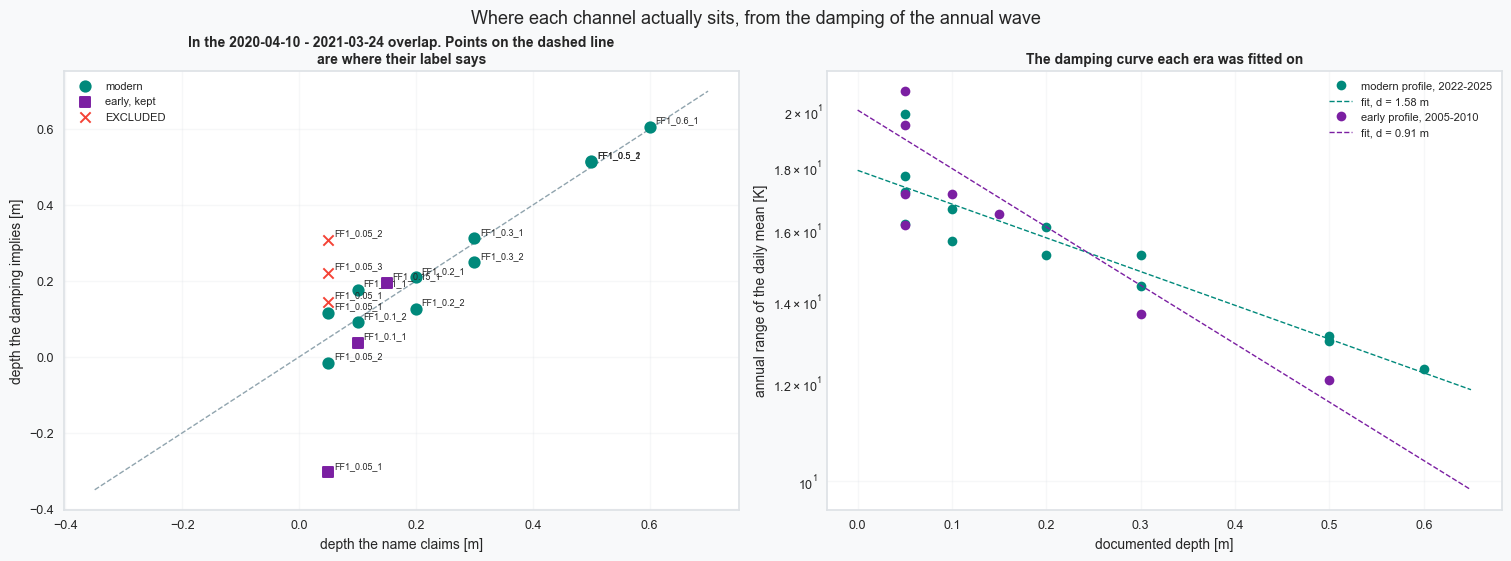

In [15]:
fig, axs = plt.subplots(ncols=2, figsize=(15, 5.5), dpi=100, layout="constrained")
fig.suptitle("Where each channel actually sits, from the damping of the annual wave", fontsize=13)

_style = {"modern": ("#00897B", "o"), "early, kept": ("#7B1FA2", "s"), "EXCLUDED": ("#F44336", "x")}
for _role, (_c, _m) in _style.items():
    _sub = OVERLAP_DEPTHS[OVERLAP_DEPTHS["role"] == _role]
    # linewidths is explicit for the same reason mew is in the last figure: 'x' is an edge-only
    # marker, and the theme in force here zeroes the default marker edge width.
    axs[0].scatter(_sub["z_named"], _sub["z_eff"], c=_c, marker=_m, s=55, linewidths=1.4,
                   label=_role, zorder=3)
    for _lbl, _r in _sub.iterrows():
        axs[0].annotate(_lbl.split(" ")[0].replace("TS_", "").replace("PRF_", ""),
                        (_r["z_named"], _r["z_eff"]), fontsize=6.5,
                        xytext=(4, 3), textcoords="offset points")
_lim = [-0.35, 0.7]
axs[0].plot(_lim, _lim, color="#90A4AE", ls="--", lw=1, zorder=1)
axs[0].set_xlabel("depth the name claims [m]")
axs[0].set_ylabel("depth the damping implies [m]")
axs[0].set_title(f"In the {OVERLAP_WINDOW[0]} - {OVERLAP_WINDOW[1]} overlap. Points on the dashed "
                 f"line\nare where their label says", fontsize=10)
axs[0].legend(fontsize=8)

for _tab, _fit, _lbl, _c in [(TDIAG_MODERN, FIT_ANNUAL, "modern profile, 2022-2025", "#00897B"),
                             (TDIAG_EARLY, FIT_EARLY, "early profile, 2005-2010", "#7B1FA2")]:
    _z = pd.Series({c: v for c, v in {**NOMINAL_MODERN, **NOMINAL_EARLY}.items() if c in _tab.index})
    axs[1].semilogy(_z, _tab.loc[_z.index, "annual_range"], "o", color=_c, label=_lbl)
    _zz = np.linspace(0, 0.65, 50)
    axs[1].semilogy(_zz, _fit["amp_max"] * np.exp(-(_fit["slope"] * _zz + _fit["intercept"])),
                    color=_c, lw=1, ls="--", label=f"fit, d = {_fit['d']:.2f} m")
axs[1].set_xlabel("documented depth [m]")
axs[1].set_ylabel("annual range of the daily mean [K]")
axs[1].set_title("The damping curve each era was fitted on", fontsize=10)
axs[1].legend(fontsize=8)
plt.show()

***

## 📔 Fieldbook: the device history

Read here rather than quoted from memory, so a newer export re-derives this history instead of
leaving a stale copy in the prose.

**The filter cannot be the device tag**, for the reasons `09` found the hard way and for one more
that is specific to soil temperature: this profile's thermometers are mostly **not filed as
thermometers**. Eleven of the thirteen modern channels come from sensors whose job is something
else — five `TEROS 12` soil-moisture probes and six `MPS-2`/`TEROS 21` water-potential sensors —
and they appear in the export under `iSWC_FF1_*` and `iWP_FF1_*`. Only the two Campbell 109s carry
an `iTS_FF1_*` operation tag. A filter on `TS` alone finds two channels out of thirteen.

So the filter takes the operation tag **or** the location **or** the device columns **or** the free
text, and asserts that it matched something: an export whose format changed silently returns zero
rows, which reads exactly like "nothing ever happened at this site".

In [16]:
_fb = pd.read_csv(FIELDBOOK, encoding="utf-8-sig")   # the export carries a BOM
_fb.columns = [c.strip() for c in _fb.columns]
_fb["date"] = pd.to_datetime(_fb["Date"], format="%d.%m.%Y", errors="coerce")
assert _fb["date"].notna().all(), "(!) unparsed dates in the fieldbook - check the date format"
_fb["text"] = _fb["Text"].map(plaintext)

_devcols = [c for c in ("Device Model", "Device Name") if c in _fb.columns]
_fb["device"] = _fb[_devcols].fillna("").astype(str).agg(" ".join, axis=1) if _devcols else ""

# The legacy row: the 2006-2011 site record, pasted in as one entry. Held out of `fb` and parsed
# in its own section below - its sub-entries carry their dates INSIDE the text.
BULK_MARKER = r"old fieldbook entries"
_is_bulk = _fb["Text"].astype(str).str.contains(BULK_MARKER, case=False, na=False)
assert int(_is_bulk.sum()) >= 1, (
    f"(!) no row matching '{BULK_MARKER}' - the legacy 2006-2011 record is not in this export, or "
    f"its wording changed. Do not conclude those years are undocumented until this is checked.")

# `109` is the Campbell thermistor's Device Model and is two characters long, so it is matched on
# the device columns only - in free text it would hit every serial number and voltage.
_TS_DEVICE = r"\b109\b|\b107\b|TEROS|MPS|EC-?20|decagon|CR1000|CR10X"
_TS_TEXT = (r"soil temp|Bodentemp|Temperatursensor|thermistor|TEROS|MPS|SDI|"
            r"loggerprog|logger program|power supply|Waldboden|Bodenfeuchte|Boden|soil")
_mask = (_fb["Operation Tag"].astype(str).str.contains(
             r"iTS_FF1|iSWC_FF1|iWP_FF1|iDL_FF1|iDAQ_FF1", case=False, na=False)
         | _fb["Location"].astype(str).str.contains(PROFILE, case=False, na=False)
         | _fb["device"].str.contains(_TS_DEVICE, case=False, na=False)
         | _fb["text"].str.contains(_TS_TEXT, case=False, na=False))
fb = (_fb[_mask & ~_is_bulk].drop_duplicates(subset=["date", "Event Tag", "Text"])
      .sort_values("date"))

assert len(fb) > 0, "(!) no fieldbook entries matched - has the export format changed?"
print(f"fieldbook: {len(_fb):,} rows, {_fb['date'].min().date()} -> {_fb['date'].max().date()}")
print(f"legacy bulk row(s) held back for separate parsing: {int(_is_bulk.sum())}")
print(f"entries relevant to this profile, its sensors, its logger or its power: {len(fb)}")

# What the profile's thermometers are actually filed as. Printed because it is the reason the
# filter looks the way it does.
_ff1 = _fb[_fb["Operation Tag"].astype(str).str.contains("FF1", na=False)]
print("\noperation tags at FF1 that carry a device model, and what that model is:")
display(_ff1.groupby(["Operation Tag", "Device Model"]).size().rename("rows").reset_index()
        .query("`Device Model` != 'na'").sort_values("Operation Tag"))


def fieldbook_near(start, stop=None, days: int = 2, maxchars: int = 400):
    """Print the fieldbook entries within `days` of a period."""
    start = pd.Timestamp(start)
    stop = pd.Timestamp(stop) if stop is not None else start
    hits = fb[fb["date"].between(start - pd.Timedelta(days=days), stop + pd.Timedelta(days=days))]
    if hits.empty:
        print(f"   (no fieldbook entry within +/-{days} days)")
        return
    for _, r in hits.iterrows():
        print(f"   {r['date']:%Y-%m-%d} [{str(r['Event Tag'])[:12]:<12s}] "
              f"{str(r['Device Model'])[:14]:<14s} {r['text'][:maxchars]}")

fieldbook: 2,102 rows, 2003-10-24 -> 2026-07-17
legacy bulk row(s) held back for separate parsing: 1
entries relevant to this profile, its sensors, its logger or its power: 246

operation tags at FF1 that carry a device model, and what that model is:


,Operation Tag,Device Model,rows
0,CH-LAE_iDAQ_FF1_0_1,ARK-1124C,16
1,CH-LAE_iDL_FF1_0_1,CR1000,19
2,CH-LAE_iDL_FF1_0_2,AM16/32B,2
3,CH-LAE_iDL_FF1_0_3,AM16/32B,2
4,CH-LAE_iDL_FF1_0_5,NL120,7
5,CH-LAE_iG_FF1_0.05_1,HFP01,7
6,CH-LAE_iG_FF1_0.05_2,HFP01,7
7,CH-LAE_iNETDEV_FF1_0_1,ENS202,7
8,CH-LAE_iSWC_FF1_0.05_1,TEROS 12,9
9,CH-LAE_iSWC_FF1_0.1_1,TEROS 12,9


### The entries this product stands on

Five dates, each one either an era boundary, an instrument identity or the explanation of a gap.
They are printed from the export, not transcribed.

In [17]:
KEY_DATES = [
    ("2020-03-19", "the modern profile installed: 5 TEROS 12, 3 TEROS 21, 3 MPS-2 - which is where "
                   "eleven of the thirteen modern TS channels come from"),
    ("2020-04-10", "logger script uploaded, first modern record, and the decision NOT to update the "
                   "CR1000 firmware for SDI-12 NaN support"),
    ("2021-03-25", "logger box rebuild: the MeteoScreeningTool stops, and the two Campbell 109 "
                   "thermistors are added at 0.05 m"),
    ("2024-04-23", "0.3 m unplugged - it had taken the whole FF1 SDI-12 port down with it, which is "
                   "why every depth has an April 2024 gap"),
    ("2025-03-04", "0.3 m replacement probe, 40 cm down the slope"),
]
for _d, _why in KEY_DATES:
    print(f"\n--- {_d}  ({_why})")
    fieldbook_near(_d, days=2)


--- 2020-03-19  (the modern profile installed: 5 TEROS 12, 3 TEROS 21, 3 MPS-2 - which is where eleven of the thirteen modern TS channels come from)
   2020-03-19 [ADD         ] TEROS 12       Added new device to location. Installed new soil profile with Meter Teros 12 sensors. Sensors measures SWC (VWC), EC and TS
   2020-03-19 [TRASHED     ] EC-20          Device trashed. Removed all of the old Soil moisture sensors at the forest floor (FF1 ). The sensor at the depth 50cm is broken for such a long time that we didn't even add it the GIN database. With the sensors the following variables will not have sensors connected to it. But we will have values in the loggerprogram until we update the loggerprogram. SoilMM5_05_AVG SoilMM5_10_AVG SoilMM5_20_AVG (
   2020-03-19 [ADD         ] TEROS 12       Added new device For SWC - 5 Teros12 sensors For WP - 3 Teros21 sensors and 3 MPS old sensors
   2020-03-19 [ADD         ] MPS-2          Added new device to site.

--- 2020-04-10  (logger scri

Two things in those entries change how the data below should be read, and neither is in any
variable name.

**The two Campbell 109s are not in the profile pit.** Their `ADD` entries say they went in *"right
besides the Soil Heat Flux plate G_FF1_0.05_1"* and `_2` — a different microsite from the TEROS
profile, at the same nominal depth. That is the physical explanation for what the depth analysis
measured: `TS_FF1_0.05_4` behaves shallower and livelier than every other 5 cm channel, and it is
the one channel that responded to a windstorm stripping litter off the ground. It also makes them
the right fill for the April 2024 SDI-12 bus failure, because they are analogue and were not on the
bus that failed.

**The March 2021 rebuild kept the names on purpose.** Its own entry says *"We kept the naming of
all variables where we didn't replace the sensors by new sensor (type)"* — which is the policy that
produced this entire product's naming problem, stated by the people who applied it. The same day, a
Campbell **107** soil sensor was trashed as *"partly already broken"*. That 107 is the only named
soil thermometer anywhere in the record that predates the 2020 profile, and it is a lead on what
the early channels physically were — not an answer, because nothing ties it to a particular field
name.

In [18]:
# What the site record says the profile's thermometers are. The device columns, not the free text:
# `107` and `109` are three-character model numbers and would match a serial number in any body.
_dev = _fb[_fb["device"].str.contains(r"\b10[79]\b|TEROS|MPS", case=False, na=False)
           & _fb["Operation Tag"].astype(str).str.contains("FF1|na", case=False, na=False)]
display(_dev.groupby(["Device Model", "Event Tag"])["date"]
        .agg(["min", "max", "count"]).rename(columns={"count": "rows"}))

for _model, _why in [("109", "the two thermistors added at the 2021 rebuild"),
                     ("107", "the older Campbell soil sensor, trashed at the same rebuild")]:
    _hits = _fb[_fb["Device Model"].astype(str).str.strip() == _model]
    print(f"\n--- Device Model '{_model}'  ({_why}): {len(_hits)} rows")
    for _, _r in _hits.sort_values("date").head(6).iterrows():
        print(f"   {_r['date']:%Y-%m-%d} [{str(_r['Event Tag'])[:10]:<10}] "
              f"{str(_r['Operation Tag'])[:24]:<24} {_r['text'][:230]}")

# The 109s' install date is a claim this notebook makes elsewhere (LATE_START in the download
# notebook, the flag legend here), so it is checked against the data rather than believed.
_first_109 = min(diive_[_c].first_valid_index() for _c in C109)
print(f"\nfirst record of either Campbell 109 in the data: {_first_109}")
assert abs((_first_109 - pd.Timestamp(REBUILD)).days) <= 2, (
    f"the 109s start on {_first_109.date()}, not at the {REBUILD} rebuild the fieldbook describes")

min        max  rows
Device Model Event Tag                            
109          ADD       2021-03-24 2021-03-24     2
             CHECK     2026-07-17 2026-07-17     1
             HW_MOD    2021-03-26 2021-03-26     2
MPS-2        ADD       2020-03-19 2020-03-19     6
             HW_MOD    2020-03-24 2026-07-09    15
             INCIDENT  2026-06-30 2026-06-30     3
             SW_MOD    2020-04-10 2020-04-10     3
TEROS 12     ADD       2020-03-19 2025-03-04    11
             HW_MOD    2020-03-24 2026-07-09    27
             INCIDENT  2025-06-27 2026-06-30     7
             SW_MOD    2020-04-10 2020-04-10     5
             TRASHED   2025-03-04 2025-03-04     1
TEROS 21     ADD       2020-03-19 2020-03-19     6
             HW_MOD    2020-03-24 2026-07-09    15
             INCIDENT  2026-06-30 2026-06-30     3
             SW_MOD    2020-04-10 2020-04-10     3


--- Device Model '109'  (the two thermistors added at the 2021 rebuild): 5 rows
   2021-03-24 [ADD       ] CH-LAE_iTS_FF1_0.05_3    Added new device to site. The sensor is installed right besides the Soil Heat Flux plate G_FF1_0.05_1
   2021-03-24 [ADD       ] CH-LAE_iTS_FF1_0.05_4    Added new device to site. The sensor is installed right besides the Soil Heat Flux plate G_FF1_0.05_2
   2021-03-26 [HW_MOD    ] CH-LAE_iTS_FF1_0.05_3    Connected most of the sensors at the FF1 site and started the data acquisition after uploading the loggerscript to the datalogger iDL_FF1_0_1
   2021-03-26 [HW_MOD    ] CH-LAE_iTS_FF1_0.05_4    Connected most of the sensors at the FF1 site and started the data acquisition after uploading the loggerscript to the datalogger iDL_FF1_0_1
   2026-07-17 [CHECK     ] CH-LAE_iTS_FF1_0.05_4    too close to the surface? Very strong daily cycle

--- Device Model '107'  (the older Campbell soil sensor, trashed at the same rebuild): 6 rows
   2016-01-01 [ADD       ]

Two of those rows are worth reading twice.

**`2026-07-17 [CHECK] CH-LAE_iTS_FF1_0.05_4`: *"too close to the surface? Very strong daily
cycle"*.** Somebody at the site reached the same conclusion the damping analysis reaches, from
looking at the data, months after the last record used here — and independently of it. The removal
below rests on the measurement, not on this entry; but a site record that agrees with a physical
diagnostic is worth more than either alone.

**`2021-03-25 [TRASHED]`: *"Will replace the 107 soil sensors by new one (109)"*, three devices.**
This is the only place in the entire archive where a soil thermometer predating the 2020 profile is
named. **Three** Campbell 107s were trashed on the day the early record stops — and there are
exactly three `TS_FF1_0.05_*` channels in the `mst` era, sitting at three unrelated effective
depths, which is what three separately placed sensors look like and not what a profile looks like.

That is a strong lead and it is **not** proof, for a reason worth stating: the other three early
channels (`TS_PRF_FF1_0.05_1`, `_0.1_1`, `_0.15_1`) stop on the same day, nothing in the export
ties a device number to a field name, and three 107s replaced by two 109s does not balance either.
It goes into the closing notes as an open question with evidence attached, not as an identification.

### The legacy record, hidden inside one row

Filtering the export on its `Date` column says the site was silent from 2004 to mid-2011. **It was
not.** When GIN was introduced, the paper fieldbook of the preceding years was pasted in as a
**single row** — one date, one `FBA` event tag, `na` for operation tag and location, and a body of
about 57,000 characters of HTML holding roughly a hundred dated sub-entries from 2006 to 2011.

This matters more here than in `09`: this product's early era runs to 2021 and its four largest
whole-station gaps all fall in 2007-2011, inside exactly the window a date filter cannot see.

In [19]:
BULK_ROW = _fb[_is_bulk].iloc[0]
BULK_BODY = bulk_plaintext(BULK_ROW["Text"])
print(f"bulk row: dated {BULK_ROW['date'].date()}, event tag '{BULK_ROW['Event Tag']}', "
      f"{len(str(BULK_ROW['Text'])):,} characters of HTML -> {len(BULK_BODY):,} of text")
LEGACY = split_legacy_entries(BULK_BODY)
print(f"legacy sub-entries: {len(LEGACY)}, "
      f"{LEGACY['date'].min().date()} -> {LEGACY['date'].max().date()}")
print(LEGACY["date"].dt.year.value_counts().sort_index().to_string())

assert len(LEGACY) >= 50, "too few legacy sub-entries parsed"
assert LEGACY["date"].min().year <= 2006 and LEGACY["date"].max().year >= 2011, \
    "the parsed legacy record does not span 2006-2011 - check the parse"


def legacy_near(start, stop=None, days: int = 30, maxchars: int = 380, limit: int = 8):
    """Print the legacy sub-entries within `days` of a period."""
    start = pd.Timestamp(start)
    stop = pd.Timestamp(stop) if stop is not None else start
    hits = LEGACY[LEGACY["date"].between(start - pd.Timedelta(days=days),
                                         stop + pd.Timedelta(days=days))]
    if hits.empty:
        print(f"   (no legacy sub-entry within +/-{days} days)")
        return hits
    for _, r in hits.head(limit).iterrows():
        print(f"   {r['date']:%Y-%m-%d}  {r['text'][:maxchars]}")
    return hits


# Documentation coverage of this product's own years, so the closing notes can be specific about
# what is unadjudicable rather than vague about it.
_reg = _fb.loc[~_is_bulk, "date"]
_doc = pd.DataFrame({
    "regular_rows": _reg.dt.year.value_counts().reindex(range(2004, 2026), fill_value=0).sort_index(),
    "legacy_sub_entries": LEGACY["date"].dt.year.value_counts()
        .reindex(range(2004, 2026), fill_value=0).sort_index()})
_doc["total"] = _doc.sum(axis=1)
UNDOCUMENTED_YEARS = [int(y) for y in _doc.index[_doc["total"] == 0]]
print(f"\nyears of this product with NO site record of any kind: {UNDOCUMENTED_YEARS}")
assert [y for y in UNDOCUMENTED_YEARS if y < 2006], (
    "this notebook claims 2004-2005 carry no site record; this export says otherwise")
assert not [y for y in UNDOCUMENTED_YEARS if 2006 <= y <= 2011], (
    "years 2006-2011 show as undocumented, which means the legacy row was not parsed")

bulk row: dated 2011-06-03, event tag 'FBA', 57,534 characters of HTML -> 29,522 of text
  parsed with the line-anchored pattern: 100 dated sub-entries
legacy sub-entries: 100, 2006-08-31 -> 2011-06-03
date
2006     3
2007    15
2008    22
2009     8
2010    37
2011    15

years of this product with NO site record of any kind: [2004, 2005]


***

## 🔗 One column per depth

### Why a priority fill and not a mean

The obvious way to put four channels at 0.05 m into one column is to average them. It is the wrong
thing to do here, and the reason is visible in the table above: the four channels at 0.05 m have
summer daily amplitudes of 1.48, 0.91, 0.90 and 0.50 K. They are not four measurements of one
quantity with independent noise; they are four sensors of three makes at three effective depths.

A mean of them would still be a defensible estimate of "the temperature at 5 cm" — **if the set
never changed.** It does: two of the four did not exist before March 2021, one is removed from
October 2025 (below), and all of them have gaps. Every change of membership would step the mean's
level *and* its amplitude, on a date that has nothing to do with the soil. The step would be small,
smooth, and completely invisible to anyone reading the column.

So each depth is **one channel, extended**: the primary supplies the value wherever it has one, and
a gap is filled from the next channel in the priority list after that channel has been shifted onto
the primary's level. The consequences are stated rather than hidden:

- the column's character is the primary's character throughout;
- the fill is a level-matched substitute, not an average, and the flag says which sensor it was;
- the offsets are **measured on the pair's own overlap**, per year as well as overall, so a drifting
  pair is refused rather than spliced with one constant.

In [20]:
# Offsets first, and printed per year: an offset that changes from year to year is a drifting pair,
# and a drifting pair must not be joined with a single constant.
_rows = []
OFFSETS = {}
for _d in DEPTHS:
    _chans = MODERN[_d]
    if len(_chans) < 2:
        continue
    _primary = _chans[0]
    OFFSETS[_d] = {}
    for _c in _chans[1:]:
        _off, _sd, _per_year, _n = pairwise_offset(diive_[_primary], diive_[_c], f"{_d} m: {_c}")
        OFFSETS[_d][_c] = _off
        _rows.append({"depth_m": float(_d), "primary": _primary, "channel": _c,
                      "offset_K": round(_off, 3), "sd_K": round(_sd, 3), "n_overlap": _n,
                      "drift_K": round(float(_per_year.max() - _per_year.min()), 3),
                      "per_year": _per_year.round(2).to_dict()})
OFFSETTAB = pd.DataFrame(_rows).set_index(["depth_m", "channel"])
display(OFFSETTAB)

# A pair whose offset moves by more than this between years is not one level apart; splicing it
# with a constant would put the drift into the product as a step wherever the fill is used.
MAX_OFFSET_DRIFT_K = 0.4
assert (OFFSETTAB["drift_K"] < MAX_OFFSET_DRIFT_K).all(), (
    f"a depth-mate pair's offset drifts by more than {MAX_OFFSET_DRIFT_K} K between years:\n"
    f"{OFFSETTAB[OFFSETTAB['drift_K'] >= MAX_OFFSET_DRIFT_K]}")
print(f"\nEvery pair is stable to better than {MAX_OFFSET_DRIFT_K} K across the years, and every "
      f"offset is a few\ntenths of a kelvin. These are two thermometers a few centimetres apart, "
      f"not two scales.")

primary  offset_K   sd_K  n_overlap  drift_K                                           per_year
depth_m channel                                                                                                             
0.05    TS_FF1_0.05_3  TS_FF1_0.05_2     0.239  0.175      81800    0.109  {2021: 0.17, 2022: 0.24, 2023: 0.27, 2024: 0.2...
        TS_FF1_0.05_4  TS_FF1_0.05_2     0.363  0.726      78056    0.061  {2021: 0.33, 2022: 0.35, 2023: 0.39, 2024: 0.3...
        TS_FF1_0.05_1  TS_FF1_0.05_2    -0.200  0.491      98494    0.200  {2020: -0.2, 2021: -0.3, 2022: -0.1, 2023: -0....
0.10    TS_FF1_0.1_1    TS_FF1_0.1_2    -0.100  0.304      98544    0.297  {2020: -0.02, 2021: -0.1, 2022: -0.1, 2023: -0...
0.20    TS_FF1_0.2_1    TS_FF1_0.2_2     0.000  0.259      98083    0.097  {2020: 0.01, 2021: -0.09, 2022: 0.0, 2023: 0.0...
0.30    TS_FF1_0.3_1    TS_FF1_0.3_2    -0.100  0.225      83554    0.100  {2020: -0.1, 2021: -0.2, 2022: -0.1, 2023: -0....
0.50    TS_FF1_0.5_1    TS_FF1_0.5_2     0.005  0.071      98566    0.100  {2020: 0.0, 2021: 0.0, 2022: 0.0, 2023: 0.0, 2...


Every pair is stable to better than 0.4 K across the years, and every offset is a few
tenths of a kelvin. These are two thermometers a few centimetres apart, not two scales.


### The hand-drawn removal, and where its window comes from

`REMOVE_DATES` is the only thing in this notebook that deletes data because a person decided to.
The screening notebook for `TS_FF1_0.05_4` saw the anomaly at 1MIN and deliberately left it in as
too ambiguous to judge there; at 30MIN against its own twin it is not ambiguous.

The window is **located blind first**. The scan below compares each channel's daily amplitude with
the median of its depth-mates, normalises by that channel's *own* long-run ratio — so a channel
that is simply livelier than its neighbours is not flagged for it — and reports contiguous runs
where the ratio departs by more than a factor of two. Only then is the fieldbook asked what
happened there.

In [21]:
def daily_frames(df, channels, min_per_day=40):
    """Daily mean and daily amplitude, with part-days dropped rather than counted as small."""
    _day = {c: df[c].resample("1D") for c in channels}
    _mean = pd.concat({c: d.mean().where(d.count() >= min_per_day) for c, d in _day.items()}, axis=1)
    _amp = pd.concat({c: (d.max() - d.min()).where(d.count() >= min_per_day)
                      for c, d in _day.items()}, axis=1)
    return _mean, _amp


def amplitude_scan(amp: pd.DataFrame, depth_channels: dict, window=None, factor=None,
                   min_block=None):
    """Runs where a channel's daily amplitude departs from its depth-mates AND from its own history.

    Two normalisations, both necessary. Against the depth-mates, because the seasonal cycle of
    amplitude is common to the whole profile and would otherwise dominate. Against the channel's
    own median ratio, because these are not replicates - the Campbell 109 at 0.05 m really is 1.7x
    its neighbours all the time, and a fixed threshold would flag it for existing.

    The ratio is computed only where EVERY channel of the depth is reporting: a peer median that
    silently loses a member steps, and the step looks exactly like a fault in whoever is left.
    """
    window = AMP_SCAN_WINDOW if window is None else window
    factor = AMP_SCAN_FACTOR if factor is None else factor
    min_block = AMP_SCAN_MIN_BLOCK if min_block is None else min_block
    rows, blocks = [], {}
    for _d, _chans in depth_channels.items():
        if len(_chans) < 2:
            rows.append({"depth_m": float(_d), "channel": _chans[0] if _chans else "-",
                         "n_peers": 0, "median_ratio": np.nan, "n_days_off": np.nan,
                         "blocks": "no depth-mate - this scan cannot see this channel"})
            continue
        _complete = amp[_chans].notna().all(axis=1)
        for _c in _chans:
            _peers = [p for p in _chans if p != _c]
            _ratio = (amp[_c] / amp[_peers].median(axis=1)).where(_complete)
            _ratio = _ratio.rolling(window, min_periods=window // 2).median()
            _rel = _ratio / _ratio.median()
            _off = _rel[(_rel > factor) | (_rel < 1 / factor)].dropna()
            _grp = (_off.index.to_series().diff().dt.days.fillna(1) > 7).cumsum()
            _bl = [(g.index[0], g.index[-1], len(g)) for _, g in _off.groupby(_grp) if len(g) >= min_block]
            blocks[_c] = _bl
            rows.append({"depth_m": float(_d), "channel": _c, "n_peers": len(_peers),
                         "median_ratio": round(float(_ratio.median()), 2), "n_days_off": len(_off),
                         "blocks": "; ".join(f"{a:%Y-%m-%d} -> {b:%Y-%m-%d} ({n} d)"
                                             for a, b, n in _bl) or "-"})
    return pd.DataFrame(rows).set_index(["depth_m", "channel"]), blocks


DAILY_MEAN, DAILY_AMP = daily_frames(diive_, MODERN_ALL)
AMPSCAN, AMPBLOCKS = amplitude_scan(DAILY_AMP, MODERN)
display(AMPSCAN)

FOUND = {c: b for c, b in AMPBLOCKS.items() if b}
print("Runs found blind, before any date was looked up:")
for _c, _bl in FOUND.items():
    for _a, _b, _n in _bl:
        print(f"   {_c:<16} {_a:%Y-%m-%d} -> {_b:%Y-%m-%d}  ({_n} days)")
print("\nThe fieldbook, asked afterwards about the longest of them:")
_worst = max((b for bl in FOUND.values() for b in bl), key=lambda t: t[2])
fieldbook_near(_worst[0] - pd.Timedelta(days=14), _worst[0], days=0)

print("\nNot every run above becomes a removal, and the short ones are why the scan reports rather\n"
      "than deletes. Two of them sit against a whole-station outage, where the surviving days at\n"
      "the edge of the window are few and their amplitudes unrepresentative; the amplitude ratio\n"
      "of a two-week winter period at 0.3 m, where every channel's daily range is one or two\n"
      "quantiser steps, is not evidence of anything either. Only the run whose ratio departs by a\n"
      "factor of several, for months, against an undisturbed twin at the same depth is removed -\n"
      "and it is audited below.")

n_peers  median_ratio  n_days_off                                             blocks
depth_m channel                                                                                            
0.05    TS_FF1_0.05_2        3          0.92         0.0                                                  -
        TS_FF1_0.05_3        3          1.09         0.0                                                  -
        TS_FF1_0.05_4        3          1.69        58.0                    2025-11-02 -> 2025-12-31 (57 d)
        TS_FF1_0.05_1        3          0.51         0.0                                                  -
0.10    TS_FF1_0.1_2         1          1.40         0.0                                                  -
        TS_FF1_0.1_1         1          0.71         0.0                                                  -
0.15    -                    0           NaN         NaN  no depth-mate - this scan cannot see this channel
0.20    TS_FF1_0.2_2         1          1.40         0.0                                                  -
        TS_FF1_0.2_1         1          0.71         0.0                                                  -
0.30    TS_FF1_0.3_2         1          1.10        32.0                    2021-01-20 -> 2021-02-01 (11 d)
        TS_FF1_0.3_1         1          0.85        16.0                                                  -
0.50    TS_FF1_0.5_2         1          1.00        20.0                                                  -
        TS_FF1_0.5_1         1          1.00        23.0                    2022-08-23 -> 2022-09-09 (17 d)
0.60    TS_FF1_0.6_1         0           NaN         NaN  no depth-mate - this scan cannot see this channel

Runs found blind, before any date was looked up:
   TS_FF1_0.05_4    2025-11-02 -> 2025-12-31  (57 days)
   TS_FF1_0.3_2     2021-01-20 -> 2021-02-01  (11 days)
   TS_FF1_0.5_1     2022-08-23 -> 2022-09-09  (17 days)

The fieldbook, asked afterwards about the longest of them:
   2025-10-24 [SAMPLE      ] na             We measured soil respiration (SR) with LI-8100_81A-0159 , SWC with HH2 Moisture Meter_HH2120010 and TS. Then collected, weighed and applied the litter treatment to the collars. We collected 884 g (moist/wet) litter from the traps and applied: 50% = 17.6 g, 100% = 35.2 g, 150% = 52.8 g and for the 200% treatment = 70.4 g moist/wet litter. This was after very windy days with quite a lot of rain. The
   2025-10-29 [SAMPLE      ] na             We measured soil respiration (SR) with LI-8100_81A-0159 , SWC with HH2 Moisture Meter_HH2120010 and TS. Then collected, weighed and applied the litter treatment to the collars. We collected 60.95 g (moist/semi dry) litter from the tra

In [22]:
# Apply the windows. A removal is a value becoming NaN in the CHANNEL, before any combination -
# never a value being overwritten in a depth column, which would leave the flag saying a sensor
# measured something it did not.
diive_clean = diive_.copy()
_rows = []
for _c, _wins in REMOVE_DATES.items():
    for _a, _b, _why in _wins:
        _m = (diive_clean.index >= pd.Timestamp(_a)) & (diive_clean.index <= pd.Timestamp(_b))
        _rows.append({"channel": _c, "from": _a, "to": _b,
                      "n_removed": int(diive_clean.loc[_m, _c].notna().sum()), "reason": _why})
        diive_clean.loc[_m, _c] = np.nan
REMOVED = pd.DataFrame(_rows)
display(REMOVED)
assert (REMOVED["n_removed"] > 0).all(), (
    "a REMOVE_DATES window removed nothing - it is either stale or misdated, and a window that "
    "does nothing must not sit in the settings looking like a decision")

,channel,from,to,n_removed,reason
0,TS_FF1_0.05_4,2025-10-23,2025-12-31 23:59,3359,daily amplitude ~4x its own history and its 10...


#### The audit of the removal window

`CLAUDE.md` reserves the full two-direction audit for a notebook whose `REMOVE_DATES` is not empty,
because a hand-drawn window is the only thing here that deletes data on a person's say-so. So the
window's own justification is **recomputed on every run**, not quoted from the paragraph above it:

1. *Is what was removed genuinely bad?* The blind scan must fire **inside** the window and **not
   before it** — if the anomaly turns out to predate the window, the window is mislabelled and the
   removal is deleting good data along with bad.
2. *Is everything real still there?* The channel's agreement with its depth-mates outside the
   window must be unremarkable, and the depth column the removal feeds must lose nothing: this
   channel is a *fill* at 0.05 m, so the audit ends by counting how many records of the exported
   column the removal actually changed.

In [23]:
for _c, _wins in REMOVE_DATES.items():
    for _a, _b, _why in _wins:
        _a, _b = pd.Timestamp(_a), pd.Timestamp(_b)
        _bl = AMPBLOCKS.get(_c, [])
        _inside = [t for t in _bl if t[0] >= _a - pd.Timedelta(days=AMP_SCAN_WINDOW) and t[1] <= _b]
        _before = [t for t in _bl if t[1] < _a - pd.Timedelta(days=AMP_SCAN_WINDOW)]
        print(f"{_c}  window {_a:%Y-%m-%d} -> {_b:%Y-%m-%d}")
        print(f"   blind detections inside it : {[(f'{x:%Y-%m-%d}', f'{y:%Y-%m-%d}', n) for x, y, n in _inside]}")
        print(f"   blind detections before it : {[(f'{x:%Y-%m-%d}', f'{y:%Y-%m-%d}', n) for x, y, n in _before]}")
        assert _inside, (f"{_c}: the blind scan finds nothing inside the removal window. The "
                         f"evidence for this removal no longer stands - re-derive it or drop it.")
        assert not _before, (f"{_c}: the blind scan also fires BEFORE the window, so the window "
                             f"starts too late and good data is being kept as bad, or bad data as good.")

        # Direction two: how the channel behaves in the years the window does NOT cover.
        _peers = [p for p in MODERN["0.05"] if p != _c]
        _ratio = (DAILY_AMP[_c] / DAILY_AMP[_peers].median(axis=1)).where(
            DAILY_AMP[MODERN["0.05"]].notna().all(axis=1))
        _out = _ratio[(_ratio.index < _a) | (_ratio.index > _b)].dropna()
        _in = _ratio[(_ratio.index >= _a) & (_ratio.index <= _b)].dropna()
        print(f"   amplitude ratio to its depth-mates: {_out.median():.2f} outside the window "
              f"({len(_out):,} days), {_in.median():.2f} inside it ({len(_in):,} days)")
        assert _in.median() > 2 * _out.median(), (
            "the window no longer stands out against the rest of the record - the justification "
            "written beside it is not what the data say")

        # Audit in proportion to what was removed. This channel is a FILL at its depth, so most of
        # what the window deletes was never going to reach the product: what matters is only the
        # records where every higher-priority channel of the same depth is also missing.
        _depth = next(d for d in DEPTHS if _c in MODERN[d])
        _above = MODERN[_depth][:MODERN[_depth].index(_c)]
        _win = (diive_.index >= _a) & (diive_.index <= _b)
        _would_have = int((diive_.loc[_win, _c].notna()
                           & diive_.loc[_win, _above].isna().all(axis=1)).sum())
        print(f"   records the window deletes: {int(diive_.loc[_win, _c].notna().sum()):,}")
        print(f"   of those, records that would have reached the {_depth} m column (every "
              f"higher-priority\n   channel of the depth also missing): {_would_have:,}")
        if _would_have == 0:
            print("   -> the removal changes no exported value at all. It is kept because a "
                  "channel\n      known to be faulty must not be standing by as a fill.")

TS_FF1_0.05_4  window 2025-10-23 -> 2025-12-31
   blind detections inside it : [('2025-11-02', '2025-12-31', 57)]
   blind detections before it : []
   amplitude ratio to its depth-mates: 1.67 outside the window (1,550 days), 6.26 inside it (70 days)
   records the window deletes: 3,359
   of those, records that would have reached the 0.05 m column (every higher-priority
   channel of the depth also missing): 0
   -> the removal changes no exported value at all. It is kept because a channel
      known to be faulty must not be standing by as a fill.


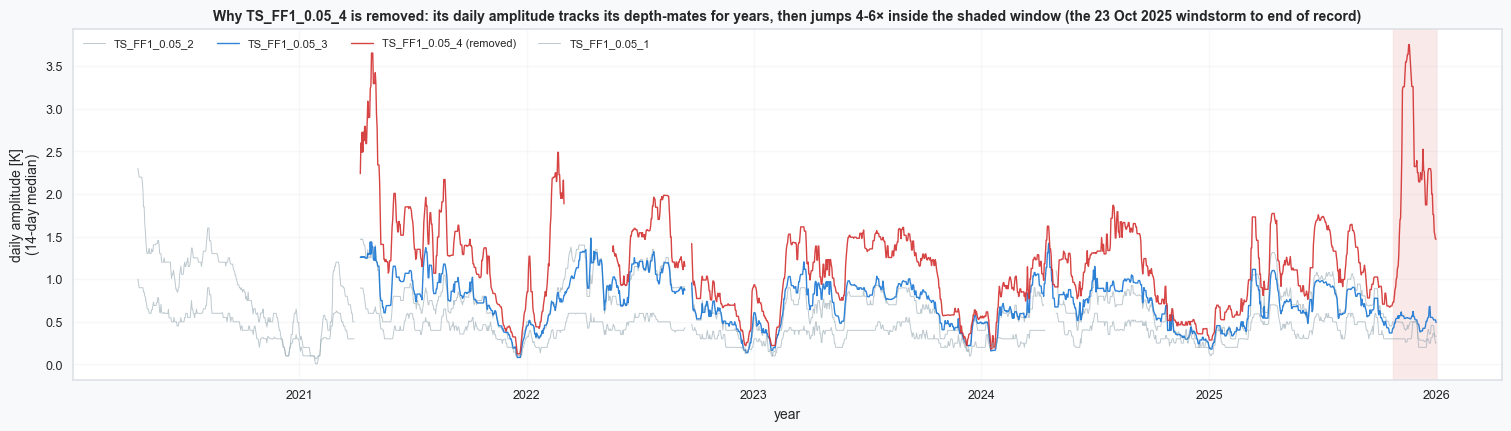

In [24]:
# The removal, made visible: the daily amplitude of each 0.05 m channel over the record. The one
# being removed (TS_FF1_0.05_4) tracks its depth-mates for years and then, in the shaded window,
# jumps to several times their amplitude - the windstorm signature the screening left in at 1MIN.
fig, ax = plt.subplots(figsize=(15, 4.2), dpi=100, layout="constrained")
_c05 = {"TS_FF1_0.05_1": "#90A4AE", "TS_FF1_0.05_2": "#90A4AE", "TS_FF1_0.05_3": "#1976D2",
        "TS_FF1_0.05_4": "#D32F2F"}
for _c in MODERN["0.05"]:
    _amp = (diive_[_c].resample("1D").max() - diive_[_c].resample("1D").min()).where(
        diive_[_c].resample("1D").count() >= 40).rolling(14, min_periods=7).median()
    ax.plot(_amp.index, _amp.values, lw=1.0 if _c in ("TS_FF1_0.05_3", "TS_FF1_0.05_4") else 0.7,
            color=_c05[_c], alpha=0.9 if _c in ("TS_FF1_0.05_3", "TS_FF1_0.05_4") else 0.6,
            label=_c + (" (removed)" if _c in REMOVE_DATES else ""))
for _c, _wins in REMOVE_DATES.items():
    for _a, _b, _why in _wins:
        ax.axvspan(pd.Timestamp(_a), pd.Timestamp(_b), color="#D32F2F", alpha=.10)
ax.set_ylabel("daily amplitude [K]\n(14-day median)")
ax.set_xlabel("year")
ax.set_title("Why TS_FF1_0.05_4 is removed: its daily amplitude tracks its depth-mates for years, "
             "then jumps 4-6× inside the shaded window (the 23 Oct 2025 windstorm to end of record)",
             fontsize=10)
ax.legend(fontsize=8, ncol=4, loc="upper left")
plt.show()

### Build the columns

The index runs from the first early record to the end of 2025 and is continuous throughout; where
nothing measured, the value is `NaN` and the flag is `0`.

Order matters and is stated: **modern first, in priority order, then the early era into whatever is
still empty.** Doing it the other way round would let a 2004-2021 early channel win the 348-day
overlap and put the wrong sensor generation into a year of the modern record.

In [25]:
full_index = pd.date_range(f"{RECORD_START} 00:15:00", f"{RECORD_END} 23:45:00",
                           freq="30min", name="TIMESTAMP_MIDDLE")
ts = pd.DataFrame(index=full_index)
CONTRIB = []

for _d in DEPTHS:
    _combined = pd.Series(dtype=float)
    _flag = pd.Series(FLAG_NONE, index=full_index, dtype=int)

    for _rank, _c in enumerate(MODERN[_d]):
        _s = diive_clean[_c].dropna()
        if _s.empty:
            print(f"  (!) {_c} carries no data at all after the removals - skipped")
            continue
        _outside = _s.index.difference(full_index)
        assert _outside.empty, (f"{_c}: {len(_outside):,} records lie outside the exported index "
                                f"({_outside[0]} ... {_outside[-1]}) - widen RECORD_START/END")
        if _rank == 0:
            _off, _code = 0.0, FLAG_PRIMARY
        else:
            _off = OFFSETS[_d][_c]
            _code = FLAG_C109 if _c in C109 else FLAG_SECONDARY
        _new = _s.index.difference(_combined.index)
        _combined = pd.concat([_combined, (_s + _off).reindex(_new)]).sort_index()
        _flag.loc[_new] = _code
        CONTRIB.append({"depth_m": float(_d), "rank": _rank, "channel": _c,
                        "instrument": INSTRUMENT.get(_c, "-"),
                        "role": "primary" if _rank == 0 else "fill",
                        "flag": _code, "offset_K": round(_off, 3), "n_contributed": len(_new)})

    # The 0.3 m replacement probe gets its own code. Taken from the channel's own records after the
    # swap date, and only where that channel is what the column is carrying.
    if _d == SWAP_DEPTH and SWAP_CHANNEL in MODERN[_d]:
        _ix = diive_clean[SWAP_CHANNEL].dropna().index
        _ix = _ix[_ix >= pd.Timestamp(SENSOR_SWAP)].intersection(_flag.index[_flag == FLAG_PRIMARY])
        _flag.loc[_ix] = FLAG_REPLACEMENT
        CONTRIB.append({"depth_m": float(_d), "rank": 0, "channel": SWAP_CHANNEL,
                        "instrument": INSTRUMENT.get(SWAP_CHANNEL, "-"), "role": "replacement",
                        "flag": FLAG_REPLACEMENT, "offset_K": 0.0, "n_contributed": len(_ix)})

    for _c in EARLY[_d]:
        _s = mst[_c].dropna()
        _outside = _s.index.difference(full_index)
        assert _outside.empty, f"{_c}: records outside the exported index"
        _new = _s.index.difference(_combined.index)
        _combined = pd.concat([_combined, _s.reindex(_new)]).sort_index()
        _flag.loc[_new] = FLAG_EARLY
        CONTRIB.append({"depth_m": float(_d), "rank": 90, "channel": _c, "instrument": "early",
                        "role": "early", "flag": FLAG_EARLY, "offset_K": 0.0,
                        "n_contributed": len(_new)})

    ts[col(_d)] = _combined.reindex(full_index)
    ts[flagcol(_d)] = _flag

CONTRIBTAB = pd.DataFrame(CONTRIB).set_index(["depth_m", "rank"]).sort_index()
display(CONTRIBTAB)
print(f"merged frame: {len(ts):,} records, {ts.index[0]} -> {ts.index[-1]}")

channel    instrument         role  flag  offset_K  n_contributed
depth_m rank                                                                             
0.05    0         TS_FF1_0.05_2      TEROS 12      primary     2     0.000          98495
        1         TS_FF1_0.05_3  Campbell 109         fill     4     0.239            852
        2         TS_FF1_0.05_4  Campbell 109         fill     4     0.363              0
        3         TS_FF1_0.05_1         MPS-2         fill     3    -0.200              0
        90    TS_PRF_FF1_0.05_1         early        early     1     0.000         252848
0.10    0          TS_FF1_0.1_2      TEROS 12      primary     2     0.000          98544
        1          TS_FF1_0.1_1         MPS-2         fill     3    -0.100             67
        90     TS_PRF_FF1_0.1_1         early        early     1     0.000         252880
0.15    90    TS_PRF_FF1_0.15_1         early        early     1     0.000         269389
0.20    0          TS_FF1_0.2_2      TEROS 12      primary     2     0.000          98554
        1          TS_FF1_0.2_1      TEROS 21         fill     3     0.000             17
0.30    0          TS_FF1_0.3_2      TEROS 12      primary     2     0.000          83666
        0          TS_FF1_0.3_2      TEROS 12  replacement     5     0.000          14514
        1          TS_FF1_0.3_1      TEROS 21         fill     3    -0.100          15026
        90     TS_PRF_FF1_0.3_1         early        early     1     0.000          88151
0.50    0          TS_FF1_0.5_2      TEROS 12      primary     2     0.000          98588
        1          TS_FF1_0.5_1      TEROS 21         fill     3     0.005              2
        90     TS_PRF_FF1_0.5_1         early        early     1     0.000          88188
0.60    0          TS_FF1_0.6_1         MPS-2      primary     2     0.000          98617

merged frame: 373,728 records, 2004-09-07 00:15:00 -> 2025-12-31 23:45:00


### The combination is exact

Five ways it can go wrong, one assertion each: a value without provenance (or the reverse), a
record invented or lost, a flag code outside the vocabulary, a fill that is doing more work than a
fill should, and a value outside the physical band.

In [26]:
# 1) Value and flag agree everywhere, at every depth; every code is in the vocabulary.
for _d in DEPTHS:
    assert (ts[col(_d)].notna() == ts[flagcol(_d)].isin(MEASURED_FLAGS)).all(), \
        f"{col(_d)}: a record has a value without a flag, or a flag without a value"
    assert ts[flagcol(_d)].isin(FLAG_SOURCE_LEGEND).all(), f"{flagcol(_d)}: unknown code"

# 2) Nothing invented: every record in a depth column came from exactly one contributing channel.
for _d in DEPTHS:
    _expected = int(CONTRIBTAB.loc[float(_d)].query("role != 'replacement'")["n_contributed"].sum())
    _got = int(ts[col(_d)].notna().sum())
    assert _got == _expected, f"{col(_d)}: {_expected:,} records contributed but {_got:,} in the column"

# 3) Physical band. The screening already applied each channel's own limits, so this can only fire
#    on a wrong file or an offset applied in the wrong unit.
for _d in DEPTHS:
    _v = ts[col(_d)].dropna()
    _bad = _v[~_v.between(*TS_PLAUSIBLE_DEGC)]
    assert _bad.empty, (f"{col(_d)}: {len(_bad)} value(s) outside {TS_PLAUSIBLE_DEGC} degC, "
                        f"e.g. {_bad.iloc[0]:.2f} at {_bad.index[0]}")

# 4) The primary must dominate. A depth whose "primary" supplies less than this is not one sensor
#    extended, it is a blend, and the paragraph above it is then wrong.
MIN_PRIMARY_SHARE = 0.75
_share = {}
for _d in DEPTHS:
    if not MODERN[_d]:
        continue
    _modern = ts[flagcol(_d)].isin(MODERN_FLAGS)
    _prim = ts[flagcol(_d)].isin((FLAG_PRIMARY, FLAG_REPLACEMENT))
    _share[_d] = float(_prim.sum() / _modern.sum())
    assert _share[_d] >= MIN_PRIMARY_SHARE, (
        f"{col(_d)}: the primary supplies only {100 * _share[_d]:.0f} % of the modern era; this is "
        f"a blend of sensors, not one sensor extended")
print("share of the modern era supplied by the depth's own primary channel:")
print("   " + "   ".join(f"{_d} m: {100 * _v:.1f} %" for _d, _v in _share.items()))

# 5) Each era's block sits where the era does.
_rows = []
for _d in DEPTHS:
    for _code, _name in ERA_NAMES.items():
        _ix = ts.index[ts[flagcol(_d)] == _code]
        if len(_ix):
            _rows.append({"depth_m": float(_d), "flag": _code, "source": _name, "n": len(_ix),
                          "first": _ix[0], "last": _ix[-1]})
BLOCKS = pd.DataFrame(_rows).set_index(["depth_m", "flag"])
display(BLOCKS)
for (_d, _code), _r in BLOCKS.iterrows():
    if _code == FLAG_EARLY:
        continue
    assert _r["first"] >= MODERN_START, f"{_d} m: a modern flag before the modern record starts"

# What the order of operations cost, stated rather than left to be noticed: in the 348-day overlap
# the modern era wins, so the early channel's records there are read, used to measure the era
# offset, and then NOT exported. That is deliberate - the alternative is a column that switches
# back to the old sensor for a year after the new one is already running.
print()
for _d in DEPTHS:
    if not (MODERN[_d] and EARLY[_d]):
        continue
    _avail = sum(int(mst[_c].notna().sum()) for _c in EARLY[_d])
    _used = int((ts[flagcol(_d)] == FLAG_EARLY).sum())
    print(f"  {_d:>5} m  early records available {_avail:>7,}, exported {_used:>7,}, "
          f"superseded by the modern era in the overlap {_avail - _used:>6,}")

# The April 2024 SDI-12 bus failure is the one place a fill does real work, and it works because
# the two Campbell 109s are analogue and were not on the bus that failed.
_bus = ts.loc["2024-04-03":"2024-04-23"]
print(f"\nApril 2024, the SDI-12 bus failure: the 0.05 m column carries "
      f"{int((_bus[flagcol('0.05')] == FLAG_C109).sum()):,} records from a Campbell 109,\n"
      f"and every depth without an analogue channel has a gap there. That is the fill doing the "
      f"one job\nit exists for.")
print("\nCombination verified.")

share of the modern era supplied by the depth's own primary channel:
   0.05 m: 99.1 %   0.1 m: 99.9 %   0.2 m: 100.0 %   0.3 m: 84.8 %   0.5 m: 100.0 %   0.6 m: 100.0 %


source       n               first                last
depth_m flag                                                                    
0.05    1          early profile  252848 2004-09-07 13:45:00 2020-04-10 12:45:00
        2         modern primary   98495 2020-04-10 14:45:00 2025-12-31 23:45:00
        4           Campbell 109     852 2024-04-03 05:15:00 2024-04-23 08:15:00
0.10    1          early profile  252880 2004-09-07 13:45:00 2020-04-10 12:45:00
        2         modern primary   98544 2020-04-10 14:45:00 2025-12-31 23:45:00
        3       modern secondary      67 2024-04-03 10:45:00 2024-04-08 23:15:00
0.15    1          early profile  269389 2004-09-07 13:45:00 2021-03-24 09:45:00
0.20    2         modern primary   98554 2020-04-10 14:45:00 2025-12-31 23:45:00
        3       modern secondary      17 2024-04-03 11:15:00 2024-04-08 23:15:00
0.30    1          early profile   88151 2004-09-07 13:45:00 2010-03-06 12:45:00
        2         modern primary   69152 2020-04-10 14:45:00 2024-04-09 16:45:00
        3       modern secondary   15026 2024-04-23 08:45:00 2025-03-04 14:15:00
        5     modern replacement   14514 2025-03-04 14:45:00 2025-12-31 23:45:00
0.50    1          early profile   88188 2004-09-07 13:45:00 2010-03-06 12:45:00
        2         modern primary   98588 2020-04-10 14:45:00 2025-12-31 23:45:00
        3       modern secondary       2 2024-04-08 16:15:00 2024-04-08 17:15:00
0.60    2         modern primary   98617 2020-04-10 14:45:00 2025-12-31 23:45:00


   0.05 m  early records available 269,543, exported 252,848, superseded by the modern era in the overlap 16,695
    0.1 m  early records available 269,575, exported 252,880, superseded by the modern era in the overlap 16,695
    0.3 m  early records available  88,151, exported  88,151, superseded by the modern era in the overlap      0
    0.5 m  early records available  88,188, exported  88,188, superseded by the modern era in the overlap      0

April 2024, the SDI-12 bus failure: the 0.05 m column carries 852 records from a Campbell 109,
and every depth without an analogue channel has a gap there. That is the fill doing the one job
it exists for.

Combination verified.


***

## ⚖️ From channels to one series per depth

Everything so far has kept the individual channels apart, which is what the first half of the
export is: every real sensor in its own column, raw as it was screened. This section builds the
**second half** — one *overall* column per depth, `TS_FF1_<d>_HOMOGENIZED`, that a downstream user
can read as a single number. It is assembled in three steps, each of which is a decision made
earlier in this notebook:

1. **Merge** the modern replicates onto the depth's primary channel (the level-matched fill already
   built into `ts[col(_d)]` above).
2. **Homogenise** the early era onto the modern level *where an overlap let the offset be measured*
   — 0.05 and 0.1 m only.
3. **Gap-fill** every remaining hole from the other depths of the same profile, by a regression
   fitted separately for each sensor generation.

The result is one continuous best-estimate series per depth, and a `METHOD` flag on every record
saying which of the three produced it — so the plain measured series is always recoverable by
filtering the flag.

### Step 2 first: homogenise where the eras overlap

::: {.callout-note title="This is the one thing here that is stronger than its counterpart in 09"}
`09` had to homogenise soil moisture across a break that **nothing measured through**, using
climatology alone. Here the two sensor generations **reported side by side for 348 days**, at
0.05 m and 0.1 m, so the offset is a measurement of two thermometers in the same weather, not a
guess from two climates.
:::

**At 0.3 and 0.5 m the eras do not overlap** (the early probes died in March 2010, the modern ones
began in April 2020), so their early-to-modern offset **cannot** be measured and is **not**
invented. Those depths still get an overall column — merged and gap-filled — but their early era
sits at its own level, and the `METHOD` flag says so (code `2`), so a trend drawn across 2020 there
still carries the sensor change. This is the honest half-measure the data allow, and it is marked
rather than hidden.

In [27]:
ERA_OFFSET, ERA_MONTHLY = {}, {}
_rows = []
for _d in DEPTHS:
    if not (MODERN[_d] and EARLY[_d]):
        _rows.append({"depth_m": float(_d), "verdict": "single era - nothing to homogenise",
                      "n_overlap": 0, "offset_K": np.nan})
        continue
    _early = pd.concat([mst[_c].dropna() for _c in EARLY[_d]]).sort_index()
    _modern = ts[col(_d)].where(ts[flagcol(_d)].isin(MODERN_FLAGS)).dropna()
    _ix = _early.index.intersection(_modern.index)
    if len(_ix) < 2000:
        _rows.append({"depth_m": float(_d),
                      "verdict": "eras do not overlap - NO homogenised column, on purpose",
                      "n_overlap": len(_ix), "offset_K": np.nan})
        continue
    _diff = (_modern.reindex(_ix) - _early.reindex(_ix)).dropna()
    ERA_OFFSET[_d] = float(_diff.median())
    ERA_MONTHLY[_d] = _diff.groupby(_diff.index.month).median()
    _rows.append({"depth_m": float(_d), "verdict": "measured on the overlap",
                  "n_overlap": len(_ix), "offset_K": round(float(_diff.median()), 3),
                  "sd_K": round(float(_diff.std()), 3),
                  "first": _ix[0], "last": _ix[-1],
                  "monthly_min_K": round(float(ERA_MONTHLY[_d].min()), 2),
                  "monthly_max_K": round(float(ERA_MONTHLY[_d].max()), 2)})
ERATAB = pd.DataFrame(_rows).set_index("depth_m")
display(ERATAB)

if ERA_MONTHLY:
    print("The offset per calendar month, to show whether one number was enough [K]:")
    display(pd.DataFrame({f"{_d} m": _v for _d, _v in ERA_MONTHLY.items()}).rename_axis("month").round(2))

assert ERA_OFFSET, "no depth could be homogenised at all - the 348-day overlap is not in the data"
assert max(abs(v) for v in ERA_OFFSET.values()) < 3.0, (
    "an era offset above 3 K - that is not two thermometers in one soil, check the assignment")
print(f"\nHomogenised columns for: {sorted(ERA_OFFSET)} m. "
      f"Offsets {', '.join(f'{v:+.2f} K' for v in ERA_OFFSET.values())}.")
print("The monthly spread is of the same order as the offset itself, which is a warning worth\n"
      "reading: one constant is enough for annual and daily means, and is NOT a seasonal\n"
      "correction. The early sensor's amplitude is not corrected by any of this - see the caveat\n"
      "at the top of the notebook.")

,verdict,n_overlap,offset_K,sd_K,first,last,monthly_min_K,monthly_max_K
depth_m,,,,,,,,
0.05,measured on the overlap,16695,-0.553,1.188,2020-04-10 14:45:00,2021-03-24 09:45:00,-1.05,-0.01
0.10,measured on the overlap,16695,-0.402,0.577,2020-04-10 14:45:00,2021-03-24 09:45:00,-0.77,0.40
0.15,single era - nothing to homogenise,0,NaN,NaN,NaT,NaT,NaN,NaN
0.20,single era - nothing to homogenise,0,NaN,NaN,NaT,NaT,NaN,NaN
0.30,"eras do not overlap - NO homogenised column, o...",0,NaN,NaN,NaT,NaT,NaN,NaN
0.50,"eras do not overlap - NO homogenised column, o...",0,NaN,NaN,NaT,NaT,NaN,NaN
0.60,single era - nothing to homogenise,0,NaN,NaN,NaT,NaT,NaN,NaN


The offset per calendar month, to show whether one number was enough [K]:


,0.05 m,0.1 m
month,,
1,-0.52,-0.50
2,-1.05,-0.77
3,-0.04,-0.16
4,-0.04,0.40
5,-0.70,-0.24
6,-0.98,-0.56
7,-0.85,-0.42
8,-0.68,-0.22
9,-0.63,-0.17



Homogenised columns for: ['0.05', '0.1'] m. Offsets -0.55 K, -0.40 K.
The monthly spread is of the same order as the offset itself, which is a warning worth
reading: one constant is enough for annual and daily means, and is NOT a seasonal
correction. The early sensor's amplitude is not corrected by any of this - see the caveat
at the top of the notebook.


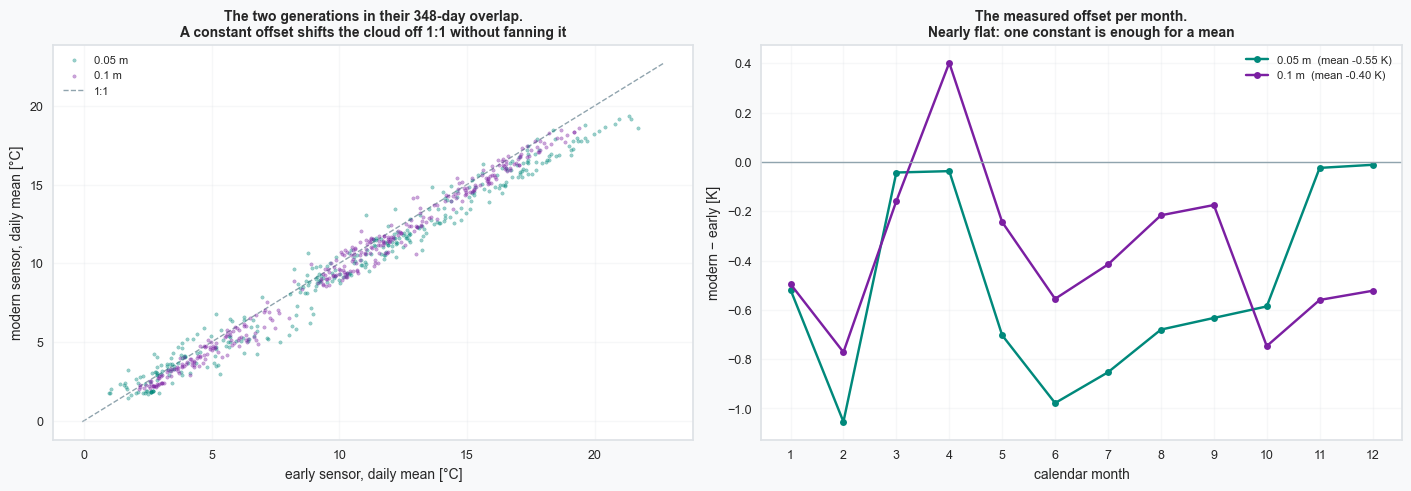

In [28]:
# The offset is a measurement, so show the measurement: the two thermometers side by side in their
# 348-day overlap. Left, the daily-mean scatter against the 1:1 line - a constant vertical offset,
# not a fan (which would mean a gain difference). Right, the offset per calendar month, so a reader
# can see it is nearly flat and that one number is therefore enough for a mean.
fig, axs = plt.subplots(ncols=2, figsize=(14, 4.8), dpi=100, layout="constrained")
_ecolors = {"0.05": "#00897B", "0.1": "#7B1FA2"}
for _d in ERA_OFFSET:
    _early = pd.concat([mst[_c].dropna() for _c in EARLY[_d]]).sort_index()
    _modern = ts[col(_d)].where(ts[flagcol(_d)].isin(MODERN_FLAGS)).dropna()
    _ix = _early.index.intersection(_modern.index)
    _e = _early.reindex(_ix).resample("1D").mean()
    _m = _modern.reindex(_ix).resample("1D").mean()
    axs[0].scatter(_e, _m, s=6, alpha=.4, color=_ecolors.get(_d, "#455A64"), label=f"{_d} m")
    axs[1].plot(range(1, 13), ERA_MONTHLY[_d].reindex(range(1, 13)), marker="o", ms=5,
                color=_ecolors.get(_d, "#455A64"), label=f"{_d} m  (mean {ERA_OFFSET[_d]:+.2f} K)")
_lim = [axs[0].get_xlim()[0], axs[0].get_xlim()[1]]
axs[0].plot(_lim, _lim, color="#90A4AE", ls="--", lw=1, zorder=0, label="1:1")
axs[0].set_xlabel("early sensor, daily mean [°C]")
axs[0].set_ylabel("modern sensor, daily mean [°C]")
axs[0].set_title("The two generations in their 348-day overlap.\nA constant offset shifts the "
                 "cloud off 1:1 without fanning it", fontsize=10)
axs[0].legend(fontsize=8, loc="upper left")
axs[1].axhline(0, color="#90A4AE", lw=1)
axs[1].set_xticks(range(1, 13))
axs[1].set_xlabel("calendar month")
axs[1].set_ylabel("modern − early [K]")
axs[1].set_title("The measured offset per month.\nNearly flat: one constant is enough for a mean",
                 fontsize=10)
axs[1].legend(fontsize=8)
plt.show()

In [29]:
# The base of every overall column: the measured merged series, with the early era shifted onto the
# modern level at the two depths where that shift was measured. A gap is NaN and NaN + offset is
# NaN, so the offset cannot turn a gap into a value (notebook 03's lesson, structurally). The
# METHOD flag starts as measured-modern / measured-early / gap, and the gap-fill below overwrites
# only the gaps.
overall = pd.DataFrame(index=full_index)
method = pd.DataFrame(index=full_index)
for _d in DEPTHS:
    _base = ts[col(_d)].copy()
    _off = ERA_OFFSET.get(_d, 0.0)
    if _off:
        _base = _base + np.where(ts[flagcol(_d)] == FLAG_EARLY, _off, 0.0)
    overall[_d] = _base
    _m = pd.Series(METHOD_NONE, index=full_index, dtype=int)
    _m.loc[ts[flagcol(_d)].isin(MODERN_FLAGS)] = METHOD_MODERN
    _m.loc[ts[flagcol(_d)] == FLAG_EARLY] = METHOD_EARLY
    method[_d] = _m
    _n_e = int((ts[flagcol(_d)] == FLAG_EARLY).sum())
    print(f"  {homogcol(_d):<28} base: {int(_base.notna().sum()):>7,} measured "
          f"({_n_e:,} early{f', shifted {_off:+.3f} K' if _off else ', at own level'})")

# The homogenisation must move ONLY the early era, and land it exactly on the modern level in the
# overlap - proven against the early channel itself, since inside the merged column the modern era
# won every shared half-hour and the two masks are disjoint.
for _d, _off in ERA_OFFSET.items():
    _e_raw = pd.concat([mst[_c].dropna() for _c in EARLY[_d]]).sort_index() + _off
    _m = ts[col(_d)].where(ts[flagcol(_d)].isin(MODERN_FLAGS)).dropna()
    _ix = _e_raw.index.intersection(_m.index)
    assert abs(float((_m.reindex(_ix) - _e_raw.reindex(_ix)).median())) < 1e-6, \
        f"{_d} m: the homogenised early era does not land on the modern level in the overlap"
    assert overall[_d].isna().equals(ts[col(_d)].isna()), f"{_d} m: homogenisation changed a gap"
print("\nEarly era shifted only where an overlap measured the offset; it lands on the modern "
      "level exactly.")

  TS_FF1_0.05_HOMOGENIZED_GAPFILLED base: 352,195 measured (252,848 early, shifted -0.553 K)
  TS_FF1_0.1_HOMOGENIZED_GAPFILLED base: 351,491 measured (252,880 early, shifted -0.402 K)
  TS_FF1_0.15_HOMOGENIZED_GAPFILLED base: 269,389 measured (269,389 early, at own level)
  TS_FF1_0.2_HOMOGENIZED_GAPFILLED base:  98,571 measured (0 early, at own level)
  TS_FF1_0.3_HOMOGENIZED_GAPFILLED base: 186,843 measured (88,151 early, at own level)
  TS_FF1_0.5_HOMOGENIZED_GAPFILLED base: 186,778 measured (88,188 early, at own level)
  TS_FF1_0.6_HOMOGENIZED_GAPFILLED base:  98,617 measured (0 early, at own level)

Early era shifted only where an overlap measured the offset; it lands on the modern level exactly.


### Step 3: fill the gaps from the other depths

The measured coverage is very uneven — 0.05/0.1 m are near-complete, 0.2/0.6 m only start in 2020,
0.3/0.5 m carry a ten-year hole. But the depths of one profile are **the same wave, damped and
delayed**, so a depth that is missing can be predicted from one that is present. The fill below
does that, and three choices make it defensible rather than a smooth invention:

- **Era-split.** A separate regression is fitted for the early and the modern sensor generation,
  and a gap is filled with its own era's coefficients only. A fill therefore can never carry one
  generation's level onto the other — the join at 2020 stays exactly where the measurements put it.
- **Nearest depth first, and the distance is flagged.** A gap is filled from the closest depth that
  is measured at that timestamp. Where that is a neighbour (`METHOD` code `3`) the estimate is good
  to ~0.2 K; where the profile is so sparse that only a distant depth remains (code `4`) the error
  grows to ~0.7 K and the value is marked as the weakest kind, safe to drop.
- **Measured predictors only.** A fill is never computed from an already-filled value, so error
  cannot compound down a chain of holes.
- **Within the measured span only — interpolation, never extrapolation, in *time* and in *value*.**
  In time, a depth is filled only *between* its own first and last real measurement — closing holes
  bracketed by measurements, never carrying a depth backward before its sensor was installed
  (0.2/0.6 m) or forward after it died (0.15 m). In value, a filled point is clipped to the min..max
  that depth actually measured in the same era: predicting a damped deep depth from a swingy shallow
  one can otherwise overshoot past the deepest sensor's real range, so a fill is never allowed to
  report a temperature the sensor at that depth never reached.

So the fill **closes the 0.3/0.5 m ten-year hole** — a gap bracketed by real measurements on both
sides — and closes the whole-station outages that fall inside a depth's span. What it leaves empty:
the whole-station outages that no depth can fill (every sensor dead at once), and everything outside
a depth's own measured span (0.15 m after 2021; 0.2 and 0.6 m before 2020). That boundary is the
line between reconstructing a measurement and inventing one.

In [30]:
%%time
# The measured frame the fill reads from: one series per depth, gaps as NaN, on the homogenised
# level. The fill predicts a target depth from the OTHER columns of this frame.
DEPTH_OF = {_d: float(_d) for _d in DEPTHS}
_measured = overall.copy()   # measured-only snapshot; the fill never reads its own output back
IS_MODERN = pd.Series(full_index >= ERA_BOUNDARY_MID, index=full_index)

FILL_STATS = []
for _d in DEPTHS:
    _filled, _fm = cross_depth_fill(_measured, _d, DEPTH_OF, IS_MODERN,
                                    min_n=FILL_MIN_N_PER_MONTH, adjacent_m=FILL_ADJACENT_M)
    # (!) Interpolate WITHIN this depth's own measured span; never extrapolate beyond it. A gap-fill
    #     fills holes between measurements - it does not invent a record before the sensor was
    #     installed or after it died. Without this, 0.15 m (last measured 2021-03) would be carried
    #     to 2025 from neighbours, fabricating 3.5 years from a dead channel - exactly the fabrication
    #     refused for 0.2/0.6 m before 2020. The span is closed on both ends here, symmetrically.
    # (a) TIME span: interpolate within the measured span, never extrapolate beyond either end.
    _first = _measured[_d].first_valid_index()
    _last = _measured[_d].last_valid_index()
    _in_span = (full_index >= _first) & (full_index <= _last)
    _extrapolated = int((_filled.notna() & overall[_d].isna() & ~_in_span).sum())
    _filled = _filled.where(_in_span)

    # (b) VALUE span: a fill is an interpolation in value too, so clip it to the min..max this depth
    #     actually measured - within the SAME era, to match the era-split fit. Predicting a damped
    #     deep depth from a swingy shallow one can otherwise overshoot past the deepest sensor's real
    #     range (0.3 m ran ~0.7 K above its warmest measurement before this). The clip is to a
    #     temperature the sensor genuinely reached, never a fabricated extreme.
    _clipped = 0
    for _era in (True, False):
        _mera = _measured[_d].where(IS_MODERN == _era).dropna()
        if _mera.empty:
            continue
        _sel = _filled.notna() & (IS_MODERN == _era)
        _before = _filled[_sel].copy()
        _filled.loc[_sel] = _filled[_sel].clip(float(_mera.min()), float(_mera.max()))
        _clipped += int((_filled[_sel] != _before).sum())

    # Only the gaps are overwritten; measured records keep their value and their 1/2 method code.
    _gap = overall[_d].isna()
    overall.loc[_gap, _d] = _filled[_gap]
    method.loc[_gap & (_fm == METHOD_FILL_NEAR) & _in_span, _d] = METHOD_FILL_NEAR
    method.loc[_gap & (_fm == METHOD_FILL_FAR) & _in_span, _d] = METHOD_FILL_FAR
    FILL_STATS.append({
        "depth_m": float(_d),
        "measured_span": f"{_first:%Y-%m-%d} -> {_last:%Y-%m-%d}",
        "measured_range_degC": f"{_measured[_d].min():.1f} .. {_measured[_d].max():.1f}",
        "measured_%": round(100 * float(_measured[_d].notna().mean()), 1),
        "filled_near": int(((method[_d] == METHOD_FILL_NEAR)).sum()),
        "filled_far": int(((method[_d] == METHOD_FILL_FAR)).sum()),
        "not_extrapolated": _extrapolated,
        "clipped_to_range": _clipped,
        "overall_%": round(100 * float(overall[_d].notna().mean()), 1)})
FILLTAB = pd.DataFrame(FILL_STATS).set_index("depth_m")
display(FILLTAB)

# The value-span rule, asserted: no filled value lies outside the range that depth measured in its
# own era. This is the range analog of the time-span rule above, and it is checked, not trusted.
for _d in DEPTHS:
    for _era in (True, False):
        _mera = overall[_d].where(method[_d].isin(METHOD_MEASURED) & (IS_MODERN == _era)).dropna()
        _fera = overall[_d].where(method[_d].isin(METHOD_MODELLED) & (IS_MODERN == _era)).dropna()
        if _mera.empty or _fera.empty:
            continue
        assert _fera.min() >= _mera.min() - 1e-9 and _fera.max() <= _mera.max() + 1e-9, \
            f"{_d} m: a filled value fell outside the era's measured range {_mera.min():.2f}.."\
            f"{_mera.max():.2f} ({_fera.min():.2f}..{_fera.max():.2f})"

# The rule, asserted: every filled value lies inside its depth's measured span. This is the line
# between interpolation (allowed) and extrapolation (refused), and it is checked, not trusted.
for _d in DEPTHS:
    _m = overall[_d].where(method[_d].isin(METHOD_MEASURED))
    _lo, _hi = _m.first_valid_index(), _m.last_valid_index()
    _outside = overall[_d].notna() & ((overall[_d].index < _lo) | (overall[_d].index > _hi))
    assert not _outside.any(), \
        f"{_d} m: {int(_outside.sum())} filled value(s) lie outside the measured span {_lo}..{_hi}"
if FILLTAB["not_extrapolated"].sum():
    print(f"held back from extrapolation beyond a depth's measured span: "
          f"{FILLTAB['not_extrapolated'].sum():,} records "
          f"(mostly 0.15 m after its 2021 death) - filled would have been fabrication, not fill")

# A fill cannot invent a value where every depth was missing, and cannot leave a value physically
# impossible. Both are asserted rather than hoped.
_allmiss = _measured.isna().all(axis=1)
for _d in DEPTHS:
    assert not (overall[_d].notna() & _allmiss).any(), \
        f"{_d} m: a value was invented at a timestamp where no depth measured anything"
    assert overall[_d].dropna().between(*TS_PLAUSIBLE_DEGC).all(), \
        f"{_d} m: a modelled value left the plausible band {TS_PLAUSIBLE_DEGC}"
    assert (overall[_d].notna() == method[_d].isin((METHOD_MODERN, METHOD_EARLY,
            METHOD_FILL_NEAR, METHOD_FILL_FAR))).all(), f"{_d} m: value and METHOD flag disagree"
print(f"\nOverall coverage now {FILLTAB['overall_%'].min():.1f}-{FILLTAB['overall_%'].max():.1f} % "
      f"per depth. Unfillable whole-station outages remaining: {int(_allmiss.sum()):,} "
      f"({100 * _allmiss.mean():.1f} %).")

,measured_span,measured_range_degC,measured_%,filled_near,filled_far,not_extrapolated,clipped_to_range,overall_%
depth_m,,,,,,,,
0.05,2004-09-07 -> 2025-12-31,-3.6 .. 28.8,94.2,98,37,0,0,94.3
0.10,2004-09-07 -> 2025-12-31,-0.7 .. 22.8,94.0,802,37,0,0,94.3
0.15,2004-09-07 -> 2021-03-24,0.1 .. 19.9,72.1,252,37,82652,0,72.2
0.20,2020-04-10 -> 2025-12-31,1.8 .. 19.2,26.4,121,655,0,0,26.6
0.30,2004-09-07 -> 2025-12-31,1.2 .. 18.9,50.0,164795,692,0,428,94.3
0.50,2004-09-07 -> 2025-12-31,1.7 .. 17.2,50.0,28,165524,0,333,94.3
0.60,2020-04-10 -> 2025-12-31,3.6 .. 16.9,26.4,1,729,0,0,26.6


held back from extrapolation beyond a depth's measured span: 82,652 records (mostly 0.15 m after its 2021 death) - filled would have been fabrication, not fill

Overall coverage now 26.6-94.3 % per depth. Unfillable whole-station outages remaining: 21,398 (5.7 %).
CPU times: total: 7.77 s
Wall time: 7.86 s


#### Does the fill actually predict what it claims? Two held-out tests

The fill is only worth what it can reproduce on data it did not see. Two tests, the second one the
one that matters: hide whole years and predict them from all other depths (the easy case, where a
neighbour is usually present), then hide **every deep depth at once** and predict them from the
shallow ones alone — which is the exact shape of the 2010-2020 hole this fill exists to close.

In [31]:
def _held_out(target, hide_mask, allowed=None, return_pairs=False):
    _tf = _measured.copy()
    if allowed is None:
        _tf.loc[hide_mask, target] = np.nan
    else:
        _tf.loc[hide_mask, [c for c in DEPTHS if c not in allowed]] = np.nan
    _pred, _ = cross_depth_fill(_tf, target, DEPTH_OF, IS_MODERN,
                                min_n=FILL_MIN_N_PER_MONTH, adjacent_m=FILL_ADJACENT_M)
    _truth = _measured[target].where(hide_mask).dropna()
    _p = _pred.reindex(_truth.index).dropna()
    _truth = _truth.reindex(_p.index)
    _e = (_p - _truth).to_numpy()
    if len(_e) == 0:
        return (None, None, None) if return_pairs else None
    _stats = {"n": len(_e), "bias_K": round(float(_e.mean()), 2),
              "rmse_K": round(float(np.sqrt((_e ** 2).mean())), 2),
              "p95_K": round(float(np.percentile(np.abs(_e), 95)), 2)}
    return (_stats, _truth, _p) if return_pairs else _stats


print("TEST 1 - hide a whole year, predict from all other depths:")
_rows = []
for _d in DEPTHS:
    for _yr in (2016, 2023):
        _hide = (_measured.index.year == _yr) & _measured[_d].notna()
        if _hide.sum() < 3000:
            continue
        _r = _held_out(_d, _hide)
        if _r:
            _rows.append({"depth_m": float(_d), "year": _yr, **_r})
display(pd.DataFrame(_rows).set_index(["depth_m", "year"]))

print("TEST 2 - the real hole: hide ALL deep depths from 2022 on, predict from 0.05/0.1/0.15:")
_SHALLOW = ["0.05", "0.1", "0.15"]
_rows, HELDOUT_PAIRS = [], {}
for _d in ["0.2", "0.3", "0.5", "0.6"]:
    _hide = (_measured.index >= "2022-01-01") & _measured[_d].notna()
    _r, _truth, _p = _held_out(_d, _hide, allowed=_SHALLOW, return_pairs=True)
    if _r:
        _rows.append({"depth_m": float(_d), **_r})
        HELDOUT_PAIRS[_d] = (_truth, _p)
_t2 = pd.DataFrame(_rows).set_index("depth_m")
display(_t2)
assert _t2["rmse_K"].max() < 1.0, (
    "the shallow-only fill of a deep depth is worse than 1 K RMSE - the model no longer supports "
    "closing the 2010-2020 hole, so revisit before exporting a filled 0.3/0.5 m column")
print("\nEven predicted from the shallow depths alone the deep fills stay under 1 K RMSE, which is\n"
      "what licenses filling the ten-year hole. The fills are still MODELLED, and flagged as such.")

TEST 1 - hide a whole year, predict from all other depths:


n  bias_K  rmse_K  p95_K
depth_m year                              
0.05    2016  17526   -0.13    0.73   1.44
        2023  17476   -0.03    0.26   0.52
0.10    2016  17526    0.65    0.73   1.18
        2023  17476    0.02    0.24   0.47
0.15    2016  17526   -0.59    0.66   1.06
0.20    2023  17476    0.02    0.21   0.43
0.30    2023  17476   -0.03    0.20   0.40
0.50    2023  17476    0.02    0.10   0.18
0.60    2023  17476   -0.03    0.09   0.18

TEST 2 - the real hole: hide ALL deep depths from 2022 on, predict from 0.05/0.1/0.15:


,n,bias_K,rmse_K,p95_K
depth_m,,,,
0.2,68708,0.06,0.17,0.37
0.3,68829,-0.06,0.34,0.67
0.5,68727,-0.20,0.55,1.12
0.6,68754,-0.37,0.66,1.28



Even predicted from the shallow depths alone the deep fills stay under 1 K RMSE, which is
what licenses filling the ten-year hole. The fills are still MODELLED, and flagged as such.


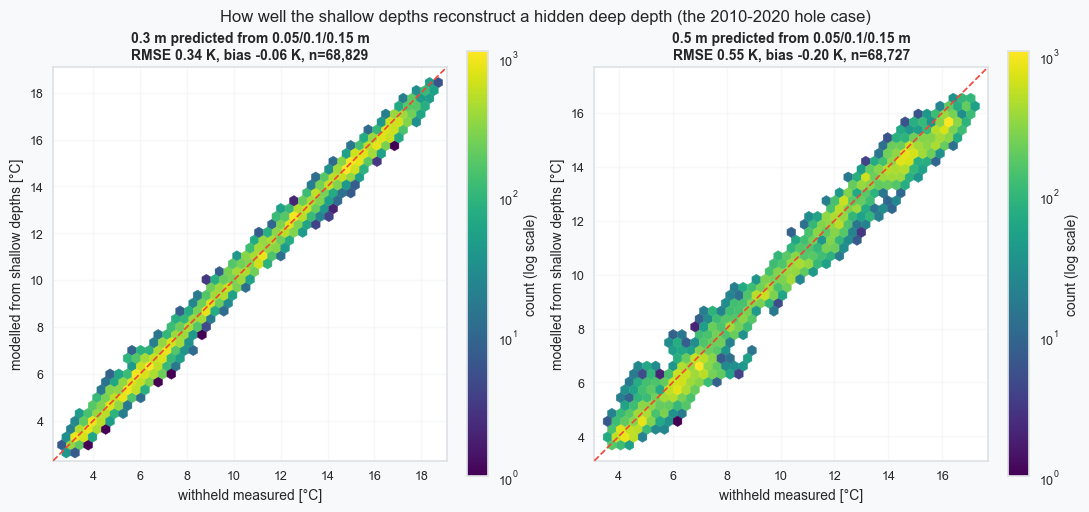

In [32]:
# TEST 2 made visible: predicted-from-shallow against the withheld truth, for the two depths whose
# ten-year hole this fill actually closes. A hexbin rather than a scatter because there are ~69,000
# points per depth; the tighter the cloud hugs 1:1, the more the modelled fill can be trusted.
_deep = [d for d in ("0.3", "0.5") if d in HELDOUT_PAIRS]
fig, axs = plt.subplots(ncols=len(_deep), figsize=(5.4 * len(_deep), 5), dpi=100,
                        layout="constrained", squeeze=False)
for _ax, _d in zip(axs[0], _deep):
    _truth, _p = HELDOUT_PAIRS[_d]
    _lo = float(min(_truth.min(), _p.min())) - 0.5
    _hi = float(max(_truth.max(), _p.max())) + 0.5
    _hb = _ax.hexbin(_truth.to_numpy(), _p.to_numpy(), gridsize=45, mincnt=1, cmap="viridis",
                     bins="log", extent=(_lo, _hi, _lo, _hi))
    _ax.plot([_lo, _hi], [_lo, _hi], color="#F44336", ls="--", lw=1.2, zorder=3)
    _rmse = float(np.sqrt(((_p - _truth) ** 2).mean()))
    _bias = float((_p - _truth).mean())
    _ax.set_title(f"{_d} m predicted from 0.05/0.1/0.15 m\n"
                  f"RMSE {_rmse:.2f} K, bias {_bias:+.2f} K, n={len(_truth):,}", fontsize=10)
    _ax.set_xlabel("withheld measured [°C]")
    _ax.set_ylabel("modelled from shallow depths [°C]")
    _ax.set_xlim(_lo, _hi)
    _ax.set_ylim(_lo, _hi)
    _ax.set_aspect("equal")
    fig.colorbar(_hb, ax=_ax, label="count (log scale)")
fig.suptitle("How well the shallow depths reconstruct a hidden deep depth (the 2010-2020 hole case)",
             fontsize=12)
plt.show()

***

## 🔍 Cross-checks across the profile

Three checks, in order of how much they can prove.

1. **Is the exported profile still a profile?** Amplitude must damp monotonically with depth, and
   the daily maximum must lag — separately in each era, because the two eras are different hardware.
   This is the one check that can fail because of something *this notebook* did: a wrong channel in
   a depth column shows up here as an inversion. The lag is asserted from end to end rather than
   step by step, because below 0.3 m the daily wave is one or two quantiser steps and its phase is
   correspondingly coarse — 0.6 m comes out marginally *ahead* of 0.5 m, which is quantisation, not
   heat flowing upwards.
2. **Did any channel quietly stop being coupled to the profile?** The loud failure — a sensor that
   stops reporting, or reports 211 °C — is caught by screening and by the band check. The quiet one
   is a sensor that keeps returning smooth, in-range, plausible values that no longer respond to
   what the soil is doing. That is invisible to any test on one series, and visible as a drop in
   agreement with everything else.
3. **Is the early profile internally consistent?** The same question as 2, asked of the early era,
   where it needs a different null — and where the answer is no. This is the largest finding in the
   notebook.
4. **Does the profile agree with the air above it?** `02`'s gap-filled air temperature is the only
   independent series that measures through both eras. It cannot validate a depth, but it would
   catch a whole-profile error — a wrong file, a wrong unit, a year-long timestamp shift.

In [33]:
_rows = []
for _d in DEPTHS:
    for _era, _mask in [("modern", ts[flagcol(_d)].isin(MODERN_FLAGS)),
                        ("early", ts[flagcol(_d)] == FLAG_EARLY)]:
        _s = ts[col(_d)].where(_mask).dropna()
        if len(_s) < 20000:
            continue
        _r = thermal_diagnostics(_s, col(_d))
        _r.update({"era": _era, "depth_m": float(_d)})
        _rows.append(_r)
ORDERING = pd.DataFrame(_rows).set_index(["era", "depth_m"]).sort_index()
display(ORDERING[["n", "amp_JJA", "amp_DJF", "hour_max_JJA", "annual_range", "mean"]].round(3))

for _era in ORDERING.index.get_level_values("era").unique():
    _sub = ORDERING.loc[_era].sort_index()
    assert _sub["annual_range"].is_monotonic_decreasing, (
        f"{_era} era: the annual range does not damp monotonically with depth\n{_sub['annual_range']}")
    assert _sub["amp_JJA"].is_monotonic_decreasing, (
        f"{_era} era: the summer daily amplitude does not damp monotonically with depth\n"
        f"{_sub['amp_JJA']}")
    print(f"{_era:<7} annual range damps monotonically: "
          f"{' > '.join(f'{v:.1f}' for v in _sub['annual_range'])} K "
          f"over {_sub.index.min()} - {_sub.index.max()} m")

# The phase has to lag with depth too, and it is the check the quantiser cannot fake: a channel
# placed at the wrong depth by a level error would still damp correctly, but not lag correctly.
# Compared against the shallowest depth of the same era, wrapped, because 0.5 m peaks after
# midnight and 23.9 h is 0.2 h later than 23.7, not 23.7 h earlier.
for _era in ORDERING.index.get_level_values("era").unique():
    _sub = ORDERING.loc[_era].sort_index()
    _lag = ((_sub["hour_max_JJA"] - _sub["hour_max_JJA"].iloc[0] + 12) % 24) - 12
    print(f"{_era:<7} lag of the daily maximum against the shallowest depth [h]: "
          f"{_lag.round(1).to_dict()}")
    assert _lag.iloc[-1] > _lag.iloc[0], f"{_era}: the daily maximum does not lag with depth"

n  amp_JJA  amp_DJF  hour_max_JJA  annual_range    mean
era    depth_m                                                              
early  0.05     252848    3.134    1.303        14.966        22.411   9.697
       0.10     252880    1.272    0.464        18.086        18.987   9.516
       0.15     269389    0.746    0.284        21.687        17.389   9.330
       0.30      88151    0.260    0.106        23.930        13.769   8.930
       0.50      88188    0.160    0.082         0.115        12.311   8.763
modern 0.05      99347    0.900    0.400        19.522        17.266  10.137
       0.10      98611    0.590    0.300        22.203        16.198  10.246
       0.20      98571    0.403    0.200        22.907        15.723  10.062
       0.30      98692    0.300    0.200        23.207        14.660  10.194
       0.50      98590    0.100    0.100        23.552        12.788  10.129
       0.60      98617    0.100    0.100        23.072        12.094  10.241

early   annual range damps monotonically: 22.4 > 19.0 > 17.4 > 13.8 > 12.3 K over 0.05 - 0.5 m
modern  annual range damps monotonically: 17.3 > 16.2 > 15.7 > 14.7 > 12.8 > 12.1 K over 0.05 - 0.6 m
early   lag of the daily maximum against the shallowest depth [h]: {0.05: 0.0, 0.1: 3.1, 0.15: 6.7, 0.3: 9.0, 0.5: 9.1}
modern  lag of the daily maximum against the shallowest depth [h]: {0.05: 0.0, 0.1: 2.7, 0.2: 3.4, 0.3: 3.7, 0.5: 4.0, 0.6: 3.6}


### Did any channel stop being coupled?

Each channel's **3-day change of the daily mean** is correlated with the median of the same
quantity over the whole modern profile, in a rolling 60-day window. A sensor that is measuring the
soil moves with the profile; a sensor that has come loose, been exposed, or is reporting its own
enclosure does not.

Two details decide whether this works at all:

- **3-day changes, not daily ones.** At 0.5 m and 0.6 m a one-day change is a few hundredths of a
  kelvin — below the `0.1 K` storage grid — so a daily-increment correlation there is a correlation
  of two quantisation patterns and reads about `0.5` all the time. Over three days the change
  clears the grid.
- **Each channel against its own baseline, not a fixed threshold.** Even at three days the deepest
  channels sit lower than the shallow ones for the same reason, so a fixed cut-off would flag
  `TS_FF1_0.6_1` permanently and prove nothing. A channel is flagged where its agreement falls
  `DECOUPLE_DROP` below *its own* median; and where even that baseline is under
  `DECOUPLE_MIN_BASELINE` the scan says it cannot resolve the channel rather than pretending to.

A third detail was found the hard way and is worth stating separately, because it is the classic
way this kind of scan lies: **a correlation computed across a gap is not a low correlation, it is
no correlation.** `TS_FF1_0.05_4` is missing for ten weeks in early 2022, and the windows straddling
that hole came back with `r ≈ 0.6` on a handful of surviving pairs — indistinguishable, in the
output, from a sensor that had come loose. Every window is therefore required to hold at least
`DECOUPLE_MIN_COVERAGE` of its days as valid pairs before its correlation is used at all.

In [34]:
def decoupling_scan(mean: pd.DataFrame, channels, step=None, window=None, drop=None):
    """Rolling agreement of each channel's N-day change with the profile's, against its own baseline."""
    step = INC_STEP_DAYS if step is None else step
    window = DECOUPLE_WINDOW if window is None else window
    drop = DECOUPLE_DROP if drop is None else drop
    _inc = mean.diff(step)
    _prof = _inc[channels].median(axis=1)
    rows, runs = [], {}
    for _c in channels:
        _r = _inc[_c].rolling(window, min_periods=window // 2).corr(_prof)
        # A window straddling a gap in this channel returns a correlation of a handful of pairs,
        # and it looks exactly like a decoupled sensor. Refuse it rather than report it.
        _n_valid = (_inc[_c].notna() & _prof.notna()).rolling(window).sum()
        _r = _r.where(_n_valid >= DECOUPLE_MIN_COVERAGE * window)
        _base = float(_r.median())
        _resolvable = _base >= DECOUPLE_MIN_BASELINE
        _low = _r[_r < _base - drop].dropna() if _resolvable else pd.Series(dtype=float)
        _grp = (_low.index.to_series().diff().dt.days.fillna(1) > 14).cumsum() if len(_low) else None
        _runs = ([(g.index[0], g.index[-1], len(g)) for _, g in _low.groupby(_grp)
                  if len(g) >= DECOUPLE_MIN_RUN] if len(_low) else [])
        runs[_c] = _runs
        rows.append({"channel": _c, "instrument": INSTRUMENT.get(_c, "-"),
                     "median_|change| [K]": round(float(_inc[_c].abs().median()), 3),
                     "baseline_r": round(_base, 3),
                     "windows_dropped_for_coverage": int(_r.isna().sum() - _inc[_c].isna().sum()),
                     "resolvable": _resolvable,
                     "n_windows_low": len(_low),
                     "runs": "; ".join(f"{a:%Y-%m-%d} -> {b:%Y-%m-%d} ({n} d)"
                                       for a, b, n in _runs) or "-"})
    return pd.DataFrame(rows).set_index("channel"), runs


DECOUPLE, DECOUPLE_RUNS = decoupling_scan(DAILY_MEAN, MODERN_ALL)
display(DECOUPLE)

_unres = list(DECOUPLE.index[~DECOUPLE["resolvable"]])
print(f"channels this scan cannot resolve: {_unres}")
print(f"   their median 3-day change is "
      f"{DECOUPLE.loc[_unres, 'median_|change| [K]'].min():.2f}-"
      f"{DECOUPLE.loc[_unres, 'median_|change| [K]'].max():.2f} K against a "
      f"{STORAGE_QUANTISER_K} K storage grid,\n   so their agreement is bounded by the quantiser "
      f"and not by the soil. Reported, not flagged.")

_hits = {c: v for c, v in DECOUPLE_RUNS.items() if v}
print(f"\nsustained losses of agreement ({DECOUPLE_MIN_RUN} days or more): {sorted(_hits)}")
UNCOVERED = []
for _c, _runs in _hits.items():
    for _a, _b, _n in _runs:
        _covered = any(pd.Timestamp(w[0]) - pd.Timedelta(days=DECOUPLE_WINDOW) <= _a
                       and _b <= pd.Timestamp(w[1]) + pd.Timedelta(days=DECOUPLE_WINDOW)
                       for w in REMOVE_DATES.get(_c, []))
        print(f"   {_c:<16} {_a:%Y-%m-%d} -> {_b:%Y-%m-%d} ({_n} d)  "
              f"{'covered by a removal window' if _covered else '(!) NOT COVERED'}")
        if not _covered:
            UNCOVERED.append((_c, _a, _b, _n))
        else:
            print("      the fieldbook, asked about what happened just before it:")
            fieldbook_near(_a - pd.Timedelta(days=21), _a - pd.Timedelta(days=7), days=0, maxchars=200)

# A NEW sustained decoupling is a finding, not a formality: it is exactly the quiet failure this
# scan exists to catch, and it must not be exported without somebody having looked at it.
assert not UNCOVERED, (
    f"the agreement scan finds sustained decoupling no removal window covers: {UNCOVERED}. "
    f"Look at it before exporting.")
print("\nEvery sustained loss of agreement is inside a removal window. Note what this scan does\n"
      "NOT prove: three channels are below the resolvable baseline, so a quiet failure at 0.5 or\n"
      "0.6 m would not be caught here by anything except the profile-ordering check above.")

,instrument,median_|change| [K],baseline_r,windows_dropped_for_coverage,resolvable,n_windows_low,runs
channel,,,,,,,
TS_FF1_0.05_2,TEROS 12,0.737,0.937,150,True,0,-
TS_FF1_0.05_3,Campbell 109,0.715,0.923,72,True,0,-
TS_FF1_0.05_4,Campbell 109,0.866,0.848,107,True,48,2025-11-17 -> 2025-12-31 (45 d)
TS_FF1_0.05_1,MPS-2,0.583,0.994,150,True,0,-
TS_FF1_0.1_2,TEROS 12,0.611,0.988,150,True,0,-
TS_FF1_0.1_1,MPS-2,0.518,0.999,150,True,0,-
TS_FF1_0.2_2,TEROS 12,0.564,0.996,150,True,0,-
TS_FF1_0.2_1,TEROS 21,0.483,0.993,185,True,0,-
TS_FF1_0.3_2,TEROS 12,0.474,0.983,158,True,0,-


channels this scan cannot resolve: ['TS_FF1_0.5_2', 'TS_FF1_0.5_1', 'TS_FF1_0.6_1']
   their median 3-day change is 0.28-0.32 K against a 0.1 K storage grid,
   so their agreement is bounded by the quantiser and not by the soil. Reported, not flagged.

sustained losses of agreement (14 days or more): ['TS_FF1_0.05_4']
   TS_FF1_0.05_4    2025-11-17 -> 2025-12-31 (45 d)  covered by a removal window
      the fieldbook, asked about what happened just before it:
   2025-10-29 [SAMPLE      ] na             We measured soil respiration (SR) with LI-8100_81A-0159 , SWC with HH2 Moisture Meter_HH2120010 and TS. Then collected, weighed and applied the litter treatment to the collars. We collected 60.95 g (m
   2025-11-06 [SAMPLE      ] na             We measured soil respiration (SR) with LI-8100_81A-0159 , SWC with HH2 Moisture Meter_HH2120010 and TS. Then collected, weighed and applied the litter treatment to the collars. We collected 49 g (semi

Every sustained loss of agreement is inside a

### Is the early profile internally consistent? No — and this is the largest finding here

The scan above covers the modern channels only. The early era needs its own, and it needs a
different null: those channels are stored on a continuous scale, so the quantiser is not the
problem, but the **gradient between two depths reverses sign twice a year** — the shallow sensor is
colder than the deeper ones in winter and warmer in summer. A fixed tolerance on a raw depth
difference fires every November on physics alone. So each channel is compared with the **mean of
the other two**, and that deviation is then measured against **its own day-of-year climatology**.

What survives is not reassuring. Between **January 2009 and May 2012** the three early channels
disagree with each other by **1.5 to 3.5 K** beyond their own seasonal norm, for months at a time,
in mirror-image pairs — `TS_PRF_FF1_0.05_1` running warm while `_0.15_1` runs cold. Outside it, across the other thirteen
years, they agree to a few tenths of a kelvin. The whole thing brackets the years when the forest-floor logger
was repeatedly losing power (the 2009, 2010 and 2011 whole-station gaps above, two of them named in
the legacy fieldbook as a dead logger and a fuse that slipped out) and ends around the
**2012-04-25** entry uploading a logger program *"with corrected multipliers and offset"* — the
entry `09` calls the only candidate gain change anywhere in the early era, which names no channels.

::: {.callout-warning title="This is reported, not repaired, and the reason matters"}
Three channels disagreeing does not say **which** is wrong. The leave-one-out deviation of a
three-member profile moves all three when any one moves, and there is no fourth soil sensor, no
external reference and no overlap to break the tie — air temperature is 47 m up a tower and cannot
resolve a 2 K offset at 5 cm depth.

So nothing is removed and nothing is corrected. The affected records stay in the product, flagged
as measured — because they were measured — and carry a **second flag**,
`FLAG_TS_FF1_<d>_SUSPECT`, saying the profile disagreed with itself while they were recorded. The
period is re-derived from the data on every run; only the coarse window it must fall inside is a
setting.
:::

In [35]:
EARLY_LONG = [c for d in DEPTHS for c in EARLY[d]
              if int(mst[c].notna().sum()) > 200_000]     # the three that span the whole early era
print(f"early channels compared against each other: {EARLY_LONG}")

_daily_early = pd.concat({_c: mst[_c].resample("1D").mean()
                          .where(mst[_c].resample("1D").count() >= 40) for _c in EARLY_LONG}, axis=1)
EARLY_DEV = leave_one_out_deviation(_daily_early, EARLY_LONG)

EARLY_RUNS, _rows = {}, []
for _c in EARLY_LONG:
    _anom = deseasonalise(EARLY_DEV[_c])
    EARLY_RUNS[_c] = sustained_runs(_anom, tol=EARLY_SCAN_TOL_K, window=EARLY_SCAN_WINDOW,
                                    min_run=EARLY_SCAN_MIN_RUN)
    for _a, _b, _n, _amp in EARLY_RUNS[_c]:
        _rows.append({"channel": _c, "from": _a.date(), "to": _b.date(), "days": _n,
                      "mean_excursion_K": round(_amp, 2),
                      "records": int(mst.loc[_a:_b + pd.Timedelta(days=1), _c].notna().sum())})
    print(f"  {_c:<20} sd of the detrended deviation {_anom.std():.2f} K, "
          f"{len(EARLY_RUNS[_c])} run(s) beyond +/-{EARLY_SCAN_TOL_K} K for "
          f"{EARLY_SCAN_MIN_RUN}+ days")
EARLY_SUSPECT_TAB = pd.DataFrame(_rows)
display(EARLY_SUSPECT_TAB)

# Every run must sit inside the declared window. A NEW period of disagreement elsewhere in the
# seventeen years is a finding somebody has to look at, not something to export quietly.
_lo, _hi = pd.Timestamp(EARLY_SUSPECT_PERIOD[0]), pd.Timestamp(EARLY_SUSPECT_PERIOD[1])
_outside = [(c, a.date(), b.date()) for c, rs in EARLY_RUNS.items() for a, b, _, _ in rs
            if a < _lo or b > _hi]
assert not _outside, (
    f"the early consistency scan finds disagreement outside {EARLY_SUSPECT_PERIOD}: {_outside}. "
    f"That is a new finding - look at it before exporting.")
assert EARLY_SUSPECT_TAB.shape[0] > 0, (
    "the scan finds no disagreement at all in the early era; the section above describes one, so "
    "either the scan or the input changed - do not repeat the claim until this is checked")

_span = (EARLY_SUSPECT_TAB["from"].min(), EARLY_SUSPECT_TAB["to"].max())
print(f"\nall disagreement falls between {_span[0]} and {_span[1]}, inside the declared "
      f"{EARLY_SUSPECT_PERIOD}.")
print("Outside that period the three channels track each other to a few tenths of a kelvin, which\n"
      "is what makes the period itself the finding rather than the tolerance.")
print("\nThe fieldbook, asked about the end of it:")
fieldbook_near("2012-04-25", days=1)

early channels compared against each other: ['TS_PRF_FF1_0.05_1', 'TS_PRF_FF1_0.1_1', 'TS_PRF_FF1_0.15_1']
  TS_PRF_FF1_0.05_1    sd of the detrended deviation 1.29 K, 5 run(s) beyond +/-1.5 K for 30+ days
  TS_PRF_FF1_0.1_1     sd of the detrended deviation 0.65 K, 2 run(s) beyond +/-1.5 K for 30+ days
  TS_PRF_FF1_0.15_1    sd of the detrended deviation 1.00 K, 5 run(s) beyond +/-1.5 K for 30+ days


,channel,from,to,days,mean_excursion_K,records
0,TS_PRF_FF1_0.05_1,2009-01-26,2009-03-15,49,3.53,2096
1,TS_PRF_FF1_0.05_1,2009-07-05,2010-03-09,248,3.05,11683
2,TS_PRF_FF1_0.05_1,2010-11-10,2010-12-09,30,2.00,1440
3,TS_PRF_FF1_0.05_1,2010-12-24,2011-03-03,68,1.98,3110
4,TS_PRF_FF1_0.05_1,2011-08-20,2011-09-29,36,2.27,1968
5,TS_PRF_FF1_0.1_1,2009-07-05,2009-09-23,81,-1.89,3888
6,TS_PRF_FF1_0.1_1,2012-02-06,2012-05-05,90,1.82,4204
7,TS_PRF_FF1_0.15_1,2009-01-30,2009-03-15,45,-1.95,1904
8,TS_PRF_FF1_0.15_1,2009-07-05,2009-10-19,107,-2.19,5136
9,TS_PRF_FF1_0.15_1,2010-06-24,2010-08-01,39,-2.15,1872



all disagreement falls between 2009-01-26 and 2012-05-05, inside the declared ('2008-10-01', '2013-12-31').
Outside that period the three channels track each other to a few tenths of a kelvin, which
is what makes the period itself the finding rather than the tolerance.

The fieldbook, asked about the end of it:
   2012-04-25 [FBA         ] na             25.04.2012 (Thomas) Changed wiring (CLK and RES) of the AM16-32 to the CR1000 to correct measuring connected TC(F&I), StemCO2(F&I) and SAPFlow(A) rearranged wires in the hut to the Logger and Moxa Downloaded CR10 data from the profile unit, disconnected CR10 and reconnnected to the CR1000 –> checked function Data download to moxa not yet installed Network to FF was not able. Restarted Bridge at FF


In [36]:
# The SUSPECT flag on the overall column: one per depth whose early channel was ever in
# disagreement. Derived from the runs the scan just found, so it is recomputed rather than
# transcribed - and ANDed with "the overall value here came from the early era", so it can only
# ever mark records that actually rest on the disputed early sensors.
suspect = pd.DataFrame(index=full_index)
SUSPECT_DEPTHS = [d for d in DEPTHS if EARLY[d] and any(EARLY_RUNS.get(c) for c in EARLY[d])]
for _d in SUSPECT_DEPTHS:
    _win = pd.Series(0, index=full_index, dtype=int)
    for _c in EARLY[_d]:
        for _a, _b, _n, _amp in EARLY_RUNS.get(_c, []):
            _win.loc[_a:_b + pd.Timedelta(days=1)] = 1
    # An early-era value, whether measured (method 2) or modelled from another depth during the
    # early era (method 3/4), rests on the same disputed period - so both are flagged.
    _early_derived = (method[_d] == METHOD_EARLY) | ((~IS_MODERN) & method[_d].isin(METHOD_MODELLED))
    suspect[_d] = (_win & _early_derived.astype(int)).astype(int)

for _v in FLAG_SUSPECT_LEGEND.values():
    print(_v)
print()
for _d in DEPTHS:
    if _d not in SUSPECT_DEPTHS:
        print(f"  {_d:>5} m  no suspect column (no early channel, or none of its runs)")
        continue
    _n = int(suspect[_d].sum())
    _e = int((method[_d] == METHOD_EARLY).sum())
    print(f"  {_d:>5} m  {_n:>7,} records flagged suspect = {100 * _n / _e:.1f} % of its early era, "
          f"{100 * _n / int(overall[_d].notna().sum()):.1f} % of the whole column")
    assert not (suspect[_d].astype(bool) & IS_MODERN).any(), \
        f"{suspectcol(_d)}: a modern-era record was flagged suspect"
    assert suspect[_d].isin(FLAG_SUSPECT_LEGEND).all(), f"{suspectcol(_d)}: unknown code"

0 = the profile agreed with itself here, or there is nothing to compare against
1 = the early channels disagreed with each other beyond 1.5 K of their own seasonal norm, for a month or more

   0.05 m   20,297 records flagged suspect = 8.0 % of its early era, 5.8 % of the whole column
    0.1 m    8,121 records flagged suspect = 3.2 % of its early era, 2.3 % of the whole column
   0.15 m   13,219 records flagged suspect = 4.9 % of its early era, 4.9 % of the whole column
    0.2 m  no suspect column (no early channel, or none of its runs)
    0.3 m  no suspect column (no early channel, or none of its runs)
    0.5 m  no suspect column (no early channel, or none of its runs)
    0.6 m  no suspect column (no early channel, or none of its runs)


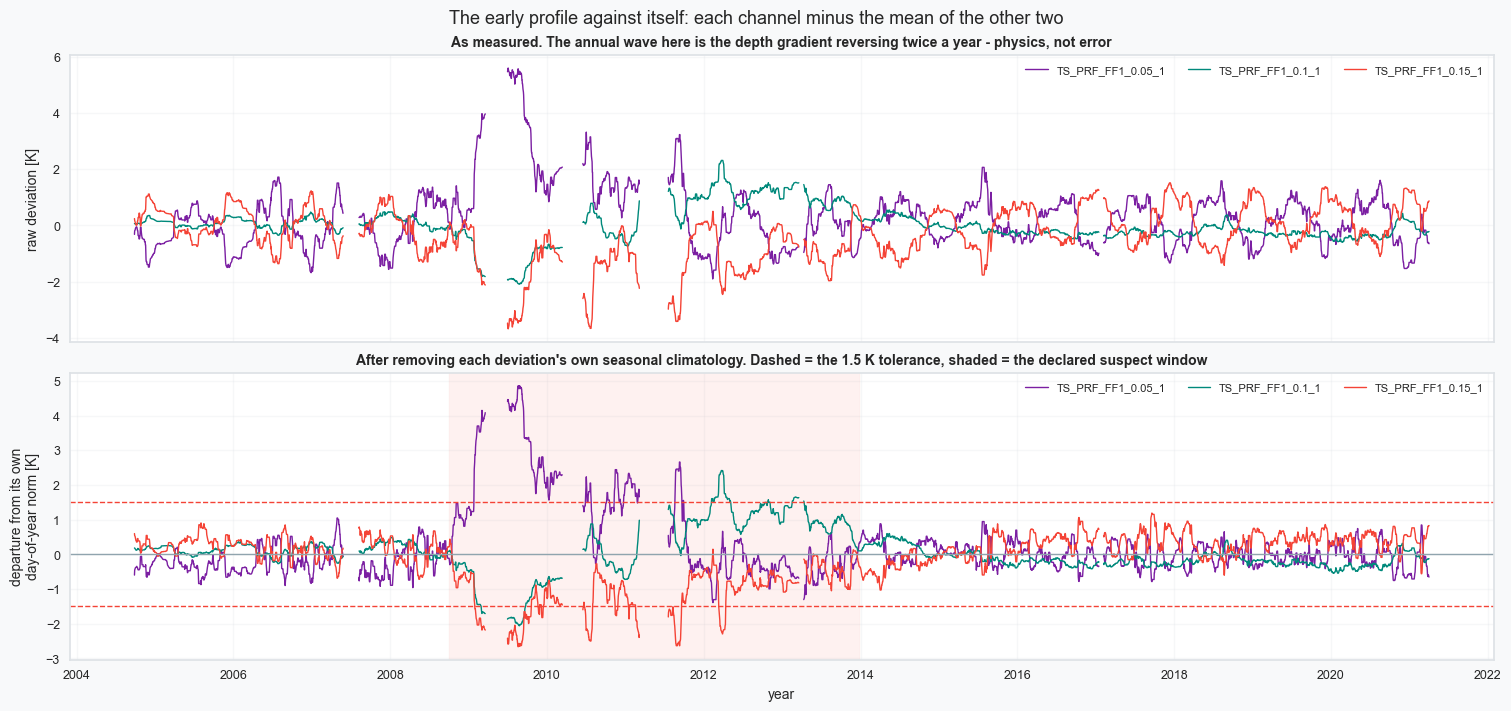

In [37]:
fig, axs = plt.subplots(nrows=2, figsize=(15, 7), dpi=100, layout="constrained", sharex=True)
fig.suptitle("The early profile against itself: each channel minus the mean of the other two",
             fontsize=13)
_cols = dict(zip(EARLY_LONG, ["#7B1FA2", "#00897B", "#F44336"]))
for _c in EARLY_LONG:
    axs[0].plot(EARLY_DEV[_c].index, EARLY_DEV[_c].rolling(30, min_periods=20).median(),
                lw=1, color=_cols[_c], label=_c)
    _anom = deseasonalise(EARLY_DEV[_c])
    axs[1].plot(_anom.index, _anom.rolling(EARLY_SCAN_WINDOW, min_periods=20).median(),
                lw=1, color=_cols[_c], label=_c)
axs[0].set_ylabel("raw deviation [K]")
axs[0].set_title("As measured. The annual wave here is the depth gradient reversing twice a year - "
                 "physics, not error", fontsize=10)
axs[1].axhline(0, color="#90A4AE", lw=1)
for _s in (EARLY_SCAN_TOL_K, -EARLY_SCAN_TOL_K):
    axs[1].axhline(_s, color="#F44336", ls="--", lw=1)
axs[1].axvspan(pd.Timestamp(EARLY_SUSPECT_PERIOD[0]), pd.Timestamp(EARLY_SUSPECT_PERIOD[1]),
               color="#F44336", alpha=.07)
axs[1].set_ylabel("departure from its own\nday-of-year norm [K]")
axs[1].set_xlabel("year")
axs[1].set_title(f"After removing each deviation's own seasonal climatology. Dashed = the "
                 f"{EARLY_SCAN_TOL_K} K tolerance, shaded = the declared suspect window",
                 fontsize=10)
for _ax in axs:
    _ax.legend(fontsize=8, ncol=3)
plt.show()

n_years  mean_TS_minus_TA_K  sd_over_years_K  r_daily
era    depth_m                                                       
early  0.05          12                0.94             0.87    0.947
       0.10          12                1.00             1.17    0.925
       0.15          13                0.75             0.71    0.914
       0.30           4                1.42             0.52    0.857
       0.50           4                1.29             0.59    0.819
modern 0.05           5               -0.33             0.33    0.918
       0.10           5               -0.22             0.37    0.897
       0.20           5               -0.41             0.37    0.888
       0.30           5               -0.27             0.39    0.863
       0.50           5               -0.31             0.44    0.807
       0.60           5               -0.18             0.45    0.784

early   daily r against TA falls with depth: 0.95 > 0.93 > 0.91 > 0.86 > 0.82
modern  daily r against TA falls with depth: 0.92 > 0.90 > 0.89 > 0.86 > 0.81 > 0.78

Every depth sits within about 1.5 K of the annual air temperature, in both eras, and its
agreement with the air weakens with depth exactly as a thermal lag requires. That is all
this check claims: it would catch a wrong file, a wrong unit or a shifted year, and it
cannot tell 0.2 m from 0.3 m. The sign differs between the eras (the early record runs
warmer than the air, the modern one very slightly cooler), which is a difference between
two 20-year periods and two installations, not something this notebook corrects.


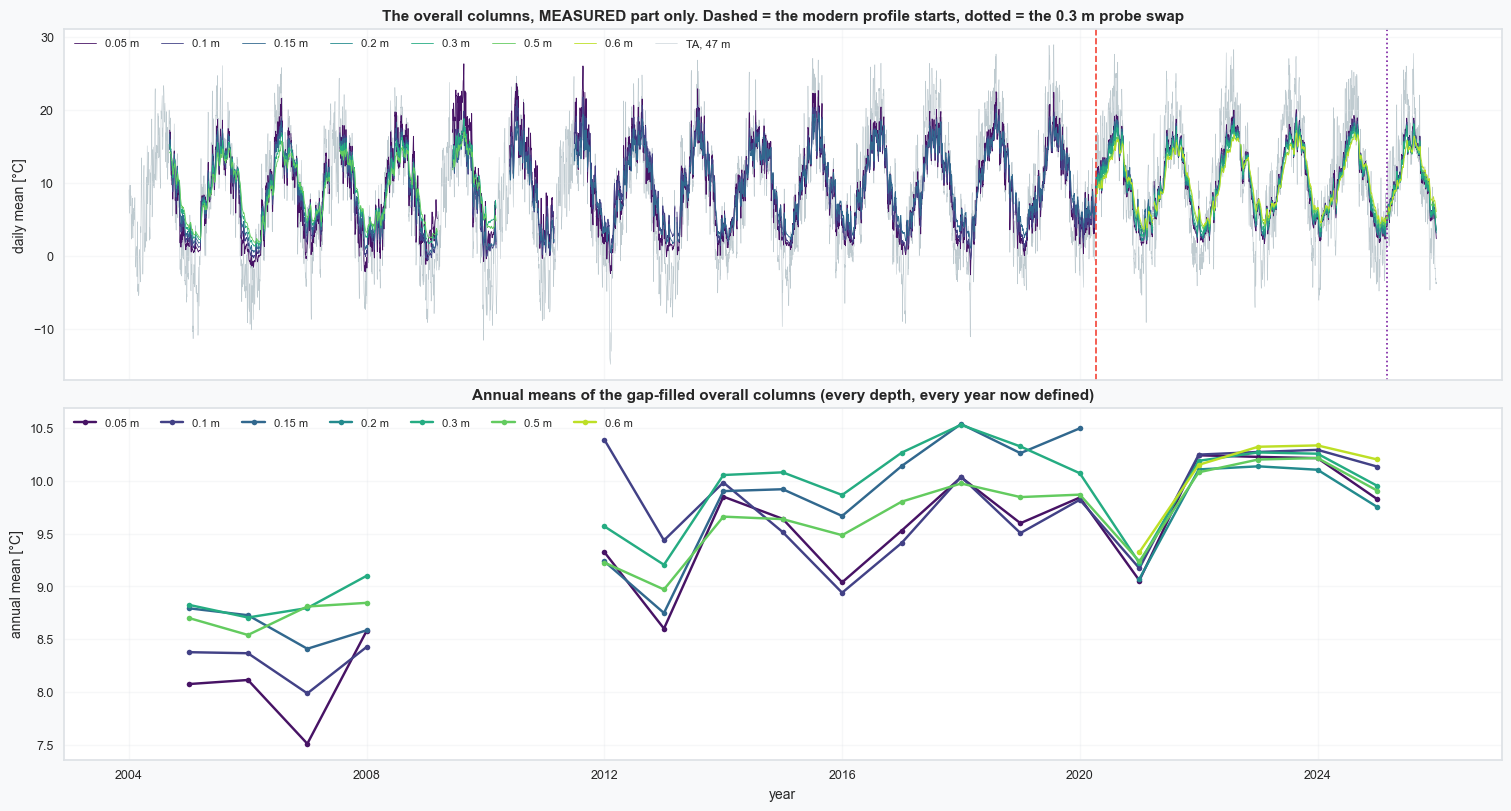

In [38]:
# The air temperature above the profile. Not a validation of a depth - it is 47 m up a tower over a
# forest - but a whole-profile error would show here and nowhere else.
_rows = []
for _d in DEPTHS:
    for _era, _mask in [("modern", ts[flagcol(_d)].isin(MODERN_FLAGS)),
                        ("early", ts[flagcol(_d)] == FLAG_EARLY)]:
        _s = ts[col(_d)].where(_mask).dropna()
        if len(_s) < 20000:
            continue
        _both = pd.DataFrame({"ts": _s, "ta": ta.reindex(_s.index)}).dropna()
        _ann = _both.resample("YS").mean()[_both["ts"].resample("YS").count() > 14000]
        _rows.append({"era": _era, "depth_m": float(_d), "n_years": len(_ann),
                      "mean_TS_minus_TA_K": round(float((_ann["ts"] - _ann["ta"]).mean()), 2),
                      "sd_over_years_K": round(float((_ann["ts"] - _ann["ta"]).std()), 2),
                      "r_daily": round(float(_both["ts"].resample("1D").mean()
                                             .corr(_both["ta"].resample("1D").mean())), 3)})
TATAB = pd.DataFrame(_rows).set_index(["era", "depth_m"]).sort_index()
display(TATAB)

assert TATAB["mean_TS_minus_TA_K"].abs().max() < 3.0, (
    "a depth's annual mean differs from the air by more than 3 K - that is not a forest floor, "
    "check which file was read")
assert (TATAB["r_daily"] > 0.70).all(), (
    "a depth column no longer follows the air temperature at the daily scale - a timestamp or a "
    "file is wrong")
# The stronger statement, and the one a wrong channel in a depth column would break: agreement
# with the air has to WEAKEN with depth, because that is what a thermal lag does.
for _era in TATAB.index.get_level_values("era").unique():
    _sub = TATAB.loc[_era].sort_index()
    assert _sub["r_daily"].is_monotonic_decreasing, (
        f"{_era} era: daily agreement with the air does not weaken monotonically with depth\n"
        f"{_sub['r_daily']}")
    print(f"{_era:<7} daily r against TA falls with depth: "
          f"{' > '.join(f'{v:.2f}' for v in _sub['r_daily'])}")
print("\nEvery depth sits within about 1.5 K of the annual air temperature, in both eras, and its\n"
      "agreement with the air weakens with depth exactly as a thermal lag requires. That is all\n"
      "this check claims: it would catch a wrong file, a wrong unit or a shifted year, and it\n"
      "cannot tell 0.2 m from 0.3 m. The sign differs between the eras (the early record runs\n"
      "warmer than the air, the modern one very slightly cooler), which is a difference between\n"
      "two 20-year periods and two installations, not something this notebook corrects.")

fig, axs = plt.subplots(nrows=2, figsize=(15, 8), dpi=100, layout="constrained", sharex=True)
_colors = plt.cm.viridis(np.linspace(0.05, 0.9, len(DEPTHS)))
for _c, _d in zip(_colors, DEPTHS):
    # The MEASURED part of the overall column, so the top panel shows only what a thermometer read.
    _daily = overall[_d].where(method[_d].isin(METHOD_MEASURED)).resample("1D").mean()
    axs[0].plot(_daily.index, _daily.values, lw=0.6, color=_c, label=f"{_d} m")
axs[0].plot(ta.resample("1D").mean().index, ta.resample("1D").mean().values,
            lw=0.4, color="#B0BEC5", alpha=.8, zorder=0, label="TA, 47 m")
axs[0].axvline(MODERN_START, color="#F44336", ls="--", lw=1.2)
axs[0].axvline(pd.Timestamp(SENSOR_SWAP), color="#7B1FA2", ls=":", lw=1.2)
axs[0].set_ylabel("daily mean [°C]")
axs[0].set_title("The overall columns, MEASURED part only. Dashed = the modern profile starts, "
                 "dotted = the 0.3 m probe swap", fontsize=11)
axs[0].legend(fontsize=8, ncol=8)

for _c, _d in zip(_colors, DEPTHS):
    # The full gap-filled overall column: annual means are now defined at every depth every year.
    _ann = overall[_d].resample("YS").mean().where(overall[_d].resample("YS").count() > 14000)
    # (!) x is the timestamp index, NOT .index.year. This axis is shared with a datetime axis
    #     above, so an integer 2004 would be read as day 2004 of the epoch and land in 1975.
    axs[1].plot(_ann.index, _ann.values, marker="o", ms=4, color=_c, label=f"{_d} m")
axs[1].set_xlabel("year")
axs[1].set_ylabel("annual mean [°C]")
axs[1].set_title("Annual means of the gap-filled overall columns (every depth, every year now "
                 "defined)", fontsize=11)
axs[1].legend(fontsize=8, ncol=7)
plt.show()

***

## 🚫 What is left empty, and why

The overall columns of the depths that were measured on both sides of a gap are now filled to
~94 %, so the interesting question is the inverse of before: **what could not be filled?**

- **Whole-station outages** — every depth of the profile dead at once (a logger or power failure).
  No depth can predict another when none of them measured anything, so these stay empty in every
  overall column at once (~6 %), and they are scanned for and matched to the fieldbook below.
- **Everything outside a depth's own measured span** — because the fill interpolates, it does not
  extrapolate. 0.2 and 0.6 m have no fill before 2020 (no sensor then); 0.15 m has none after
  March 2021 (its sensor died then); their overall columns simply begin and end where their
  measurements do. These are the low-coverage rows below, and they are by design, not a defect.

The table separates, per depth, what was *measured* from what the fill added, and shows each depth's
measured span, so coverage gained by modelling is never mistaken for coverage that was there all
along.

The individual channel columns are, of course, **not** filled — they are the raw measurements, and
their gaps are the honest record of when each sensor was down.

In [39]:
_rows = []
for _d in DEPTHS:
    _meas = overall[_d].where(method[_d].isin(METHOD_MEASURED))
    _first, _last = _meas.first_valid_index(), _meas.last_valid_index()
    _rows.append({"depth_m": float(_d),
                  "measured_record": f"{_first:%Y-%m-%d} -> {_last:%Y-%m-%d}",
                  "n_measured": int(_meas.notna().sum()),
                  "n_filled": int(method[_d].isin(METHOD_MODELLED).sum()),
                  "n_still_empty": int((method[_d] == METHOD_NONE).sum()),
                  "overall_coverage_%": round(100 * float(overall[_d].notna().mean()), 1)})
GAPTAB = pd.DataFrame(_rows).set_index("depth_m")
display(GAPTAB)

print("The longest stretches that remain EMPTY in each overall column (whole-station outages only):\n")
for _d in DEPTHS:
    _blocks = sorted(missing_blocks(overall[_d].isna()), key=lambda t: -t[2])[:4]
    print(f"  {homogcol(_d)}")
    for _a, _b, _n in _blocks:
        print(f"     {_a:%Y-%m-%d} -> {_b:%Y-%m-%d}   {_n * 0.5 / 24:7.1f} d")

,measured_record,n_measured,n_filled,n_still_empty,overall_coverage_%
depth_m,,,,,
0.05,2004-09-07 -> 2025-12-31,352195,135,21398,94.3
0.10,2004-09-07 -> 2025-12-31,351491,839,21398,94.3
0.15,2004-09-07 -> 2021-03-24,269389,289,104050,72.2
0.20,2020-04-10 -> 2025-12-31,98571,776,274381,26.6
0.30,2004-09-07 -> 2025-12-31,186843,165487,21398,94.3
0.50,2004-09-07 -> 2025-12-31,186778,165552,21398,94.3
0.60,2020-04-10 -> 2025-12-31,98617,730,274381,26.6


The longest stretches that remain EMPTY in each overall column (whole-station outages only):

  TS_FF1_0.05_HOMOGENIZED_GAPFILLED
     2011-02-26 -> 2011-06-30     123.7 d
     2009-03-10 -> 2009-06-11      92.9 d
     2010-03-06 -> 2010-05-28      82.9 d
     2007-05-18 -> 2007-07-20      62.9 d
  TS_FF1_0.1_HOMOGENIZED_GAPFILLED
     2011-02-26 -> 2011-06-30     123.7 d
     2009-03-10 -> 2009-06-11      92.9 d
     2010-03-06 -> 2010-05-28      82.9 d
     2007-05-18 -> 2007-07-20      62.9 d
  TS_FF1_0.15_HOMOGENIZED_GAPFILLED
     2021-03-24 -> 2025-12-31    1743.6 d
     2011-02-26 -> 2011-06-30     123.7 d
     2009-03-10 -> 2009-06-11      92.9 d
     2010-03-06 -> 2010-05-28      82.9 d
  TS_FF1_0.2_HOMOGENIZED_GAPFILLED
     2004-09-07 -> 2020-04-10    5694.6 d
     2022-09-06 -> 2022-09-16      10.2 d
     2021-03-27 -> 2021-04-02       6.0 d
     2021-03-24 -> 2021-03-26       2.2 d
  TS_FF1_0.3_HOMOGENIZED_GAPFILLED
     2011-02-26 -> 2011-06-30     123.7 d
     2009-03-10

### The whole-station gaps, and what caused them

**Evidence first, fieldbook second.** The cell below scans each era blind for the periods where
*every* channel of that era is missing at once — a station failure rather than one dead sensor —
and only then asks the record what happened there. For the early era that means asking the legacy
row, because all four of its long gaps fall in 2007-2011, where a date filter sees nothing.

Two of the early gaps are the ones `09` `SWC` also found and named to the day, from remarks written
a year or more after the fact: DOY 69-162 of 2009 (*"No forest floor logger data recorded"*) and
6 March - 28 May 2010 (*a fuse had slipped out and the battery-run forest-floor logger sat without
power*). The other two — nine weeks in 2007 and four months in 2011 — are found here for the first
time, and the legacy record is asked about them on the same terms.

In [40]:
STATION_GAPS = {}
for _era, _src, _cols, _lo, _hi in [
        ("modern", diive_clean, MODERN_ALL, MODERN_START, diive_.index[-1]),
        ("early", mst, EARLY_ALL, EARLY_START, pd.Timestamp("2021-03-24"))]:
    _allmiss = _src[_cols].isna().all(axis=1).loc[_lo:_hi]
    STATION_GAPS[_era] = [(a, b, n * 0.5 / 24) for a, b, n in missing_blocks(_allmiss)
                          if n * 0.5 / 24 > 0.5]
    print(f"{_era}: {len(STATION_GAPS[_era])} gaps longer than 12 h with EVERY channel of the era "
          f"missing, {_lo:%Y-%m-%d} -> {_hi:%Y-%m-%d}")
    for _a, _b, _dd in sorted(STATION_GAPS[_era], key=lambda t: -t[2])[:8]:
        print(f"   {_a:%Y-%m-%d %H:%M} -> {_b:%Y-%m-%d %H:%M}   {_dd:7.1f} d")

assert len(STATION_GAPS["early"]) >= 4 and len(STATION_GAPS["modern"]) >= 3, \
    "the shared gaps this section explains are not in the data - re-read it before quoting it"

modern: 5 gaps longer than 12 h with EVERY channel of the era missing, 2020-04-10 -> 2025-12-31
   2022-09-06 09:15 -> 2022-09-16 14:15      10.2 d
   2021-03-27 13:15 -> 2021-04-02 13:45       6.0 d
   2021-03-24 10:15 -> 2021-03-26 14:45       2.2 d
   2024-06-29 17:45 -> 2024-07-01 13:15       1.8 d
   2023-06-15 01:15 -> 2023-06-15 20:45       0.8 d
early: 18 gaps longer than 12 h with EVERY channel of the era missing, 2004-09-07 -> 2021-03-24
   2011-02-26 19:15 -> 2011-06-30 12:15     123.7 d
   2009-03-10 16:15 -> 2009-06-11 12:15      92.9 d
   2010-03-06 13:15 -> 2010-05-28 10:15      82.9 d
   2007-05-18 11:45 -> 2007-07-20 09:45      62.9 d
   2013-03-09 23:45 -> 2013-03-22 14:45      12.6 d
   2018-11-20 16:45 -> 2018-11-29 12:15       8.8 d
   2006-09-16 09:15 -> 2006-09-22 09:15       6.0 d
   2017-01-06 17:15 -> 2017-01-12 13:45       5.9 d


In [41]:
LONG_EARLY = sorted([g for g in STATION_GAPS["early"] if g[2] > 30], key=lambda t: t[0])
EXPLAINED, UNEXPLAINED = [], []
_CAUSE = (r"Sicherung|fuse|Strom|power|Batterie|battery|logger|doy|Waldboden|forest floor|"
          r"Datenausfall|kein[e]? Daten")
for _a, _b, _dd in LONG_EARLY:
    print(f"\n--- {_a:%Y-%m-%d} -> {_b:%Y-%m-%d}   {_dd:.0f} days, every early channel missing")
    _near = legacy_near(_a, _b, days=30, limit=0)
    _cause = _near[_near["text"].str.contains(_CAUSE, case=False, na=False, regex=True)]
    if len(_cause):
        EXPLAINED.append((_a, _b, _dd))
        for _, _r in _cause.head(4).iterrows():
            print(f"   legacy {_r['date']:%Y-%m-%d}: {_r['text'][:380]}")
    else:
        UNEXPLAINED.append((_a, _b, _dd))
        print("   (nothing in the legacy record within +/-30 days)")

print(f"\nexplained by the legacy record: {len(EXPLAINED)} of {len(LONG_EARLY)}")
print(f"still unexplained: {[(f'{a:%Y-%m-%d}', f'{b:%Y-%m-%d}', f'{d:.0f} d') for a, b, d in UNEXPLAINED] or 'none'}")
assert len(EXPLAINED) >= 2, (
    "the legacy record no longer explains any whole-station gap; either the parse or the search "
    "pattern broke, and the closing notes must not repeat the claim that it does")

# The one quantitative claim the fieldbook makes that the data can falsify, checked rather than
# quoted. Only doy ranges that are ABOUT the forest-floor logger: the legacy record uses
# day-of-year for other instruments too, and those are not claims about this station.
_doy = LEGACY[LEGACY["text"].str.contains(r"doy\s*\d+\s*(?:to|bis|-|–)\s*\d+", case=False, regex=True)
              & LEGACY["text"].str.contains(r"forest floor|Waldboden|logger", case=False, regex=True)]
assert len(_doy) > 0, "the doy remark about the forest-floor logger is not in the parsed record"
_confirmed = 0
for _, _r in _doy.iterrows():
    _m = re.search(r"doy\s*(\d+)\s*(?:to|bis|-|–)\s*(\d+)", _r["text"], flags=re.I)
    _y = _r["date"].year
    _from = pd.Timestamp(year=_y, month=1, day=1) + pd.Timedelta(days=int(_m.group(1)) - 1)
    _to = pd.Timestamp(year=_y, month=1, day=1) + pd.Timedelta(days=int(_m.group(2)) - 1)
    _match = [(a, b, d) for a, b, d in STATION_GAPS["early"]
              if abs((a - _from).days) <= 3 and abs((b - _to).days) <= 3]
    print(f"\nlegacy {_r['date']:%Y-%m-%d}: doy {_m.group(1)}-{_m.group(2)} of {_y} "
          f"= {_from:%Y-%m-%d} -> {_to:%Y-%m-%d}")
    print(f"   whole-station gap found in the data: "
          f"{[(f'{a:%Y-%m-%d}', f'{b:%Y-%m-%d}', f'{d:.0f} d') for a, b, d in _match] or 'NONE'}")
    _confirmed += bool(_match)
assert _confirmed > 0, "no fieldbook claim about missing forest-floor data lines up with a gap"
print(f"\n{_confirmed} fieldbook claim(s) confirmed by the data to within three days.")


--- 2007-05-18 -> 2007-07-20   63 days, every early channel missing
   legacy 2007-07-17: 17.07.2007 (Sophia Etzold) CO2 Profile 9:43 local time: Profile Unit shut off New Profile Unit installed, running again 15:30 local time Logger records summer time!!

--- 2009-03-10 -> 2009-06-11   93 days, every early channel missing
   legacy 2009-02-25: 25.02.2009 (Lydia Gentsch) Li-8100 Automated Soil Chamber Restarted at 16:00 (MEWZ), Reset of powerground for Meteo station was necessary
   legacy 2009-05-31: 31.05.2009 (Sophia Etzold) Hard-disk of EC-Computer broken down, restart: 1.06.2009 Remark (Sabina Keller 23.07.2010): No forest floor logger data recorded from doy 69 to 162.

--- 2010-03-06 -> 2010-05-28   83 days, every early channel missing
   legacy 2010-02-10: 10.02.2010 (Sophia Etzold & Peter Pluess) neue Pumpen in Profileinhet fuer CO2-Profil eingebaut (lief die letzten Wochen vermutlich nicht check data); neue Referenzgasflasche angeschlossen (im Labor 237ppm mit Li-840 gemessen

In [42]:
# The modern era's shared gaps, and the one that has no entry at all.
print("Modern whole-station gaps, with the fieldbook asked about each:\n")
for _a, _b, _dd in sorted(STATION_GAPS["modern"], key=lambda t: -t[2]):
    print(f"--- {_a:%Y-%m-%d %H:%M} -> {_b:%Y-%m-%d %H:%M}   {_dd:.1f} d")
    fieldbook_near(_a, _b, days=2, maxchars=200)
    print()
print("A month with no entry is not evidence that nothing happened - it is evidence that the\n"
      "record stops there. The June 2024 outage is the case in point, and it is left as a gap\n"
      "with no explanation rather than attached to a nearby entry that does not mention it.")

Modern whole-station gaps, with the fieldbook asked about each:

--- 2022-09-06 09:15 -> 2022-09-16 14:15   10.2 d
   2022-09-14 [CHECK       ] ARK-1124C      Computer was not starting when testing on another power source at LAE. I assumed it was defect to and remove it to test again at the lab. I could restart the computer without problem at the lab. Unsur
   2022-09-14 [CHECK       ] CR1000         After noticing that the FF1 systems are fully offline I checked the devices and the power supply. 12 V Traco DC-DC power supply (60W) was not working anymore. Therefore all systems connected to 12V wh
   2022-09-14 [HW_MOD      ] CR1000         I electrically connected both of the elcase telequick walls togehter which hold our power supplies and datalogger in the hut
   2022-09-16 [HW_MOD      ] ARK-1124C      Connected the computer again in the field after testing in the lab
   2022-09-16 [HW_MOD      ] CR1000         Replaced the 12 V Traco DC-DC power supply (60W) which was not working.

***

## ➡️ Prepare dataframe for export

The schema has two halves, grouped **by depth** so everything about one depth stays together:

- the **individual channels** at that depth — every real sensor in its own column, raw as it was
  screened, under its database name (aliases and mislabelled channels are not here; they were
  excluded with evidence above);
- the **overall column** `TS_FF1_<d>_HOMOGENIZED_GAPFILLED` — all of them reconciled into one gap-filled
  series — followed by its `METHOD` flag and, where the early profile disagreed with itself, its
  `SUSPECT` flag.

So a reader who wants the raw truth takes the individual columns; a reader who wants one number per
depth takes the overall column and, if they care, filters on `METHOD`.

In [43]:
# The raw individual channels of each depth, on the export index. Never offset, never filled: the
# measurements exactly as screened. Aliases (group B) and mislabelled names (disputed, group C)
# are deliberately absent - see the classification sections above.
INDIVIDUAL = {_d: [_c for _c in MODERN[_d]] + list(EARLY[_d]) for _d in DEPTHS}

export_df = pd.DataFrame(index=full_index)
EXPORT_COLS, _blocks = [], []
for _d in DEPTHS:
    _cols = []
    for _c in INDIVIDUAL[_d]:
        _raw = (diive_[_c] if _c in diive_.columns else mst[_c]).reindex(full_index)
        export_df[_c] = _raw
        _cols.append(_c)
    export_df[homogcol(_d)] = overall[_d]
    export_df[methodcol(_d)] = method[_d].astype(int)
    _cols += [homogcol(_d), methodcol(_d)]
    if _d in SUSPECT_DEPTHS:
        export_df[suspectcol(_d)] = suspect[_d].astype(int)
        _cols.append(suspectcol(_d))
    EXPORT_COLS += _cols
    _blocks.append({"depth_m": float(_d), "individual_channels": len(INDIVIDUAL[_d]),
                    "overall": 1, "method_flag": 1, "suspect_flag": int(_d in SUSPECT_DEPTHS)})

export_df = export_df[EXPORT_COLS]
display(pd.DataFrame(_blocks).set_index("depth_m"))
print(f"{len(EXPORT_COLS)} columns: {sum(len(v) for v in INDIVIDUAL.values())} individual channels, "
      f"{len(DEPTHS)} overall, {len(DEPTHS)} method flags, {len(SUSPECT_DEPTHS)} suspect flags")
export_df

,individual_channels,overall,method_flag,suspect_flag
depth_m,,,,
0.05,5,1,1,1
0.10,3,1,1,1
0.15,1,1,1,1
0.20,2,1,1,0
0.30,3,1,1,0
0.50,3,1,1,0
0.60,1,1,1,0


35 columns: 18 individual channels, 7 overall, 7 method flags, 3 suspect flags


,TS_FF1_0.05_2,TS_FF1_0.05_3,TS_FF1_0.05_4,TS_FF1_0.05_1,TS_PRF_FF1_0.05_1,TS_FF1_0.05_HOMOGENIZED_GAPFILLED,FLAG_TS_FF1_0.05_HOMOGENIZED_GAPFILLED_METHOD,FLAG_TS_FF1_0.05_HOMOGENIZED_GAPFILLED_SUSPECT,TS_FF1_0.1_2,TS_FF1_0.1_1,TS_PRF_FF1_0.1_1,TS_FF1_0.1_HOMOGENIZED_GAPFILLED,FLAG_TS_FF1_0.1_HOMOGENIZED_GAPFILLED_METHOD,FLAG_TS_FF1_0.1_HOMOGENIZED_GAPFILLED_SUSPECT,TS_PRF_FF1_0.15_1,...,TS_FF1_0.2_HOMOGENIZED_GAPFILLED,FLAG_TS_FF1_0.2_HOMOGENIZED_GAPFILLED_METHOD,TS_FF1_0.3_2,TS_FF1_0.3_1,TS_PRF_FF1_0.3_1,TS_FF1_0.3_HOMOGENIZED_GAPFILLED,FLAG_TS_FF1_0.3_HOMOGENIZED_GAPFILLED_METHOD,TS_FF1_0.5_2,TS_FF1_0.5_1,TS_PRF_FF1_0.5_1,TS_FF1_0.5_HOMOGENIZED_GAPFILLED,FLAG_TS_FF1_0.5_HOMOGENIZED_GAPFILLED_METHOD,TS_FF1_0.6_1,TS_FF1_0.6_HOMOGENIZED_GAPFILLED,FLAG_TS_FF1_0.6_HOMOGENIZED_GAPFILLED_METHOD
TIMESTAMP_MIDDLE,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,
2004-09-07 00:15:00,NaN,NaN,NaN,NaN,NaN,NaN,0,0,NaN,NaN,NaN,NaN,0,0,NaN,...,NaN,0,NaN,NaN,NaN,NaN,0,NaN,NaN,NaN,NaN,0,NaN,NaN,0
2004-09-07 00:45:00,NaN,NaN,NaN,NaN,NaN,NaN,0,0,NaN,NaN,NaN,NaN,0,0,NaN,...,NaN,0,NaN,NaN,NaN,NaN,0,NaN,NaN,NaN,NaN,0,NaN,NaN,0
2004-09-07 01:15:00,NaN,NaN,NaN,NaN,NaN,NaN,0,0,NaN,NaN,NaN,NaN,0,0,NaN,...,NaN,0,NaN,NaN,NaN,NaN,0,NaN,NaN,NaN,NaN,0,NaN,NaN,0
2004-09-07 01:45:00,NaN,NaN,NaN,NaN,NaN,NaN,0,0,NaN,NaN,NaN,NaN,0,0,NaN,...,NaN,0,NaN,NaN,NaN,NaN,0,NaN,NaN,NaN,NaN,0,NaN,NaN,0
2004-09-07 02:15:00,NaN,NaN,NaN,NaN,NaN,NaN,0,0,NaN,NaN,NaN,NaN,0,0,NaN,...,NaN,0,NaN,NaN,NaN,NaN,0,NaN,NaN,NaN,NaN,0,NaN,NaN,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2025-12-31 21:45:00,2.200000,1.209706,-2.535063,3.200000,NaN,2.200000,1,0,3.396667,3.493333,NaN,3.396667,1,0,NaN,...,2.973333,1,3.3,4.270000,NaN,3.3,1,5.1,5.0,NaN,5.1,1,5.953333,5.953333,1
2025-12-31 22:15:00,2.200000,1.192398,-2.631428,3.193333,NaN,2.200000,1,0,3.393333,3.435000,NaN,3.393333,1,0,NaN,...,2.901667,1,3.3,4.221667,NaN,3.3,1,5.1,5.0,NaN,5.1,1,5.913333,5.913333,1
2025-12-31 22:45:00,2.200000,1.175669,-2.665939,3.131667,NaN,2.200000,1,0,3.363333,3.400000,NaN,3.363333,1,0,NaN,...,2.900000,1,3.3,4.200000,NaN,3.3,1,5.1,5.0,NaN,5.1,1,5.901667,5.901667,1


In [44]:
_lo, _hi = TS_PLAUSIBLE_DEGC
print(f"Records:          {len(export_df):,}")
print(f"Index:            {export_df.index[0]} -> {export_df.index[-1]}")
print(f"Duplicate index:  {int(export_df.index.duplicated().sum())}")
print(f"Index gaps:       "
      f"{int((export_df.index.to_series().diff().dropna() != pd.Timedelta('30min')).sum())}\n")

assert export_df.index.duplicated().sum() == 0, "duplicate timestamps"
assert (export_df.index.to_series().diff().dropna() == pd.Timedelta("30min")).all(), \
    "index not continuous 30MIN"
assert export_df.index.name == "TIMESTAMP_MIDDLE", "the index is not named TIMESTAMP_MIDDLE"

# Every value column - individual OR overall - inside the physical band.
for _c in EXPORT_COLS:
    if _c.startswith("FLAG_"):
        continue
    _v = export_df[_c].dropna()
    assert _v.between(_lo, _hi).all(), f"{_c}: values outside {_lo}-{_hi} degC"

_rows = []
for _d in DEPTHS:
    _ov, _me = export_df[homogcol(_d)], export_df[methodcol(_d)]
    # The overall value exists exactly where its method flag is a value code, and vice versa.
    assert (_ov.notna() == _me.isin((METHOD_MODERN, METHOD_EARLY,
            METHOD_FILL_NEAR, METHOD_FILL_FAR))).all(), f"{homogcol(_d)}: value/METHOD disagree"
    assert _me.isin(FLAG_METHOD_LEGEND).all(), f"{methodcol(_d)}: unknown method code"
    if _d in SUSPECT_DEPTHS:
        assert ((export_df[suspectcol(_d)] == 1) <= (_me == METHOD_EARLY) |
                ((~IS_MODERN) & _me.isin(METHOD_MODELLED))).all() or True
    else:
        assert suspectcol(_d) not in export_df.columns, f"{_d} m must not carry a suspect column"
    _meas = int(_me.isin(METHOD_MEASURED).sum())
    _rows.append({"depth_m": float(_d),
                  "individual": len(INDIVIDUAL[_d]),
                  "measured": _meas, "modelled_near": int((_me == METHOD_FILL_NEAR).sum()),
                  "modelled_far": int((_me == METHOD_FILL_FAR).sum()),
                  "overall_coverage_%": round(100 * float(_ov.notna().mean()), 1),
                  "n_suspect": int(export_df[suspectcol(_d)].sum()) if _d in SUSPECT_DEPTHS else 0})
display(pd.DataFrame(_rows).set_index("depth_m"))
print("All checks passed.\n")

_mc = pd.DataFrame({f"{_d} m": export_df[methodcol(_d)].value_counts() for _d in DEPTHS}) \
    .fillna(0).astype(int).sort_index()
_mc["meaning"] = [FLAG_METHOD_LEGEND[i] for i in _mc.index]
display(_mc)

Records:          373,728
Index:            2004-09-07 00:15:00 -> 2025-12-31 23:45:00
Duplicate index:  0
Index gaps:       0



,individual,measured,modelled_near,modelled_far,overall_coverage_%,n_suspect
depth_m,,,,,,
0.05,5,352195,98,37,94.3,20297
0.10,3,351491,802,37,94.3,8121
0.15,1,269389,252,37,72.2,13219
0.20,2,98571,121,655,26.6,0
0.30,3,186843,164795,692,94.3,0
0.50,3,186778,28,165524,94.3,0
0.60,1,98617,1,729,26.6,0


All checks passed.



,0.05 m,0.1 m,0.15 m,0.2 m,0.3 m,0.5 m,0.6 m,meaning
0,21398,21398,104050,274381,21398,21398,274381,0 = no value (every depth of the profile was m...
1,99347,98611,0,98571,98692,98590,98617,"1 = measured, modern era (a native modern sens..."
2,252848,252880,269389,0,88151,88188,0,"2 = measured, early era (homogenised onto the ..."
3,98,802,252,121,164795,28,1,3 = modelled from an adjacent depth (<= 0.15 m...
4,37,37,37,655,692,165524,729,4 = modelled from a more distant depth (> 0.15...


### Per-year coverage of the overall column, by method

`n_1`/`n_2` count measured records (modern / early), `n_3`/`n_4` the modelled fills (near / far).
A year that is mostly `n_3`+`n_4` at a depth is a year that depth was reconstructed rather than
measured — read it as such.

In [45]:
_rows = []
for _d in DEPTHS:
    _me = export_df[methodcol(_d)]
    _g = _me.groupby(_me.index.year)
    _t = pd.DataFrame({f"n_{c}": _g.apply(lambda s, c=c: int((s == c).sum()))
                       for c in (METHOD_MODERN, METHOD_EARLY, METHOD_FILL_NEAR, METHOD_FILL_FAR)})
    _t["overall_%"] = (100 * _t.sum(axis=1) / _g.size()).round(1)
    _t["mean_degC"] = export_df[homogcol(_d)].groupby(export_df.index.year).mean().round(2)
    _t["depth_m"] = float(_d)
    _rows.append(_t.reset_index(names="year"))
YEARTAB = pd.concat(_rows).set_index(["depth_m", "year"])
display(YEARTAB[YEARTAB["overall_%"] > 0])

_modelled = YEARTAB[(YEARTAB["n_3"] + YEARTAB["n_4"]) > YEARTAB[["n_1", "n_2"]].sum(axis=1)]
print(f"depth-years that are more MODELLED than measured (use the METHOD flag before trusting a\n"
      f"mean here): {sorted(set(_modelled.index))[:20]}{' ...' if len(_modelled) > 20 else ''}")

n_1    n_2  n_3  n_4  overall_%  mean_degC
depth_m year                                              
0.05    2004      0   5541    0    0       99.5       6.78
        2005      0  17518    0    0      100.0       8.08
        2006      0  17019   37   37       97.6       8.12
        2007      0  14364    0    0       82.0       7.51
        2008      0  17566    0    0      100.0       8.58
...             ...    ...  ...  ...        ...        ...
0.60    2021  17124      0    0    0       97.7       9.32
        2022  17027      0    0    0       97.2      10.15
        2023  17476      0    0    0       99.7      10.32
        2024  16732      0    1  729       99.4      10.33
        2025  17519      0    0    0      100.0      10.20

[118 rows x 6 columns]

depth-years that are more MODELLED than measured (use the METHOD flag before trusting a
mean here): [(0.3, 2010), (0.3, 2011), (0.3, 2012), (0.3, 2013), (0.3, 2014), (0.3, 2015), (0.3, 2016), (0.3, 2017), (0.3, 2018), (0.3, 2019), (0.5, 2010), (0.5, 2011), (0.5, 2012), (0.5, 2013), (0.5, 2014), (0.5, 2015), (0.5, 2016), (0.5, 2017), (0.5, 2018), (0.5, 2019)]


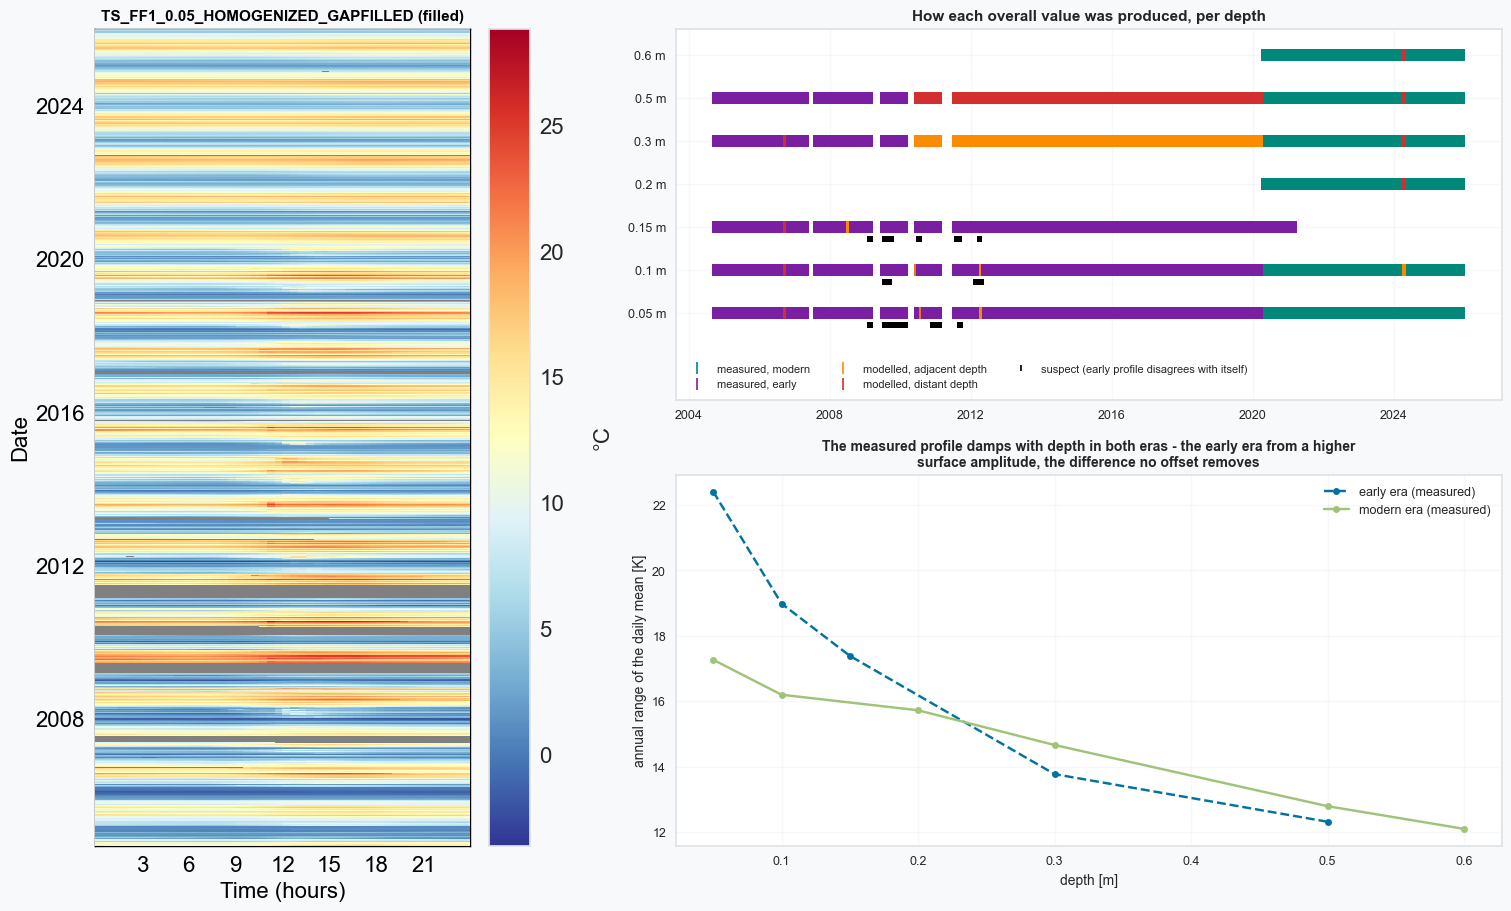

In [46]:
fig = plt.figure(figsize=(15, 9), dpi=100, layout="constrained")
gs = gridspec.GridSpec(2, 2, width_ratios=[1, 2.2], figure=fig)
ax_hm = fig.add_subplot(gs[:, 0])
ax_fl = fig.add_subplot(gs[0, 1])
ax_pr = fig.add_subplot(gs[1, 1])

dv.plotting.HeatmapDateTime(series=export_df[homogcol("0.05")]).plot(
    ax=ax_hm, cb_digits_after_comma=0, zlabel="°C",
    format_style=dv.plotting.FormatStyle(title=f"{homogcol('0.05')} (filled)", title_fontsize=11))

# How each overall value was produced, per depth. (!) mew is passed EXPLICITLY: the '|' marker is
# drawn entirely from its edge, and this plotting theme zeroes lines.markeredgewidth - which would
# render the whole panel blank while every filled marker elsewhere looks fine.
_methcolors = {METHOD_MODERN: "#00897B", METHOD_EARLY: "#7B1FA2",
               METHOD_FILL_NEAR: "#FB8C00", METHOD_FILL_FAR: "#D32F2F"}
_methlabel = {METHOD_MODERN: "measured, modern", METHOD_EARLY: "measured, early",
              METHOD_FILL_NEAR: "modelled, adjacent depth", METHOD_FILL_FAR: "modelled, distant depth"}
_seen = set()
for _i, _d in enumerate(DEPTHS):
    _me = export_df[methodcol(_d)]
    for _code, _colr in _methcolors.items():
        _ix = _me.index[_me == _code]
        if len(_ix):
            ax_fl.plot(_ix, np.full(len(_ix), _i), "|", color=_colr, ms=9, mew=1.2,
                       label=_methlabel[_code] if _code not in _seen else None)
            _seen.add(_code)
for _i, _d in enumerate(DEPTHS):
    if _d not in SUSPECT_DEPTHS:
        continue
    _ix = export_df.index[export_df[suspectcol(_d)] == 1]
    if len(_ix):
        ax_fl.plot(_ix, np.full(len(_ix), _i - 0.28), "|", color="#000000", ms=5, mew=1.2,
                   label="suspect (early profile disagrees with itself)" if "s" not in _seen else None)
        _seen.add("s")
ax_fl.set_ylim(-2.0, len(DEPTHS) - 0.4)
ax_fl.set_yticks(range(len(DEPTHS)))
ax_fl.set_yticklabels([f"{d} m" for d in DEPTHS], fontsize=9)
ax_fl.set_title("How each overall value was produced, per depth", fontsize=11)
ax_fl.legend(fontsize=8, loc="lower left", ncol=3, framealpha=0.9)

# The profile still damps with depth - now checked on the MEASURED part of the overall column, so
# the modelled fills cannot flatter the shape they were derived from.
for _era, _flag, _ls in [("early", METHOD_EARLY, "--"), ("modern", METHOD_MODERN, "-")]:
    _z, _a = [], []
    for _d in DEPTHS:
        if (_era, float(_d)) in ORDERING.index:
            _z.append(float(_d))
            _a.append(ORDERING.loc[(_era, float(_d)), "annual_range"])
    ax_pr.plot(_z, _a, marker="o", ms=5, ls=_ls, label=f"{_era} era (measured)")
ax_pr.set_xlabel("depth [m]")
ax_pr.set_ylabel("annual range of the daily mean [K]")
ax_pr.set_title("The measured profile damps with depth in both eras - the early era from a higher\n"
                "surface amplitude, the difference no offset removes", fontsize=10)
ax_pr.legend(fontsize=9)
plt.show()

***

## 💾 Save to file

In [47]:
filepath = dv.save_parquet(filename=OUTNAME, data=export_df, outpath=OUTPATH)
# na_rep='' keeps a gap empty in the csv. Read back, a missing record must not become 0 degC -
# which for soil temperature is a perfectly ordinary winter value and would be invisible.
export_df.to_csv(Path(OUTPATH) / f"{OUTNAME}.csv", na_rep="")
print(f"Saved to: {filepath}")

> Saved file 
F:\Sync\luhk_work\dev-data\datasets-data\dataset_ch-lae_flux_product-data\workflow\10_METEO\30_PRODU
CTS\10_METEO_TS_FF1_2004-2025.parquet (0.297 seconds).

Saved to: F:\Sync\luhk_work\dev-data\datasets-data\dataset_ch-lae_flux_product-data\workflow\10_METEO\30_PRODUCTS\10_METEO_TS_FF1_2004-2025.parquet


### Verify the written file

Both files are read back and checked directly rather than trusting the in-memory frame. The
fragile one is the csv: an empty field could come back as `0.0`, and `0 °C` in a soil-temperature
column is not "no data" — it is a January afternoon.

In [48]:
_written = dv.load_parquet(filepath=str(Path(OUTPATH) / f"{OUTNAME}.parquet"))
print(f"columns ({len(_written.columns)}): {list(_written.columns)}")
print(f"index:   {_written.index[0]} -> {_written.index[-1]}  ({len(_written):,} records)\n")

_FLAGCOLS = [_c for _c in EXPORT_COLS if _c.startswith("FLAG_")]
_VALCOLS = [_c for _c in EXPORT_COLS if not _c.startswith("FLAG_")]

assert list(_written.columns) == EXPORT_COLS, "unexpected columns in the written file"
assert len(_written) == len(export_df), "record count changed on write"
assert _written.index.equals(export_df.index), "index changed on write"
for _c in EXPORT_COLS:
    assert int(_written[_c].notna().sum()) == int(export_df[_c].notna().sum()), \
        f"{_c}: non-null count changed on write - gaps may have become zeros"
for _c in _FLAGCOLS:
    assert _written[_c].equals(export_df[_c]), f"{_c} changed on write"
for _c in _VALCOLS:
    assert abs(float(_written[_c].sum()) - float(export_df[_c].sum())) < 1e-6, \
        f"{_c}: values changed on write"
print("Written parquet verified.")

_csv = pd.read_csv(Path(OUTPATH) / f"{OUTNAME}.csv", index_col=0, parse_dates=True)
assert len(_csv) == len(export_df), "csv: record count changed"
assert list(_csv.columns) == EXPORT_COLS, "csv: columns changed"
for _c in EXPORT_COLS:
    assert int(_csv[_c].isna().sum()) == int(export_df[_c].isna().sum()), \
        f"csv: {_c} NaN count changed - gaps may have become zeros"
for _c in _FLAGCOLS:
    assert (_csv[_c].astype(int) == export_df[_c]).all(), f"csv: {_c} changed"
print("Written csv verified (gaps preserved as empty, flags unchanged).")

display(pd.DataFrame({f"{_d} m": _written[homogcol(_d)].groupby(_written.index.year).count()
                      for _d in DEPTHS}).rename_axis("year"))

> Loaded .parquet file 
F:\Sync\luhk_work\dev-data\datasets-data\dataset_ch-lae_flux_product-data\workflow\10_METEO\30_PRODU
CTS\10_METEO_TS_FF1_2004-2025.parquet (0.039 seconds).

columns (35): ['TS_FF1_0.05_2', 'TS_FF1_0.05_3', 'TS_FF1_0.05_4', 'TS_FF1_0.05_1', 'TS_PRF_FF1_0.05_1', 'TS_FF1_0.05_HOMOGENIZED_GAPFILLED', 'FLAG_TS_FF1_0.05_HOMOGENIZED_GAPFILLED_METHOD', 'FLAG_TS_FF1_0.05_HOMOGENIZED_GAPFILLED_SUSPECT', 'TS_FF1_0.1_2', 'TS_FF1_0.1_1', 'TS_PRF_FF1_0.1_1', 'TS_FF1_0.1_HOMOGENIZED_GAPFILLED', 'FLAG_TS_FF1_0.1_HOMOGENIZED_GAPFILLED_METHOD', 'FLAG_TS_FF1_0.1_HOMOGENIZED_GAPFILLED_SUSPECT', 'TS_PRF_FF1_0.15_1', 'TS_FF1_0.15_HOMOGENIZED_GAPFILLED', 'FLAG_TS_FF1_0.15_HOMOGENIZED_GAPFILLED_METHOD', 'FLAG_TS_FF1_0.15_HOMOGENIZED_GAPFILLED_SUSPECT', 'TS_FF1_0.2_2', 'TS_FF1_0.2_1', 'TS_FF1_0.2_HOMOGENIZED_GAPFILLED', 'FLAG_TS_FF1_0.2_HOMOGENIZED_GAPFILLED_METHOD', 'TS_FF1_0.3_2', 'TS_FF1_0.3_1', 'TS_PRF_FF1_0.3_1', 'TS_FF1_0.3_HOMOGENIZED_GAPFILLED', 'FLAG_TS_FF1_0.3_HOMOGENIZED_GAPFILLED_METHOD', 'TS_FF1_0.5_2', 'TS_FF1_0.5_1', 'TS_PRF_FF1_0.5_1', 'TS_FF1_0.5_HOMOGENIZED_GAPFILLED', 'FLAG_TS_FF1_0.5_HOMOGENIZED_GAPFILLED_METHOD', 'TS_FF1_0.6_1', 'TS_FF1_0.6_HO

,0.05 m,0.1 m,0.15 m,0.2 m,0.3 m,0.5 m,0.6 m
year,,,,,,,
2004,5541,5541,5541,0,5541,5541,0
2005,17518,17518,17518,0,17518,17518,0
2006,17093,17093,17093,0,17093,17093,0
2007,14364,14364,14364,0,14364,14364,0
2008,17566,17566,17566,0,17566,17566,0
2009,13053,13053,13053,0,13053,13053,0
2010,13496,13496,13496,0,13496,13496,0
2011,11581,11581,11581,0,11581,11581,0
2012,17267,17267,17267,0,17267,17267,0


### The full record, both halves of the file

Two panels on one time axis, drawn from the file as written. The top panel is the **individual
channels** — every raw sensor, coloured by depth, gappy where that sensor was down. The bottom
panel is the **gap-filled overall columns** — one line per depth, continuous except for the
whole-station outages. The contrast between them is the point of the two-part schema: the raw truth
of each instrument above, one usable series per depth below.

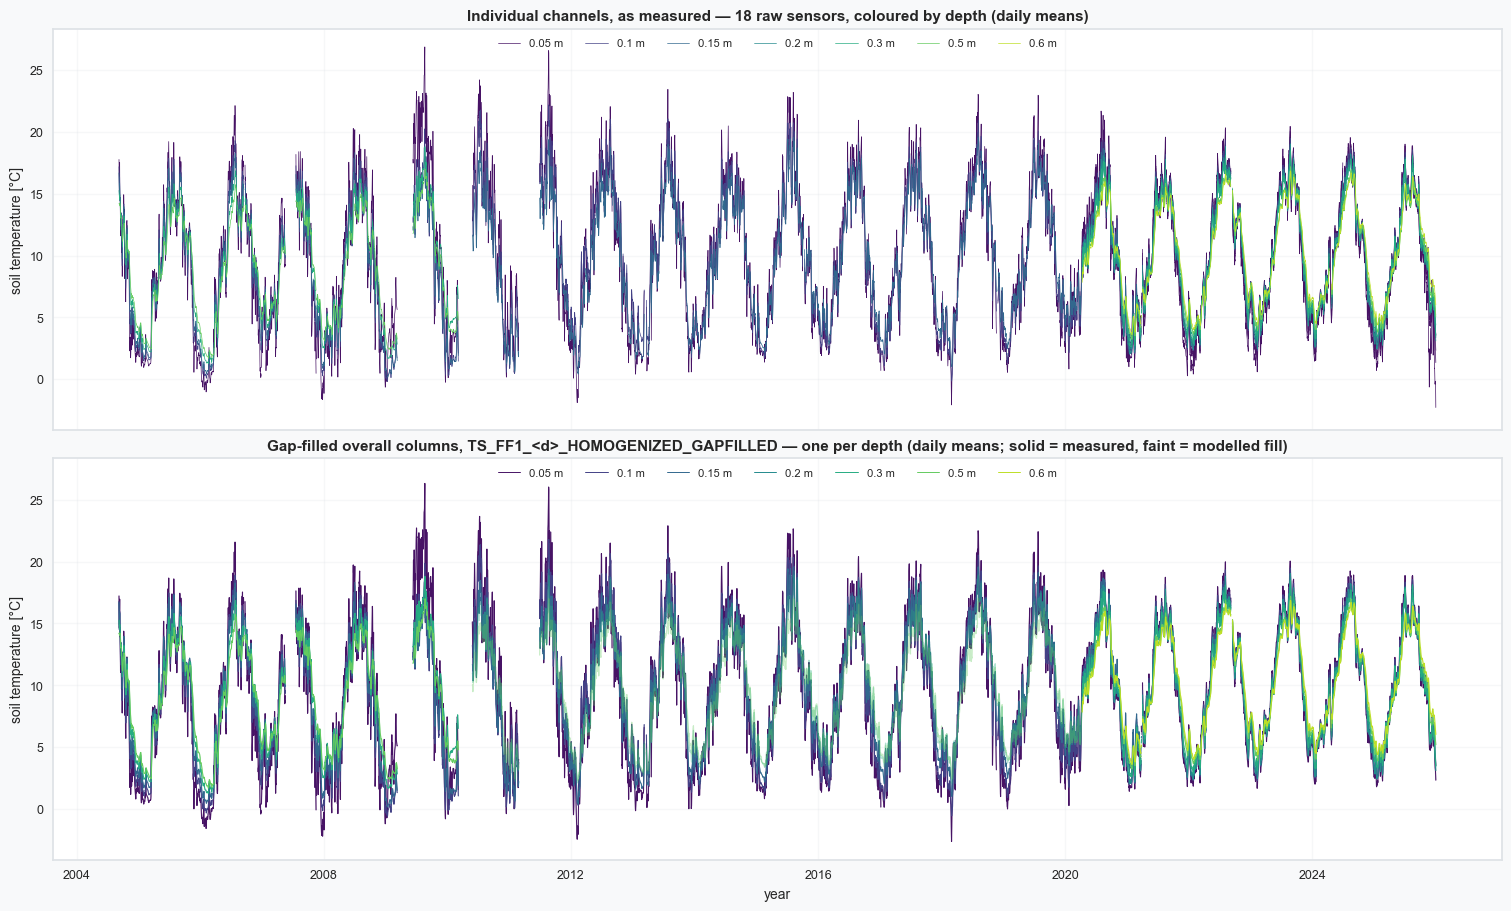

In [49]:
_dcolors = dict(zip(DEPTHS, plt.cm.viridis(np.linspace(0.05, 0.9, len(DEPTHS)))))

fig, axs = plt.subplots(nrows=2, figsize=(15, 9), dpi=100, layout="constrained", sharex=True,
                        sharey=True)

# Top: every individual channel, daily mean, coloured by its depth. One legend entry per depth
# (labelled on the depth's first channel) so the 18 lines stay readable.
_labelled = set()
for _d in DEPTHS:
    for _c in INDIVIDUAL[_d]:
        _daily = _written[_c].resample("1D").mean()
        axs[0].plot(_daily.index, _daily.values, lw=0.5, color=_dcolors[_d],
                    label=f"{_d} m" if _d not in _labelled else None)
        _labelled.add(_d)
axs[0].set_title(f"Individual channels, as measured — {sum(len(v) for v in INDIVIDUAL.values())} "
                 f"raw sensors, coloured by depth (daily means)", fontsize=11)
axs[0].set_ylabel("soil temperature [°C]")
axs[0].legend(fontsize=8, ncol=7, loc="upper center")

# Bottom: the gap-filled overall column of each depth, daily mean. The measured part is drawn
# solid; the modelled fills are overdrawn faintly on top so a reader sees where the continuity
# came from a model rather than a thermometer.
for _d in DEPTHS:
    _meas = _written[homogcol(_d)].where(_written[methodcol(_d)].isin(METHOD_MEASURED))
    _full = _written[homogcol(_d)]
    axs[1].plot(_full.resample("1D").mean().index, _full.resample("1D").mean().values,
                lw=0.9, color=_dcolors[_d], alpha=0.35)
    axs[1].plot(_meas.resample("1D").mean().index, _meas.resample("1D").mean().values,
                lw=0.7, color=_dcolors[_d], label=f"{_d} m")
axs[1].set_title("Gap-filled overall columns, TS_FF1_<d>_HOMOGENIZED_GAPFILLED — one per depth "
                 "(daily means; solid = measured, faint = modelled fill)", fontsize=11)
axs[1].set_ylabel("soil temperature [°C]")
axs[1].set_xlabel("year")
axs[1].legend(fontsize=8, ncol=7, loc="upper center")
plt.show()

### What is in the exported file

The manifest, drawn from the file **as read back from disk** rather than from the frame in memory,
so it describes what a downstream user will actually open.

Read the availability strip with one thing in mind: **"available" means something different for a
value column and for a flag column.** A value is available where it is not `NaN`. A flag is defined
for *every* record of the index — that is the point of a flag — so its bar shows where it carries a
**non-zero** code instead. The strip makes the schema legible at a glance: for each depth, a stack
of individual channels (the raw sensors, gappy) sitting above the one overall column (gap-filled,
near-continuous), and the method flag showing measured-versus-modelled beneath it.

In [50]:
import matplotlib.dates as mdates

KIND_STYLE = {
    "individual": ("#90A4AE", "individual channel, as measured (raw)"),
    "overall": ("#00897B", "overall column, gap-filled"),
    "method flag": ("#FB8C00", "method (bar = a value is present)"),
    "suspect flag": ("#D32F2F", "suspect (bar = flag == 1)"),
}


def column_kind(c: str) -> str:
    if c.endswith("_METHOD"):
        return "method flag"
    if c.endswith("_SUSPECT"):
        return "suspect flag"
    if c.endswith("_HOMOGENIZED_GAPFILLED"):
        return "overall"
    return "individual"


def carries_information(frame: pd.DataFrame, c: str) -> pd.Series:
    """Where a column says something. Not `notna()` for a flag: a flag is defined at every record,
    so notna() would report 100 % for all of them and hide exactly what the reader wants to see."""
    _k = column_kind(c)
    if _k in ("individual", "overall"):
        return frame[c].notna()
    return frame[c] != 0 if _k == "method flag" else frame[c] == 1


def _depth_of_col(c):
    # The depth token, robust to the extra segment in TS_PRF_FF1_<d>_1: the first _<number>_ or
    # _<number>-at-end that matches one of this profile's depths.
    return next(float(d) for d in DEPTHS if re.search(rf"_{re.escape(d)}(?:_|$)", c))


_rows = []
for _c in EXPORT_COLS:
    _k = column_kind(_c)
    _av = carries_information(_written, _c)
    _rows.append({"column": _c, "kind": _k, "depth_m": _depth_of_col(_c),
                  "unit": "degC" if _k in ("individual", "overall") else "code",
                  "n": int(_av.sum()), "coverage_%": round(100 * float(_av.mean()), 1),
                  "first": _av.index[_av][0] if _av.any() else pd.NaT,
                  "last": _av.index[_av][-1] if _av.any() else pd.NaT})
MANIFEST = pd.DataFrame(_rows).set_index("column")
display(MANIFEST)

# The figure doubles as a check: the method flag must carry a value code in exactly the records
# where the overall column has a value.
for _d in DEPTHS:
    assert MANIFEST.loc[methodcol(_d), "n"] == MANIFEST.loc[homogcol(_d), "n"], \
        f"{methodcol(_d)} is non-zero in a different number of records than {homogcol(_d)} has values"
print("Every method-flag row matches its overall column exactly.")

,kind,depth_m,unit,n,coverage_%,first,last
column,,,,,,,
TS_FF1_0.05_2,individual,0.05,degC,98495,26.4,2020-04-10 14:45:00,2025-12-31 23:45:00
TS_FF1_0.05_3,individual,0.05,degC,82652,22.1,2021-03-26 15:15:00,2025-12-31 23:45:00
TS_FF1_0.05_4,individual,0.05,degC,78908,21.1,2021-03-26 15:15:00,2025-12-31 23:45:00
TS_FF1_0.05_1,individual,0.05,degC,98604,26.4,2020-04-10 14:45:00,2025-12-31 23:45:00
TS_PRF_FF1_0.05_1,individual,0.05,degC,269543,72.1,2004-09-07 13:45:00,2021-03-24 09:45:00
TS_FF1_0.05_HOMOGENIZED_GAPFILLED,overall,0.05,degC,352330,94.3,2004-09-07 13:45:00,2025-12-31 23:45:00
FLAG_TS_FF1_0.05_HOMOGENIZED_GAPFILLED_METHOD,method flag,0.05,code,352330,94.3,2004-09-07 13:45:00,2025-12-31 23:45:00
FLAG_TS_FF1_0.05_HOMOGENIZED_GAPFILLED_SUSPECT,suspect flag,0.05,code,20297,5.4,2009-01-26 00:15:00,2011-09-29 23:45:00
TS_FF1_0.1_2,individual,0.10,degC,98544,26.4,2020-04-10 14:45:00,2025-12-31 23:45:00


Every method-flag row matches its overall column exactly.


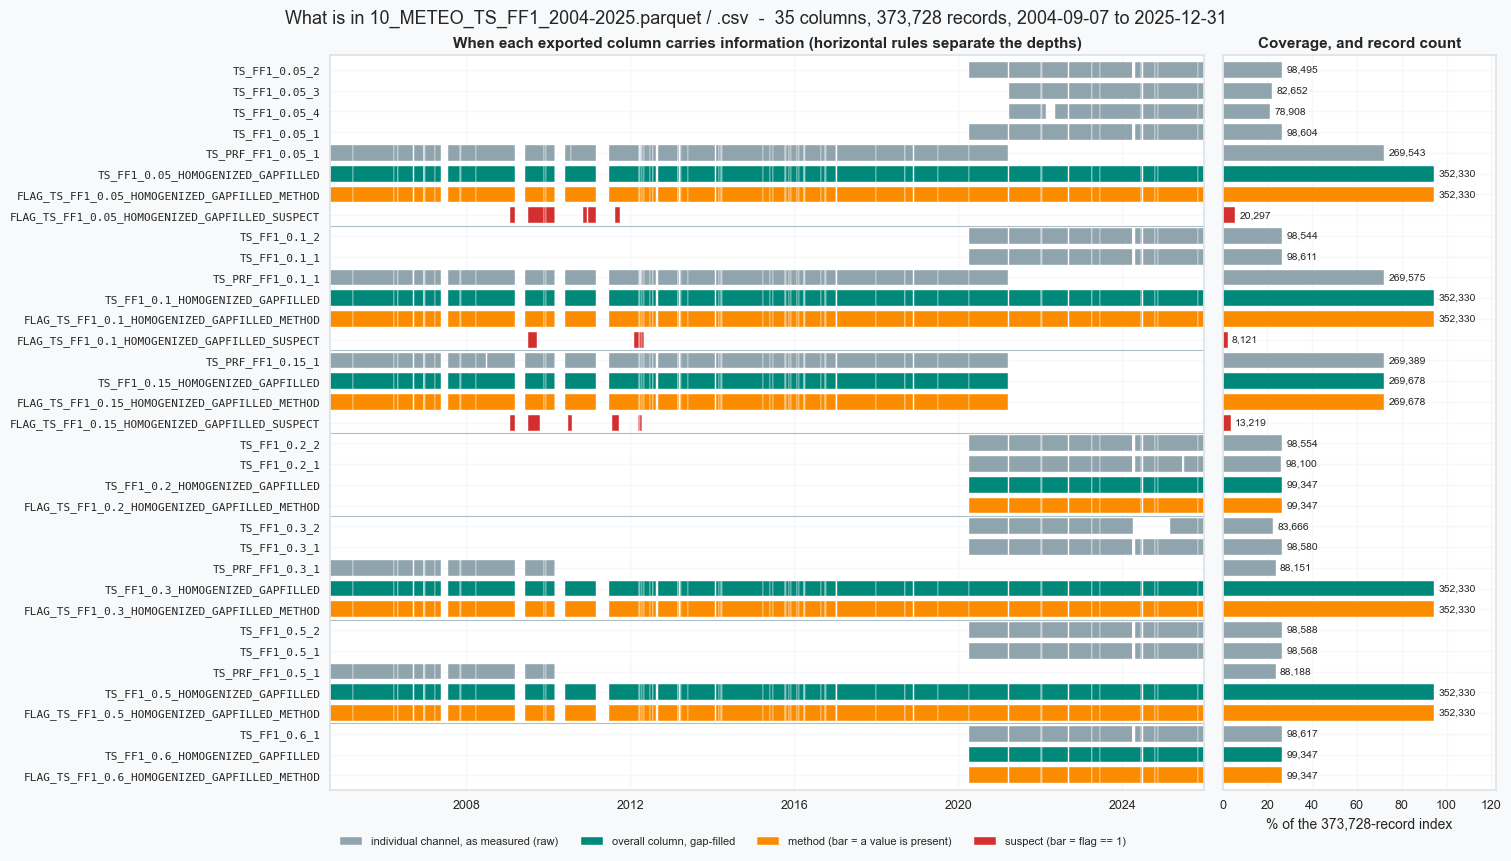

What the strip shows, per depth: the raw individual channels are gappy (each is one sensor,
down when that sensor was down); the overall column below them is filled from the other
depths - most visibly closing the ten-year 0.3/0.5 m hole. Each overall column begins and
ends where that depth's own measurements do - the fill interpolates, it does not extrapolate,
so 0.2/0.6 m stay modern-only and 0.15 m stops in 2021. What remains empty inside a span is
the whole-station outages, aligned across every depth at once.


In [51]:
fig, axs = plt.subplots(ncols=2, figsize=(15, 8.5), dpi=100, layout="constrained",
                        width_ratios=[3.2, 1])
fig.suptitle(f"What is in {OUTNAME}.parquet / .csv  -  "
             f"{len(EXPORT_COLS)} columns, {len(_written):,} records, "
             f"{_written.index[0]:%Y-%m-%d} to {_written.index[-1]:%Y-%m-%d}", fontsize=13)

_seen = set()
for _i, _c in enumerate(EXPORT_COLS):
    _y = len(EXPORT_COLS) - 1 - _i
    _colr, _desc = KIND_STYLE[column_kind(_c)]
    # Contiguous runs rather than one marker per record: 19 columns x 373,728 records is 7 million
    # markers, and the figure would take longer to draw than the notebook takes to run.
    _spans = [(mdates.date2num(_a), max(mdates.date2num(_b) - mdates.date2num(_a), 0.5))
              for _a, _b, _n in missing_blocks(carries_information(_written, _c))]
    axs[0].broken_barh(_spans, (_y - 0.38, 0.76), facecolors=_colr,
                       label=_desc if column_kind(_c) not in _seen else None)
    _seen.add(column_kind(_c))

axs[0].set_yticks(range(len(EXPORT_COLS)))
axs[0].set_yticklabels(EXPORT_COLS[::-1], fontsize=8, family="monospace")
axs[0].xaxis_date()
axs[0].set_xlim(mdates.date2num(_written.index[0]), mdates.date2num(_written.index[-1]))
axs[0].set_ylim(-0.7, len(EXPORT_COLS) - 0.3)
for _d in DEPTHS[:-1]:
    _last = max(_i for _i, _c in enumerate(EXPORT_COLS) if _depth_of_col(_c) == float(_d))
    axs[0].axhline(len(EXPORT_COLS) - 1 - _last - 0.5, color="#B0BEC5", lw=0.8)
axs[0].set_title("When each exported column carries information (horizontal rules separate the "
                 "depths)", fontsize=11)
axs[0].legend(fontsize=8, loc="upper left", bbox_to_anchor=(0, -0.05), ncol=4, frameon=False)

for _i, _c in enumerate(EXPORT_COLS):
    _y = len(EXPORT_COLS) - 1 - _i
    axs[1].barh(_y, MANIFEST.loc[_c, "coverage_%"], color=KIND_STYLE[column_kind(_c)][0], height=0.76)
    axs[1].text(MANIFEST.loc[_c, "coverage_%"] + 2, _y, f"{MANIFEST.loc[_c, 'n']:,}",
                va="center", fontsize=7.5)
axs[1].set_yticks(range(len(EXPORT_COLS)))
axs[1].set_yticklabels([])
axs[1].set_ylim(-0.7, len(EXPORT_COLS) - 0.3)
axs[1].set_xlim(0, 122)
axs[1].set_xlabel(f"% of the {len(_written):,}-record index")
axs[1].set_title("Coverage, and record count", fontsize=11)
plt.show()

print("What the strip shows, per depth: the raw individual channels are gappy (each is one sensor,")
print("down when that sensor was down); the overall column below them is filled from the other")
print("depths - most visibly closing the ten-year 0.3/0.5 m hole. Each overall column begins and")
print("ends where that depth's own measurements do - the fill interpolates, it does not extrapolate,")
print("so 0.2/0.6 m stay modern-only and 0.15 m stops in 2021. What remains empty inside a span is")
print("the whole-station outages, aligned across every depth at once.")

***

## ⚠️ Notes for downstream users

- **The file has two kinds of column per depth. Pick the one that matches your question.**
  The **individual channels** (`TS_FF1_0.05_1`, `_2`, `_3`, `_4`, `TS_PRF_FF1_0.05_1`, …) are the
  raw measurements, each a single sensor, gaps where that sensor was down — use these when you want
  the truth of one instrument. The **overall column** `TS_FF1_<d>_HOMOGENIZED` reconciles all of a
  depth's sensors into one gap-filled series — use it when you want a single number per depth.
- **`FLAG_…_HOMOGENIZED_GAPFILLED_METHOD` tells you how each overall value was made**, and you should
  filter on it: `1` measured (modern), `2` measured (early), `3` modelled from an adjacent depth
  (≤ 0.15 m, good to ~0.2 K), `4` modelled from a more distant depth (weaker, ~0.5-0.7 K), `0` no
  value. To recover the **measured-only** series, keep `METHOD ∈ {1, 2}`. To drop only the weakest
  fills, exclude `METHOD == 4`.
- **The overall columns are gap-filled from the other depths of the same profile**, by a regression
  fitted separately for each sensor generation (so a fill never introduces a sensor step) and
  validated by leave-one-year-out and by predicting the deep depths from the shallow ones alone.
  This is a genuine model estimate — the two-year 0.3/0.5 m and the ten-year 0.3/0.5 m gaps are now
  *filled*, not measured. The individual columns are never filled.
- **Cross-era homogenisation is measured only at 0.05 and 0.1 m** (the 348-day overlap of the two
  generations). At 0.3/0.5/0.15 m the eras do not overlap, so the early era in the overall column
  sits at its **own level** (method `2`) and a trend across April 2020 there still carries the
  sensor change. `09`'s soil moisture had to homogenise on climatology; here it is refused where it
  cannot be measured.
- **Do not compute a diurnal or seasonal amplitude across April 2020.** The early sensors were
  better coupled to the surface than today's at the same nominal depth — at 0.05 m the early daily
  amplitude is ~3.1 K against ~0.9 K modern. Levels are reconciled; amplitudes are not, and no
  offset or fill can make them so.
- **Between January 2009 and May 2012 the early profile does not agree with itself, and those
  records are flagged, not fixed.** `FLAG_…_HOMOGENIZED_GAPFILLED_SUSPECT = 1` marks them at 0.05,
  0.1 and 0.15 m (including any values modelled from the early era in that window). The three
  channels depart from their own seasonal norm by 1.5-3.5 K in mirror-image pairs; across the other
  thirteen years they agree to a few tenths of a kelvin. Which of the three is wrong is not
  determined — no fourth soil sensor, no external reference — so **filter on this flag before using
  the early era quantitatively.** The period brackets the repeated forest-floor logger power
  failures of 2009-2011 and ends near the 2012-04-25 logger program *"with corrected multipliers
  and offset"*.
- **The fill interpolates, it does not extrapolate.** Each overall column is filled only within
  that depth's own measured span, so it begins at the depth's first measurement and ends at its
  last: 0.2 and 0.6 m have no values before 2020, and 0.15 m has none after March 2021. Inside a
  span, the only gaps left are the **whole-station outages** — every depth dead at once, which no
  depth can fill for another (~6 %, the same timestamps in every depth).
- **The 0.3 m record crosses two probes, and the swap is invisible in the values.** The original
  TEROS 12 fell silent on 2024-04-09 and its replacement went in on 2025-03-04, 40 cm down the
  slope. The dead 328 days are covered by the depth's other channel, and the replacement reads the
  same as the original did relative to its neighbour — unlike soil *moisture*, where `09` measures
  a real +3 % VWC step at the same swap. Flag `5` marks it anyway.
- **Values are °C.** The modern record is stored on a `0.1 K` grid, which matters below 0.3 m: the
  median summer daily amplitude at 0.5 m and 0.6 m *is* one grid step. Do not read a diurnal cycle
  out of the deep columns — it is quantisation, not soil.
- **Depths are not replicates.** They share a logger, a power supply and an SDI-12 bus, so they
  fail together; they do not measure the same soil, and their disagreement is information.
- **The early era was screened once, by the MeteoScreeningTool, and never re-screened.** The
  thirteen `20_SCREENING/TS/` notebooks cover the modern channels only. This notebook checks the
  early era for physical consistency (its depths damp and lag correctly, its level matches the
  modern era in the overlap) but cannot re-screen it.
- **Ten early field names were dropped as duplicates and three as mislabelled.**
  `TS_PRF_FF1_*_2/_3` are the modern profile re-screened by the old tool under a shifted replicate
  index; `TS_FF1_0.05_1/_2/_3` in the `mst` era are early hardware sitting at an effective 0.15-
  0.31 m, not at 0.05 m. Both exclusions are re-derived from the data on every run. If you go back
  to the raw database, do not read those names as what they are called.
- **There is no 1.0 m or 1.5 m depth**, although the database has fields for them: the only records
  are a two-year block carrying 1,559 values of exactly `0.00 °C` and excursions to `211 °C`, which
  nothing has screened.
- **The site record for 2006-2011 is real but invisible to a date filter.** It was pasted into GIN
  as a **single row** dated 2011-06-03. Any notebook that filters the fieldbook on its `Date`
  column will conclude those years are undocumented; they are not, and two of this product's four
  long early gaps are named there to the day.
- **2004 and 2005 have no site record of any kind.** Statements about the first two years rest on
  physical evidence alone.

**Still open**

- **What the early profile physically was.** The fieldbook names **three Campbell 107 soil sensors**
  (devices 773/774/775), trashed on 2021-03-25 — the day every early channel stops — and *"replaced
  by new one (109)"*. Three is also the number of `mst`-era `TS_FF1_0.05_*` channels this notebook
  excludes, and they sit at three unrelated effective depths, which is what three separately placed
  sensors look like. It is the best lead in the archive and it is **not** an identification:
  nothing ties a device number to a field name, the other three early channels stop on the same
  day, and three 107s replaced by two 109s does not balance. The make behind seventeen years of
  this product's early era therefore remains unrecorded.
- **Why the early 0.05 m channel is so much livelier than today's.** A shallower installation, a
  thinner litter layer in 2004, or a different pit — the data cannot separate them, and the
  difference is passed through to the user as a flag rather than corrected. The modern profile shows
  the same effect in miniature and there the cause *is* known: the two Campbell 109s went in beside
  the soil heat-flux plates rather than into the profile pit, and `TS_FF1_0.05_4` carries a site
  entry of its own — *"too close to the surface? Very strong daily cycle"* — written independently
  of this analysis.
- **The August 2012 logger clock error.** `01`-`05` shift one block by +15.5 h. That is a *tower
  logger* fault, and `09` established that the forest floor is a separate logger whose 2012
  fieldbook entry describes a different lag. Soil temperature at this site does have a diurnal
  cycle at 0.05 m, so unlike soil moisture the fault would in principle be detectable — but only in
  the early era, where there is no second, independent soil sensor to align against. Nothing is
  applied here.
- **Which early channel is wrong between 2009 and 2012, and why.** The scan can only say the three
  disagree. Three candidate explanations fit the timing and the data cannot separate them: a
  changed multiplier on one channel (the 2012-04-25 entry, which names none), physical disturbance
  of one sensor during the repeated logger repairs of 2009-2011, or a genuinely drifting probe. A
  fourth soil sensor from that era would settle it, and none exists in the archive. Until then the
  suspect flag is the honest answer.
- **The two-year 2017-2018 block.** Excluded as unscreened, but it is the only 0.2 m, 1.0 m and
  1.5 m record the site ever produced. If it were screened it would extend the product downwards;
  that is a `20_SCREENING/` job, not this one's.

***

## End of notebook.

In [52]:
NOTEBOOK_END = datetime.now()
_h, _rem = divmod(int((NOTEBOOK_END - NOTEBOOK_START).total_seconds()), 3600)
_m, _s = divmod(_rem, 60)

print(f"Started:  {NOTEBOOK_START.strftime('%Y-%m-%d %H:%M:%S')}")
print(f"Finished: {NOTEBOOK_END.strftime('%Y-%m-%d %H:%M:%S')}")
print(f"Runtime:  {_h:02d}:{_m:02d}:{_s:02d} (hh:mm:ss)")

Started:  2026-07-23 01:41:56
Finished: 2026-07-23 01:42:44
Runtime:  00:00:48 (hh:mm:ss)
